# Exploratory Data Analysis

This notebook explores the raw OpenStreetMap data for Germany to assess data quality, completeness, tag distributions, geometry characteristics, and the availability of information relevant to building classification.

**Input**
- Raw OpenStreetMap building and land-use data for Germany.

**Output**
- Exploratory statistics and visualizations describing the building dataset.
- Identification of data-quality issues and potentially useful classification features.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns

import os
import sys



ROOT_DIR = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR = os.path.join(ROOT_DIR, 'data')

BUILDING_FILE = os.path.join(DATA_DIR, 'interim', 'germany_buildings.parquet')
LANDUSE_FILE = os.path.join(DATA_DIR, 'interim', 'germany_landuse.parquet')



In [ ]:
print("Loading Germany Data...")

# Load Parquet files
gdf_bldg = gpd.read_parquet(BUILDING_FILE)
gdf_landuse = gpd.read_parquet(LANDUSE_FILE)

print("Data loaded successfully!")

Loading Germany Data...
Data loaded successfully!


In [ ]:
# Replace literal 'nan' strings with actual NaN

print("Cleaning fake nulls...")

fake_nulls = ['nan', 'NaN', 'None', 'none', '', ' ']
replaced_bldg = 0
replaced_lu = 0

# Clean Buildings
for col in gdf_bldg.select_dtypes(include=['object', 'string']).columns:
    if col == 'geometry': 
        continue
    
    mask = gdf_bldg[col].isin(fake_nulls)
    n = mask.sum()
    
    if n > 0:
        gdf_bldg.loc[mask, col] = np.nan
        replaced_bldg += n

# Clean Landuse
for col in gdf_landuse.select_dtypes(include=['object', 'string']).columns:
    if col == 'geometry': 
        continue
    
    mask = gdf_landuse[col].isin(fake_nulls)
    n = mask.sum()
    
    if n > 0:
        gdf_landuse.loc[mask, col] = np.nan
        replaced_lu += n

if (replaced_bldg + replaced_lu) > 0:
    print(f"Fixed {replaced_bldg:,} fake nulls in buildings.")
    print(f"Fixed {replaced_lu:,} fake nulls in landuse.")
    print("Completeness percentages will be accurate.")
else:
    print("No literal strings found. Data clean in this regard.")

Cleaning fake nulls...
Fixed 1,266,285,628 fake nulls in buildings.
Fixed 129,099,657 fake nulls in landuse.
Completeness percentages will be accurate.


In [4]:
#  BASIC SHAPE AND MEMORY

print('BUILDINGS DATASET')
print('-' * 55)
print(f'  Rows (buildings): {len(gdf_bldg):>15,}')
print(f'  Columns         : {len(gdf_bldg.columns):>15}')
print(f'  CRS             : {gdf_bldg.geometry.crs.to_string()}')
print(f'  Geometry types  : {gdf_bldg.geometry.geom_type.unique().tolist()}')
print()
print('LAND USE DATASET')
print('-' * 55)
print(f'  Rows (polygons) : {len(gdf_landuse):>15,}')
print(f'  Columns         : {len(gdf_landuse.columns):>15}')
print(f'  CRS             : {gdf_landuse.geometry.crs.to_string()}')

BUILDINGS DATASET
-------------------------------------------------------
  Rows (buildings):      38,830,003
  Columns         :              43
  CRS             : EPSG:4326
  Geometry types  : ['Polygon', 'MultiLineString', 'MultiPolygon', 'LineString']

LAND USE DATASET
-------------------------------------------------------
  Rows (polygons) :       4,968,125
  Columns         :              36
  CRS             : EPSG:4326


In [5]:

# Check how many non-polygon geometries exist

TOTAL = len(gdf_bldg)
geom_counts = gdf_bldg.geometry.geom_type.value_counts(dropna=False)
print("GEOMETRY TYPE COUNTS:")
for gtype, cnt in geom_counts.items():
    pct  = cnt / TOTAL * 100
    flag = '' if str(gtype) in ['Polygon','MultiPolygon'] else '  <- PROBLEM'
    print(f"  {str(gtype):<22} {cnt:>10,}  ({pct:.3f}%){flag}")

print()
non_poly = gdf_bldg[~gdf_bldg.geometry.geom_type.isin(['Polygon','MultiPolygon'])]
print(f"Total non-polygon geometries: {len(non_poly):,}  ({len(non_poly)/TOTAL*100:.3f}%)")
print()



GEOMETRY TYPE COUNTS:
  Polygon                38,828,150  (99.995%)
  MultiPolygon                1,823  (0.005%)
  MultiLineString                20  (0.000%)  <- PROBLEM
  LineString                     10  (0.000%)  <- PROBLEM

Total non-polygon geometries: 30  (0.000%)



In [6]:
# Look at what building tags these problem geometries have
print("Building tags for non-polygon geometries:")
non_poly['building'].value_counts(dropna=False)

Building tags for non-polygon geometries:


building
yes                                                   12
industrial                                             5
service                                                2
wall                                                   2
garage                                                 1
roof                                                   1
https://www.freizeitregion.de/tour/nordkreis-route     1
office                                                 1
gatehouse                                              1
hut                                                    1
bridge                                                 1
train_station                                          1
historic                                               1
Name: count, dtype: int64

**FINDING: Non-polygon geometries present in raw data**

30 rows contain LineString or MultiLineString geometries.

To be excluded during preprocessing, since they represent a negligible fraction of the dataset

In [ ]:
# Check for non-standard building tag values in the full dataset

all_building_values = gdf_bldg['building'].value_counts(dropna=False)

# Flag values that look suspicious
suspicious = all_building_values[
    all_building_values.index.map(
        lambda x: isinstance(x, str) and (
            x.startswith('http') or      # URLs
            len(x) > 30 or               # unusually long values
            ' ' in str(x)                # contains spaces (not normal)
        )
    )
]

if len(suspicious) > 0:
    print(f"SUSPICIOUS building tag values found: {len(suspicious)}")
    print(suspicious.to_string())
else:
    print("No suspicious building tag values found.")
    print("All values look like valid OSM tags.")

SUSPICIOUS building tag values found: 36
building
semidetatched house                                   9
Blechhalle teilweise offen                            3
unknown (garage?)                                     3
construction trailer                                  2
yes @ summer_season                                   2
bus stop shelter                                      2
holiday home                                          2
Landwirtschaft Neuenhofe                              2
retail; apartments                                    2
garagesAm Eulendyk e.V.                               2
Public buildings                                      2
semidetached_house;house;conservatory                 1
yes, public, clubhouse                                1
Unterer Flurweg                                       1
allotment_housebuilding=allotment_house               1
Freistehendes Mehrfamilienhaus                        1
engine shed                                           

**FINDING: Non-standard building tag values present**

36 unique building tag values identified as inconsistent, including typos, free-text entries, mixed-use labels, and invalid strings.

These will be standardised during preprocessing

In [8]:
# Look at the first few rows of each dataset to get a sense of the columns and data
gdf_bldg.head()

,addr:city,addr:country,addr:full,addr:housenumber,addr:housename,addr:postcode,addr:place,addr:street,email,name,...,source,start_date,wikipedia,id,timestamp,version,tags,osm_type,geometry,changeset
0,Weinheim,DE,NaN,5,NaN,69469,NaN,Babostraße,NaN,Konferenzhaus Unternehmensgruppe Freudenberg,...,NaN,NaN,NaN,3428357,1739194469,14,NaN,way,"POLYGON ((8.67006 49.54737, 8.67004 49.54762, ...",NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Reithalle,...,NaN,NaN,NaN,3453425,1711913366,5,"{""roof:shape"":""gabled"",""sport"":""equestrian""}",way,"POLYGON ((11.90186 48.19362, 11.90156 48.19361...",NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3453428,1231258726,2,"{""created_by"":""JOSM""}",way,"POLYGON ((11.90062 48.19382, 11.90052 48.1938,...",NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3453429,1478163358,3,NaN,way,"POLYGON ((11.90074 48.19364, 11.90044 48.19359...",NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3453554,1232194987,3,"{""created_by"":""JOSM""}",way,"POLYGON ((11.90097 48.19364, 11.90137 48.1937,...",NaN


In [9]:
# Look at a random sample of rows to see more variety in the data
gdf_bldg.sample(10, random_state=42)

,addr:city,addr:country,addr:full,addr:housenumber,addr:housename,addr:postcode,addr:place,addr:street,email,name,...,source,start_date,wikipedia,id,timestamp,version,tags,osm_type,geometry,changeset
2107080,Hanau,DE,NaN,9,NaN,63454,NaN,Meisenweg,NaN,NaN,...,NaN,NaN,NaN,96754998,1749709577,6,"{""addr:suburb"":""Hohe Tanne""}",way,"POLYGON ((8.87514 50.14799, 8.87541 50.14794, ...",NaN
31078295,Wimmelburg,NaN,NaN,36,NaN,06313,NaN,Mitteldorf,NaN,NaN,...,NaN,NaN,NaN,841772428,1728924797,3,NaN,way,"POLYGON ((11.50625 51.52361, 11.50613 51.52361...",NaN
33003373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,975022127,1629473185,1,NaN,way,"POLYGON ((14.28938 52.67476, 14.28955 52.67483...",NaN
14222053,Essen,NaN,NaN,11,NaN,45276,NaN,Krahwinkelstraße,NaN,NaN,...,NaN,NaN,NaN,283864801,1681547293,6,"{""roof:shape"":""flat""}",way,"POLYGON ((7.08062 51.44479, 7.08062 51.44481, ...",NaN
38159466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1429545621,1757784476,1,NaN,way,"POLYGON ((8.91338 50.10492, 8.91337 50.10496, ...",NaN
4451309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,139008484,1548507442,5,NaN,way,"POLYGON ((9.60472 50.51513, 9.6048 50.51517, 9...",NaN
24880682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,488754448,1492894452,1,NaN,way,"POLYGON ((10.36139 48.50576, 10.36128 48.50593...",NaN
14558232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,288196569,1477051173,3,NaN,way,"POLYGON ((7.97262 48.55935, 7.97262 48.55929, ...",NaN
1277603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,80025413,1613714167,8,NaN,way,"POLYGON ((13.28681 52.63021, 13.28688 52.63018...",NaN
16694033,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,313112443,1645280010,2,NaN,way,"POLYGON ((7.23346 51.56841, 7.23346 51.56841, ...",NaN


In [10]:
# Get a concise summary of the DataFrame
gdf_bldg.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 38830003 entries, 0 to 38830002
Data columns (total 43 columns):
 #   Column              Dtype   
---  ------              -----   
 0   addr:city           object  
 1   addr:country        object  
 2   addr:full           object  
 3   addr:housenumber    object  
 4   addr:housename      object  
 5   addr:postcode       object  
 6   addr:place          object  
 7   addr:street         object  
 8   email               object  
 9   name                object  
 10  opening_hours       object  
 11  operator            object  
 12  phone               object  
 13  ref                 object  
 14  url                 object  
 15  visible             object  
 16  website             object  
 17  building            object  
 18  amenity             object  
 19  building:flats      object  
 20  building:levels     object  
 21  building:material   object  
 22  building:max_level  object  
 23  building:min_level  ob

## Column by Column Inspection
Understand what each important column contains and how reliable it is.

#### OSM ID

In [11]:
# Inspect OSM ID column for uniqueness and completeness, as it's critical for database integrity


ID_COL = 'id'
print()
print('OSM ID ANALYSIS:')
print(f'  Total rows        : {TOTAL:,}')
print(f'  Non-null IDs      : {gdf_bldg[ID_COL].notna().sum():,}')
print(f'  Unique IDs        : {gdf_bldg[ID_COL].nunique():,}')
print(f'  Duplicate IDs     : {TOTAL - gdf_bldg[ID_COL].nunique():,}')
print(f'  Sample values     : {gdf_bldg[ID_COL].head(5).tolist()}')

if gdf_bldg[ID_COL].nunique() == TOTAL:
    print()
    print('RESULT: All IDs unique. The database primary key is intact.')
else:
    dupes = TOTAL - gdf_bldg[ID_COL].nunique()
    print(f'\nWARNING: {dupes:,} duplicate IDs found.')
    print('This must be investigated before building the database.')
    print('Show duplicate rows:')
    print(gdf_bldg[gdf_bldg[ID_COL].duplicated(keep=False)][[ID_COL,'building','geometry']].head(10))


OSM ID ANALYSIS:
  Total rows        : 38,830,003
  Non-null IDs      : 38,830,003
  Unique IDs        : 38,829,914
  Duplicate IDs     : 89
  Sample values     : ['3428357', '3453425', '3453428', '3453429', '3453554']

This must be investigated before building the database.
Show duplicate rows:
               id            building  \
285519   37285229              retail   
458318   43483409                 yes   
637654   48954055                 yes   
767187   53129813                 yes   
798944   53781800                 yes   
904030   56469200            detached   
978422   60115123          apartments   
994851   60698437  semidetached_house   
1152997  72584386                 yes   
1284172  80408677                 yes   

                                                  geometry  
285519   POLYGON ((13.39971 52.38648, 13.39971 52.38655...  
458318   POLYGON ((10.91479 52.38543, 10.91479 52.38531...  
637654   POLYGON ((13.29843 52.58596, 13.2983 52.5859, ...  
767187

In [12]:
dupes = gdf_bldg[gdf_bldg[ID_COL].duplicated(keep=False)]
dupes

,addr:city,addr:country,addr:full,addr:housenumber,addr:housename,addr:postcode,addr:place,addr:street,email,name,...,source,start_date,wikipedia,id,timestamp,version,tags,osm_type,geometry,changeset
285519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,37285229,1527485571,8,"{""roof:levels"":""0""}",way,"POLYGON ((13.39971 52.38648, 13.39971 52.38655...",NaN
458318,Groß Twülpstedt,DE,NaN,7a,NaN,38464,NaN,Auefeld,NaN,NaN,...,NaN,NaN,NaN,43483409,1487509408,5,"{""addr:suburb"":""Klein Tw\u00FClpstedt""}",way,"POLYGON ((10.91479 52.38543, 10.91479 52.38531...",NaN
637654,Berlin,DE,NaN,4,NaN,13509,NaN,Letschiner Weg,NaN,NaN,...,NaN,NaN,NaN,48954055,1450075683,4,"{""addr:suburb"":""Borsigwalde""}",way,"POLYGON ((13.29843 52.58596, 13.2983 52.5859, ...",NaN
767187,Neckarsulm,DE,NaN,1,NaN,74172,NaN,Karlsruher Weg,NaN,NaN,...,NaN,NaN,NaN,53129813,1269373789,2,NaN,way,"POLYGON ((9.24213 49.20274, 9.24222 49.20275, ...",NaN
798944,Dortmund,DE,NaN,5,NaN,44379,NaN,Kirchlinder Straße,NaN,NaN,...,NaN,NaN,NaN,53781800,1420230125,5,NaN,way,"POLYGON ((7.37104 51.52199, 7.37104 51.52199, ...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38821696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1080799488,1607794807,1,"{""type"":""multipolygon""}",relation,"POLYGON ((9.39488 48.87349, 9.39488 48.87334, ...",0.0
38822419,Kelkheim (Taunus),NaN,NaN,3,NaN,65779,NaN,Rettershof,NaN,Hofgut Rettershof,...,NaN,NaN,NaN,193356556,1756640446,2,"{""historic"":""heritage_building"",""tourism"":""att...",relation,"POLYGON ((8.43036 50.16945, 8.43043 50.16945, ...",0.0
38824331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,266152965,1649195786,1,"{""type"":""multipolygon""}",relation,"POLYGON ((6.97554 51.96083, 6.97536 51.96102, ...",0.0
38826584,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,233279962,1699358189,1,"{""description"":""F\u00FChranlage"",""type"":""multi...",relation,"POLYGON ((8.43331 51.92628, 8.43339 51.92629, ...",0.0


##### Investigate duplicated rows

In [13]:
dupes_sorted = dupes.sort_values(by=ID_COL)

dupes_sorted[[ID_COL, 'osm_type', "geometry"]].head(20)

,id,osm_type,geometry
12288008,1,way,"POLYGON ((8.72747 51.682, 8.72754 51.68181, 8...."
6156631,1,way,"POLYGON ((13.80433 52.82796, 13.80436 52.8279,..."
38802886,103302393,relation,"POLYGON ((11.22123 48.16474, 11.22193 48.16468..."
2462768,103302393,way,"POLYGON ((10.12217 54.32492, 10.12194 54.32497..."
34674511,1059068844,way,"POLYGON ((8.69096 50.30608, 8.69103 50.30607, ..."
38803605,1059068844,relation,"POLYGON ((9.80593 52.38435, 9.80573 52.38463, ..."
34801013,1067402755,way,"POLYGON ((11.95587 51.23834, 11.95613 51.23835..."
38803612,1067402755,relation,"POLYGON ((9.80704 52.38513, 9.80744 52.38457, ..."
38802891,106899328,relation,"POLYGON ((11.46407 48.14535, 11.46407 48.14544..."
2637935,106899328,way,"POLYGON ((10.00067 53.75859, 10.00058 53.75861..."


In [14]:
print("Duplicate count:", gdf_bldg[ID_COL].duplicated().sum())

dupes = gdf_bldg[gdf_bldg[ID_COL].duplicated(keep=False)]

print("Unique duplicate IDs:", dupes[ID_COL].nunique())
print("Rows involved:", len(dupes))

print("\nOSM types:")
print(dupes["osm_type"].value_counts())

print("\nGeometry equality check:")
print((dupes.groupby(ID_COL)["geometry"]
       .nunique()
       .value_counts()))

Duplicate count: 89
Unique duplicate IDs: 89
Rows involved: 178

OSM types:
osm_type
way         101
relation     77
Name: count, dtype: int64

Geometry equality check:
geometry
2    89
Name: count, dtype: int64


In [15]:
dupes_sorted[['id','addr:city', 'name', 
      'building', 'amenity', 'building:flats', 'building:levels',
        'building:max_level', 'building:min_level',
        'building:use', 'craft', 'height', 'landuse', 'levels', 'office', 'shop', 
        'tags',
       'osm_type', 'geometry',]].head(20)

,id,addr:city,name,building,amenity,building:flats,building:levels,building:max_level,building:min_level,building:use,craft,height,landuse,levels,office,shop,tags,osm_type,geometry
12288008,1,NaN,NaN,stable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""roof:shape"":""gabled""}",way,"POLYGON ((8.72747 51.682, 8.72754 51.68181, 8...."
6156631,1,NaN,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,way,"POLYGON ((13.80433 52.82796, 13.80436 52.8279,..."
38802886,103302393,NaN,NaN,office,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""roof:shape"":""flat"",""type"":""multipolygon""}",relation,"POLYGON ((11.22123 48.16474, 11.22193 48.16468..."
2462768,103302393,Kiel,NaN,residential,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""roof:levels"":""2""}",way,"POLYGON ((10.12217 54.32492, 10.12194 54.32497..."
34674511,1059068844,NaN,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""fixme"":""building-type and/or shape from user...",way,"POLYGON ((8.69096 50.30608, 8.69103 50.30607, ..."
38803605,1059068844,NaN,K1,hospital,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""description"":""Unfallchirurgie, Gef\u00E4\u00...",relation,"POLYGON ((9.80593 52.38435, 9.80573 52.38463, ..."
34801013,1067402755,NaN,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,way,"POLYGON ((11.95587 51.23834, 11.95613 51.23835..."
38803612,1067402755,NaN,Patienten/Besucher,parking,parking,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""access"":""customers"",""fee"":""yes"",""layer"":""-2""...",relation,"POLYGON ((9.80704 52.38513, 9.80744 52.38457, ..."
38802891,106899328,NaN,NaN,school,NaN,NaN,4,NaN,NaN,NaN,NaN,14,NaN,NaN,NaN,NaN,"{""type"":""multipolygon""}",relation,"POLYGON ((11.46407 48.14535, 11.46407 48.14544..."
2637935,106899328,Henstedt-Ulzburg,NaN,house,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,way,"POLYGON ((10.00067 53.75859, 10.00058 53.75861..."


**FINDING: 89 Duplicate IDs identified** 

some due to overlapping ID ranges between OSM element types (way and relation). Inspection confirms these represent distinct buildings rather than duplicate geometries

Possible fix: make unique ids

In [ ]:
# INVESTIGATE DUPLICATE IDs
#
# FINDING: duplicate id values exist because OSM uses separate
# ID pools for 'way' and 'relation' objects. The same number
# can appear in both pools — they are different objects.

print("DUPLICATE ID INVESTIGATION")
print("=" * 58)

print(f"Total rows with duplicate id values: {len(dupes):,}")
print(f"Unique id values that are duplicated: {dupes['id'].nunique():,}")
print()

# Check if osm_type explains the duplicates
print("osm_type breakdown within duplicate rows:")
print(dupes['osm_type'].value_counts())
print()

# Check: are any duplicates BOTH the same osm_type?
true_dupes = dupes.groupby(['id','osm_type']).size()
true_dupes = true_dupes[true_dupes > 1]
print(f"TRUE duplicates (same id AND same osm_type): {len(true_dupes)}")

if len(true_dupes) == 0:
    print()
    print("RESULT: All duplicates are way/relation pairs.")
    print("These are different OSM objects that share a number")
    print("across separate ID pools. Not true duplicates.")
    print()
    print("id alone is NOT a unique key.")
    print("id + osm_type together IS a unique key.")
else:
    print()
    print("WARNING: Some true duplicates found (same id AND osm_type).")
    print("These need investigation:")
    print(true_dupes)

DUPLICATE ID INVESTIGATION
Total rows with duplicate id values: 178
Unique id values that are duplicated: 89

osm_type breakdown within duplicate rows:
osm_type
way         101
relation     77
Name: count, dtype: int64

TRUE duplicates (same id AND same osm_type): 12

These need investigation:
id  osm_type
1   way         2
15  way         2
17  way         2
2   way         2
5   way         2
50  way         2
55  way         2
56  way         2
61  way         2
70  way         2
86  way         2
9   way         2
dtype: int64


In [ ]:
# SHOW ALL TRUE DUPLICATE ROWS
# True duplicate = same id AND same osm_type

# Find the id+osm_type combinations that appear more than once
dup_groups = (dupes.groupby(['id','osm_type'])
              .size()
              .reset_index(name='count'))
true_dup_keys = dup_groups[dup_groups['count'] > 1]

print(f"True duplicate id+osm_type combinations: {len(true_dup_keys)}")
print()
print("The duplicate keys:")
print(true_dup_keys.to_string())
print()

# Get all rows that are part of a true duplicate
true_dup_rows = dupes.merge(
    true_dup_keys[['id','osm_type']],
    on=['id','osm_type'],
    how='inner'
).sort_values(['id','osm_type'])

print(f"Total rows involved: {len(true_dup_rows)}")
print()
print("ALL DUPLICATE ROW PAIRS — full detail:")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)


True duplicate id+osm_type combinations: 12

The duplicate keys:
     id osm_type  count
0     1      way      2
35   15      way      2
44   17      way      2
57    2      way      2
112   5      way      2
113  50      way      2
122  55      way      2
127  56      way      2
138  61      way      2
143  70      way      2
150  86      way      2
151   9      way      2

Total rows involved: 24

ALL DUPLICATE ROW PAIRS — full detail:


In [18]:
true_dup_rows[['id', 'osm_type', 'geometry',]]

,id,osm_type,geometry
5,1,way,"POLYGON ((13.80433 52.82796, 13.80436 52.8279,..."
10,1,way,"POLYGON ((8.72747 51.682, 8.72754 51.68181, 8...."
2,15,way,"POLYGON ((13.80527 52.8277, 13.80534 52.82773,..."
3,15,way,"POLYGON ((13.80546 52.82753, 13.80551 52.82755..."
7,17,way,"POLYGON ((13.80568 52.82806, 13.80572 52.82809..."
9,17,way,"POLYGON ((13.8054 52.82759, 13.80537 52.82758,..."
8,2,way,"POLYGON ((13.80454 52.82798, 13.80461 52.82799..."
11,2,way,"POLYGON ((8.72776 51.68203, 8.72783 51.68185, ..."
0,5,way,"POLYGON ((13.80014 52.82743, 13.80023 52.82744..."
6,5,way,"POLYGON ((13.80424 52.8278, 13.80433 52.82782,..."


they all have an unusually small id different from normal osm id

In [ ]:
# INVESTIGATE TRUE DUPLICATES IN DETAIL


true_dup_ids = ['1', '2', '5', '9', '15', '17', '50', '55', '56', '61', '70', '86']

for dup_id in true_dup_ids:
    rows = gdf_bldg[gdf_bldg['id'] == dup_id][
        ['id','osm_type','building','name','tags','geometry']
    ]
    print(f"\nID: {dup_id}  ({len(rows)} rows)")
    print("-" * 60)
    for idx, row in rows.iterrows():
        cx = row['geometry'].centroid.x
        cy = row['geometry'].centroid.y
        area = row['geometry'].area  # raw degrees — just for comparison
        print(f"  Row index : {idx}")
        print(f"  building  : {row['building']}")
        print(f"  name      : {row['name']}")
        print(f"  centroid  : ({cx:.5f}, {cy:.5f})")
        print(f"  tags      : {row['tags']}")
        print()


ID: 1  (2 rows)
------------------------------------------------------------
  Row index : 6156631
  building  : yes
  name      : nan
  centroid  : (13.80428, 52.82792)
  tags      : nan

  Row index : 12288008
  building  : stable
  name      : nan
  centroid  : (8.72758, 51.68191)
  tags      : {"roof:shape":"gabled"}


ID: 2  (2 rows)
------------------------------------------------------------
  Row index : 6156636
  building  : yes
  name      : nan
  centroid  : (13.80460, 52.82795)
  tags      : nan

  Row index : 12288009
  building  : stable
  name      : nan
  centroid  : (8.72787, 51.68195)
  tags      : {"roof:shape":"gabled"}


ID: 5  (2 rows)
------------------------------------------------------------
  Row index : 6153143
  building  : yes
  name      : nan
  centroid  : (13.80019, 52.82742)
  tags      : {"note":"stone hut"}

  Row index : 6156632
  building  : yes
  name      : nan
  centroid  : (13.80429, 52.82780)
  tags      : nan


ID: 9  (2 rows)
--------------

In [ ]:
# CHECK IF ANY DUPLICATE PAIRS HAVE IDENTICAL GEOMETRIES
# Identical geometry = exact same polygon = true duplicate row
# Different geometry = different building = ID collision


print("CHECKING GEOMETRY SIMILARITY FOR EACH DUPLICATE PAIR:")
print("-" * 60)

for dup_id in true_dup_ids:
    rows = gdf_bldg[gdf_bldg['id'] == dup_id]
    geoms = rows.geometry.tolist()

    if len(geoms) == 2:
        # Check if geometries are identical
        identical = geoms[0].equals(geoms[1])
        # Check distance between centroids (in degrees, rough check)
        cx1, cy1 = geoms[0].centroid.x, geoms[0].centroid.y
        cx2, cy2 = geoms[1].centroid.x, geoms[1].centroid.y
        dist_deg  = ((cx1-cx2)**2 + (cy1-cy2)**2)**0.5
        dist_km   = dist_deg * 111  # rough conversion degrees to km

        print(f"  ID {dup_id}:")
        print(f"    Identical geometry : {identical}")
        print(f"    Distance between   : {dist_km:.2f} km apart")
        if dist_km > 10:
            print(f"    -> DIFFERENT BUILDINGS (ID recycling)")
        elif identical:
            print(f"    -> EXACT DUPLICATE ROW (remove one)")
        else:
            print(f"    -> SAME AREA, DIFFERENT SHAPE (ID collision in dataset)")
        print()

CHECKING GEOMETRY SIMILARITY FOR EACH DUPLICATE PAIR:
------------------------------------------------------------


  ID 1:
    Identical geometry : False
    Distance between   : 577.69 km apart
    -> DIFFERENT BUILDINGS (ID recycling)

  ID 2:
    Identical geometry : False
    Distance between   : 577.70 km apart
    -> DIFFERENT BUILDINGS (ID recycling)

  ID 5:
    Identical geometry : False
    Distance between   : 0.46 km apart
    -> SAME AREA, DIFFERENT SHAPE (ID collision in dataset)

  ID 9:
    Identical geometry : False
    Distance between   : 0.05 km apart
    -> SAME AREA, DIFFERENT SHAPE (ID collision in dataset)

  ID 15:
    Identical geometry : False
    Distance between   : 0.03 km apart
    -> SAME AREA, DIFFERENT SHAPE (ID collision in dataset)

  ID 17:
    Identical geometry : False
    Distance between   : 0.07 km apart
    -> SAME AREA, DIFFERENT SHAPE (ID collision in dataset)

  ID 50:
    Identical geometry : False
    Distance between   : 0.14 km apart
    -> SAME AREA, DIFFERENT SHAPE (ID collision in dataset)

  ID 55:
    Identical geometry : False
    Distance bet

In [21]:
# True duplicate distance analysis (<0.5km vs >0.5km)
if 'true_dup_rows' in globals() and len(true_dup_rows) > 0:
    dupes = true_dup_rows.copy()
    if dupes.crs is None:
        dupes.set_crs(gdf_bldg.crs, inplace=True)
    dupes_m = dupes.to_crs(epsg=3857)

    records = []
    for (oid, osm_type), grp in dupes_m.groupby(['id','osm_type']):
        if len(grp) < 2:
            continue
        cents = grp.geometry.centroid.reset_index(drop=True)
        if len(cents) == 2:
            d_m = cents[0].distance(cents[1])
            identical_geom = grp.geometry.iloc[0].equals(grp.geometry.iloc[1])
        else:
            d_m = max(
                cents[i].distance(cents[j])
                for i in range(len(cents))
                for j in range(i + 1, len(cents))
            )
            identical_geom = False
        records.append({
            'id': oid,
            'osm_type': osm_type,
            'n_rows': len(grp),
            'distance_m': d_m,
            'distance_km': d_m / 1000,
            'identical_geometry': identical_geom
        })

    true_dupe_dist = pd.DataFrame(records)
    true_dupe_dist['group'] = np.where(true_dupe_dist['distance_km'] <= 0.5, '<=0.5km', '>0.5km')

    print("True duplicates distance by id:")
    print(true_dupe_dist[['id','osm_type','n_rows','distance_m','distance_km','group','identical_geometry']])
    print()

    print("Summary counts:")
    print(true_dupe_dist['group'].value_counts().to_string())
    print(f"Mean distance (km): {true_dupe_dist['distance_km'].mean():.4f}")
    print(f"Median distance (km): {true_dupe_dist['distance_km'].median():.4f}")
    print()

    for label, subset in true_dupe_dist.groupby('group'):
        print(f"--- {label} ({len(subset)} rows) ---")
        print(subset.sort_values('distance_km')[['id','osm_type','distance_km','identical_geometry']].to_string(index=False))
        print()
else:
    print("true_dup_rows not available or empty")

True duplicates distance by id:
    id osm_type  n_rows     distance_m  distance_km    group  \
0    1      way       2  602342.567114   602.342567   >0.5km   
1   15      way       2      39.149630     0.039150  <=0.5km   
2   17      way       2      96.196325     0.096196  <=0.5km   
3    2      way       2  602344.571543   602.344572   >0.5km   
4    5      way       2     461.671763     0.461672  <=0.5km   
5   50      way       2     139.122501     0.139123  <=0.5km   
6   55      way       2     213.535027     0.213535  <=0.5km   
7   56      way       2     238.456758     0.238457  <=0.5km   
8   61      way       2      70.795577     0.070796  <=0.5km   
9   70      way       2      31.411527     0.031412  <=0.5km   
10  86      way       2      29.913461     0.029913  <=0.5km   
11   9      way       2      56.767564     0.056768  <=0.5km   

    identical_geometry  
0                False  
1                False  
2                False  
3                False  
4         

##### Investigating relations

In [22]:
print(f"Number of relations: {len(gdf_bldg[gdf_bldg['osm_type'] == 'relation'])}")

Number of relations: 27529


In [23]:
gdf_bldg[gdf_bldg['osm_type'] == 'relation'][['id', 'osm_type', 'building', 'geometry']].sample(100)

,id,osm_type,building,geometry
38807840,13420955614,relation,school,"POLYGON ((8.44485 49.98402, 8.44497 49.98403, ..."
38825599,41667448690,relation,yes,"POLYGON ((8.41899 49.97818, 8.41937 49.97818, ..."
38823662,30294231855,relation,office,"POLYGON ((12.92424 50.83348, 12.92464 50.83325..."
38811570,13145994411,relation,industrial,"POLYGON ((8.5345 52.13911, 8.53459 52.13911, 8..."
38803980,73195455,relation,hospital,"POLYGON ((11.28039 49.52076, 11.28055 49.52066..."
...,...,...,...,...
38826574,126267191877,relation,fire_station,"POLYGON ((8.84149 50.07128, 8.84148 50.07132, ..."
38822130,4937930152,relation,yes,"POLYGON ((7.19829 51.40401, 7.19821 51.40397, ..."
38816336,49100595184,relation,office,"POLYGON ((6.86609 51.29306, 6.86715 51.29282, ..."
38805291,8652124981,relation,yes,"POLYGON ((12.80764 51.13151, 12.80728 51.13158..."



Out of 27,470 buildings with osm_type = relation, a random sample of 100 relation IDs was manually inspected against the live OpenStreetMap database.

**Findings:**
100% of the sampled `relation` entities were invalid building footprints. 98% were not found in the database, 1% were deprecated or deleted IDs no longer present in OSM, and 1% were footprints enterily different from what is in the tag.

- To protect the integrity of the database, all rows with `osm_type = 'relation'` should be dropped.


#### BUILDING TAG COLUMN 

The classification of buildings should at minimum match the existing categories in this column (rare values can fall into 'other' category.)

In [24]:
# Inspect building tag distribution to understand how many unique categories exist and how many buildings fall into each category
print("'building' COLUMN")
print('-' * 58)
print(f'  Non-null      : {gdf_bldg["building"].notna().sum():,}  ({gdf_bldg["building"].notna().sum()/TOTAL*100:.1f}%)')
print(f'  Null          : {gdf_bldg["building"].isna().sum():,}  ({gdf_bldg["building"].isna().sum()/TOTAL*100:.1f}%)')
print(f'  Unique values : {gdf_bldg["building"].nunique():,}')
print()
print('ALL VALUES sorted by frequency:')
print('  (bar length proportional to % of total buildings)')
print('-' * 58)
for val, cnt in gdf_bldg['building'].value_counts(dropna=False).items():
    pct = cnt / TOTAL * 100
    bar = '#' * max(1, int(pct))
    label = '  <- NEEDS CLASSIFICATION' if str(val) == 'yes' else ''
    print(f'  {str(val):<28} {cnt:>10,}  ({pct:5.1f}%)  {bar}{label}')

'building' COLUMN
----------------------------------------------------------
  Non-null      : 38,830,003  (100.0%)
  Null          : 0  (0.0%)
  Unique values : 1,172

ALL VALUES sorted by frequency:
  (bar length proportional to % of total buildings)
----------------------------------------------------------
  yes                          25,845,306  ( 66.6%)  ##################################################################  <- NEEDS CLASSIFICATION
  house                         3,235,291  (  8.3%)  ########
  garage                        2,525,558  (  6.5%)  ######
  apartments                    1,468,741  (  3.8%)  ###
  residential                   1,163,622  (  3.0%)  ##
  detached                      1,087,977  (  2.8%)  ##
  shed                            455,648  (  1.2%)  #
  semidetached_house              418,656  (  1.1%)  #
  garages                         391,097  (  1.0%)  #
  roof                            298,339  (  0.8%)  #
  terrace                       

**FINDINGS**

1. Two thirds (66.6%) of all buildings in Germany have no type. classification pipeline must assign a type to 25.8 million buildings.

2. Some tags might need preprocessing due to typos (semidetatched house), concatenation errors (yes~outletstores_direct~, ~building=~fire_station), errors (single characters and numbers e.g. x, q, 1, 8), German text (Wohnhaus) or semicolon combined tags (residential;garage)

3. Garages and sheds can be dropped as we may not need to assign an energy demand to them. **check their distribution to classify other untagged garages throuh rule based method**

4. Non-residential buildins are severely undertagged (commercial: 0.4%, industrial: 0.4%) 

5. Many tagged are not exactly buildings (hangars, toilets, parking, collapsed, wayside_shrine, wall) **should they be dropped?**

6. Semi-commercial buildings exist in data (residential;commercial, commercial;residential, retail;residential)  **check properties to see if patterns exist**

7. There are rare but valid OSM tags likely from rural areas (digester, slurry_tank, cowshed, sty, riding_hall, boathouse, transformer_tower) **can be mapped to broader category e.g., farm, industrial**

8. Too many unique values (1,172) **should be mapped to main categories or treated as yes**

In [25]:
# Quick count to prove point 8
value_counts = gdf_bldg['building'].value_counts()

tier1 = value_counts[value_counts >= 1000]       # dominant values
tier2 = value_counts[(value_counts >= 10) & 
                     (value_counts < 1000)]        # medium values
tier3 = value_counts[value_counts < 10]           # rare values

print(f"Values with >= 1000 buildings  : {len(tier1):>6}  unique tags covering {tier1.sum():>12,} buildings ({tier1.sum()/TOTAL*100:.1f}%)")
print(f"Values with 10-999 buildings   : {len(tier2):>6}  unique tags covering {tier2.sum():>12,} buildings ({tier2.sum()/TOTAL*100:.1f}%)")
print(f"Values with < 10 buildings     : {len(tier3):>6}  unique tags covering {tier3.sum():>12,} buildings ({tier3.sum()/TOTAL*100:.1f}%)")

Values with >= 1000 buildings  :     75  unique tags covering   38,799,956 buildings (99.9%)
Values with 10-999 buildings   :    245  unique tags covering       28,230 buildings (0.1%)
Values with < 10 buildings     :    852  unique tags covering        1,817 buildings (0.0%)


#### HEIGHT 
Height can be used to estimate floors and dwellings

In [ ]:
# Height

# CLEANING STEPS IN ORDER:
# 1. Strip whitespace
# 2. Replace German decimal comma (3,5 -> 3.5)
# 3. Extract numeric part from strings like '12m', '5 meters'
# 4. Convert feet to metres where 'ft' or "'" is present
# 5. Remove clearly impossible values (< 0 or > 500m)
# 6. Only then fall back to NaN for remaining non-numeric

import re

GERMANY_MAX_HEIGHT = 260  # meters — tallest building in Germany is 259m, so anything above 300m is likely an error
GERMANY_MIN_HEIGHT = 0   # meters — minimum possible height


def clean_height(val):
    """
    Attempt to extract a valid height in metres from a raw OSM string.
    Returns float in metres, or NaN if not recoverable.
    """
    if pd.isna(val):
        return np.nan

    s = str(val).strip().lower()

    # Remove common suffixes and noise characters
    # Replace German decimal comma first
    s = s.replace(',', '.')

    # Handle feet — convert to metres
    # Patterns: '12ft', '12 ft', "12'", "12'6"", "5'10\""
    ft_match = re.match(r'^(\d+\.?\d*)\s*(?:ft|\'|feet)', s)
    if ft_match:
        return round(float(ft_match.group(1)) * 0.3048, 2)

    # Handle feet and inches: 5'10" or 5 ft 10 in
    ft_in_match = re.match(r"^(\d+)'(\d+)\"?", s)
    if ft_in_match:
        feet   = float(ft_in_match.group(1))
        inches = float(ft_in_match.group(2))
        return round((feet * 12 + inches) * 0.0254, 2)

    # Strip units and extract number
    # Handles: '12m', '12 m', '12.5m', '12 meters', 'ca. 12', '~12', 'approx 12'
    s_clean = re.sub(r'[a-zA-Z\s~≈≤≥<>ca\.\(\)]', '', s)
    s_clean = s_clean.strip()

    # Handle ranges like '6-8' or '6–8' — take the midpoint
    range_match = re.match(r'^(\d+\.?\d*)[–\-](\d+\.?\d*)$', s_clean)
    if range_match:
        lo = float(range_match.group(1))
        hi = float(range_match.group(2))
        return round((lo + hi) / 2, 2)

    # Try direct numeric conversion
    try:
        return round(float(s_clean), 2)
    except (ValueError, TypeError):
        return np.nan



if 'height' in gdf_bldg.columns:

    raw_filled   = gdf_bldg['height'].notna().sum()
    print('HEIGHT COLUMN CLEANING ANALYSIS')
    print('-' * 55)
    print(f'  Raw non-null values  : {raw_filled:,}  ({raw_filled/TOTAL*100:.2f}%)')
    print(f'  Raw null values      : {gdf_bldg["height"].isna().sum():,}')
    print()

    # Show raw sample before cleaning
    print('  RAW SAMPLE (first 30 non-null values):')
    raw_sample = gdf_bldg['height'].dropna().head(30).tolist()
    for i in range(0, len(raw_sample), 5):
        print(f'    {raw_sample[i:i+5]}')
    print()

    # count what it misses
    h_simple = pd.to_numeric(gdf_bldg['height'], errors='coerce')
    simple_clean = h_simple.notna().sum()
    simple_lost  = raw_filled - simple_clean
    print(f'    Recovered as numeric : {simple_clean:,}  ({simple_clean/raw_filled*100:.1f}% of non-null)')
    print(f'    Lost to NaN          : {simple_lost:,}  ({simple_lost/raw_filled*100:.1f}% of non-null)')
    print()

    # apply the smart cleaning function
    h_smart = gdf_bldg['height'].apply(clean_height)
    smart_clean = h_smart.notna().sum()
    smart_lost  = raw_filled - smart_clean
    extra_recovered = smart_clean - simple_clean
    print(f'  Recover numeric values lost to NaN:')
    print(f'    Total recovered as numeric : {smart_clean:,}  ({smart_clean/raw_filled*100:.1f}% of non-null)')
    print(f'    Final lost to NaN          : {smart_lost:,}  ({smart_lost/raw_filled*100:.1f}% of non-null)')
    print(f'    Extra recovered      : {extra_recovered:,}  (values saved from NaN)')
    print()

    # check remaining unrecoverable values?
    still_nan_mask = h_smart.isna() & gdf_bldg['height'].notna()
    unrecoverable  = gdf_bldg.loc[still_nan_mask, 'height']
    print(f'  UNRECOVERABLE VALUES ({len(unrecoverable):,} total):')
    print(f'  (These become NaN — genuinely unparseable)')
    print(unrecoverable.value_counts().head(20).to_string())
    print()

    # validate the cleaned values
    h_valid = h_smart[(h_smart > GERMANY_MIN_HEIGHT) & (h_smart < GERMANY_MAX_HEIGHT)]
    h_error_low  = (h_smart <= GERMANY_MIN_HEIGHT).sum()
    h_error_high = (h_smart >= GERMANY_MAX_HEIGHT).sum()

    print(f'  CLEANED VALUE VALIDATION:')
    print(f'    Valid ({GERMANY_MIN_HEIGHT} < height < {GERMANY_MAX_HEIGHT}m) : {len(h_valid):,}')
    print(f'    Impossible (<= {GERMANY_MIN_HEIGHT}m)        : {h_error_low:,}   <- set to NaN in pre-processing')
    print(f'    Suspicious (>= {GERMANY_MAX_HEIGHT}m)       : {h_error_high:,} <- set to NaN in pre-processing') 
    print()

    # Statistics on clean valid values
    print(f'  STATISTICS (metres, valid range only):')
    print(h_valid.describe().round(2).to_string())
    print()

    # interpretation
    mean_h  = h_valid.mean()
    median_h = h_valid.median()
    print(f'  INTERPRETATION:')
    print(f'    Mean height   : {mean_h:.1f}m  = roughly {mean_h/3:.0f} floors, assuming 3m per floor')
    print(f'    Median height : {median_h:.1f}m  = roughly {median_h/3:.0f} floors, assuming 3m per floor')
    print()

    # compare distribution by building type
    # Add cleaned height temporarily for analysis
    gdf_bldg['height_clean'] = h_valid
    gdf_bldg.loc[(gdf_bldg['height_clean'] <= GERMANY_MIN_HEIGHT) |
                  (gdf_bldg['height_clean'] >= GERMANY_MAX_HEIGHT), 'height_clean'] = np.nan

    print(f'  MEAN HEIGHT BY BUILDING TYPE (types with > 500 buildings and height data):')
    print(f'  {"Type":<28} {"Mean height":>12} {"Count with height":>18}')
    print(f'  {"-"*60}')

    type_height = (gdf_bldg[gdf_bldg['height_clean'].notna()]
                   .groupby('building')['height_clean']
                   .agg(['mean','count'])
                   .query('count > 500')
                   .sort_values('mean', ascending=False))

    for bt, row in type_height.iterrows():
        floors = row['mean'] / 3
        print(f'  {str(bt):<28} {row["mean"]:>10.1f}m  {int(row["count"]):>14,}  (~{floors:.0f} floors)')

    # Clean up temp column
    gdf_bldg.drop(columns=['height_clean'], inplace=True)

else:
    print("height column not found in dataset")

HEIGHT COLUMN CLEANING ANALYSIS
-------------------------------------------------------
  Raw non-null values  : 216,162  (0.56%)
  Raw null values      : 38,613,841

  RAW SAMPLE (first 30 non-null values):
    ['20', '78', '157.38', '21', '30']
    ['30', '146', '15', '40', '12']
    ['12', '45 m', '14', '9', '72']
    ['10', '5', '30', '3', '8']
    ['0', '10', '8', '18.5 m', '10']
    ['10', '6 m', '15', '15', '16']

    Recovered as numeric : 195,745  (90.6% of non-null)
    Lost to NaN          : 20,417  (9.4% of non-null)

  Recover numeric values lost to NaN:
    Total recovered as numeric : 216,145  (100.0% of non-null)
    Final lost to NaN          : 17  (0.0% of non-null)
    Extra recovered      : 20,400  (values saved from NaN)

  UNRECOVERABLE VALUES (17 total):
  (These become NaN — genuinely unparseable)
height
unbekannt         3
12+roof           1
18 m;30 m         1
Schöner.Alfred    1
mm                1
11;TH=8,40m       1
----              1
42;48             1


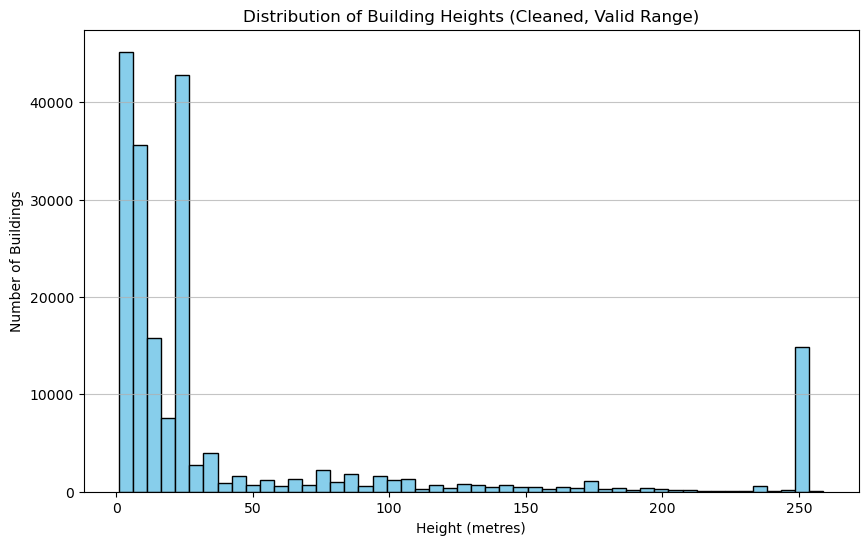

In [27]:
# plot distribution of heights
if 'height' in gdf_bldg.columns:
    h_valid = gdf_bldg['height'].apply(clean_height)
    h_valid = h_valid[(h_valid > 0) & (h_valid < 260)]

    plt.figure(figsize=(10,6))
    plt.hist(h_valid, bins=50, color='skyblue', edgecolor='black')
    plt.title('Distribution of Building Heights (Cleaned, Valid Range)')
    plt.xlabel('Height (metres)')
    plt.ylabel('Number of Buildings')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("height column not found in dataset, cannot plot distribution")

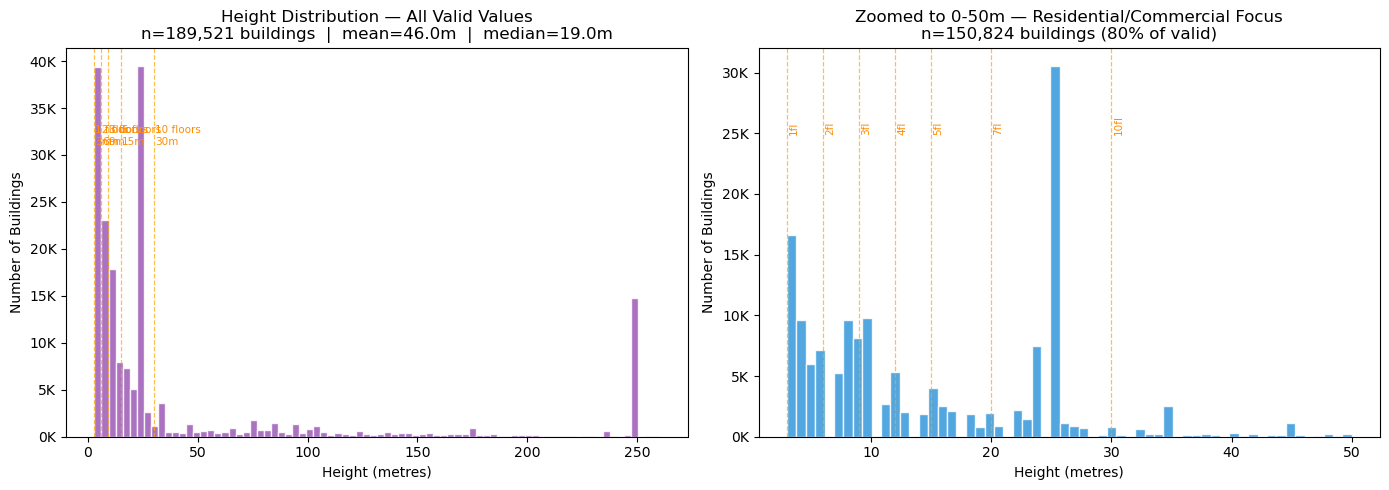

In [ ]:
# HEIGHT DISTRIBUTION (VALID VALUES ONLY)


from matplotlib import ticker


h_smart = gdf_bldg['height'].apply(clean_height)
h_valid = h_smart.where((h_smart > 2) & (h_smart <= 260)).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution up to 260m
axes[0].hist(h_valid, bins=80, color='#9b59b6', edgecolor='white', alpha=0.85)
for h, lbl in [(3,'1 floor\n3m'),(6,'2 floors\n6m'),
               (9,'3 floors\n9m'),(15,'5 floors\n15m'),(30,'10 floors\n30m')]:
    axes[0].axvline(x=h, color='orange', linestyle='--', lw=0.9, alpha=0.7)
    axes[0].text(h+0.5, axes[0].get_ylim()[1]*0.75,
                 lbl, fontsize=7.5, color='darkorange')
axes[0].set_xlabel('Height (metres)')
axes[0].set_ylabel('Number of Buildings')
axes[0].set_title(f'Height Distribution — All Valid Values\n'
                  f'n={len(h_valid):,} buildings  |  mean={h_valid.mean():.1f}m  |  median={h_valid.median():.1f}m')
axes[0].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# Right: zoomed to 0-50m to see residential/commercial clearly
h_zoom = h_valid[h_valid <= 50]
axes[1].hist(h_zoom, bins=60, color='#3498db', edgecolor='white', alpha=0.85)
for h, lbl in [(3,'1fl'),(6,'2fl'),(9,'3fl'),(12,'4fl'),
               (15,'5fl'),(20,'7fl'),(30,'10fl')]:
    axes[1].axvline(x=h, color='orange', linestyle='--', lw=0.9, alpha=0.7)
    axes[1].text(h+0.2, axes[1].get_ylim()[1]*0.78,
                 lbl, fontsize=7.5, color='darkorange', rotation=90)
axes[1].set_xlabel('Height (metres)')
axes[1].set_ylabel('Number of Buildings')
axes[1].set_title(f'Zoomed to 0-50m — Residential/Commercial Focus\n'
                  f'n={len(h_zoom):,} buildings ({len(h_zoom)/len(h_valid)*100:.0f}% of valid)')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()
print()


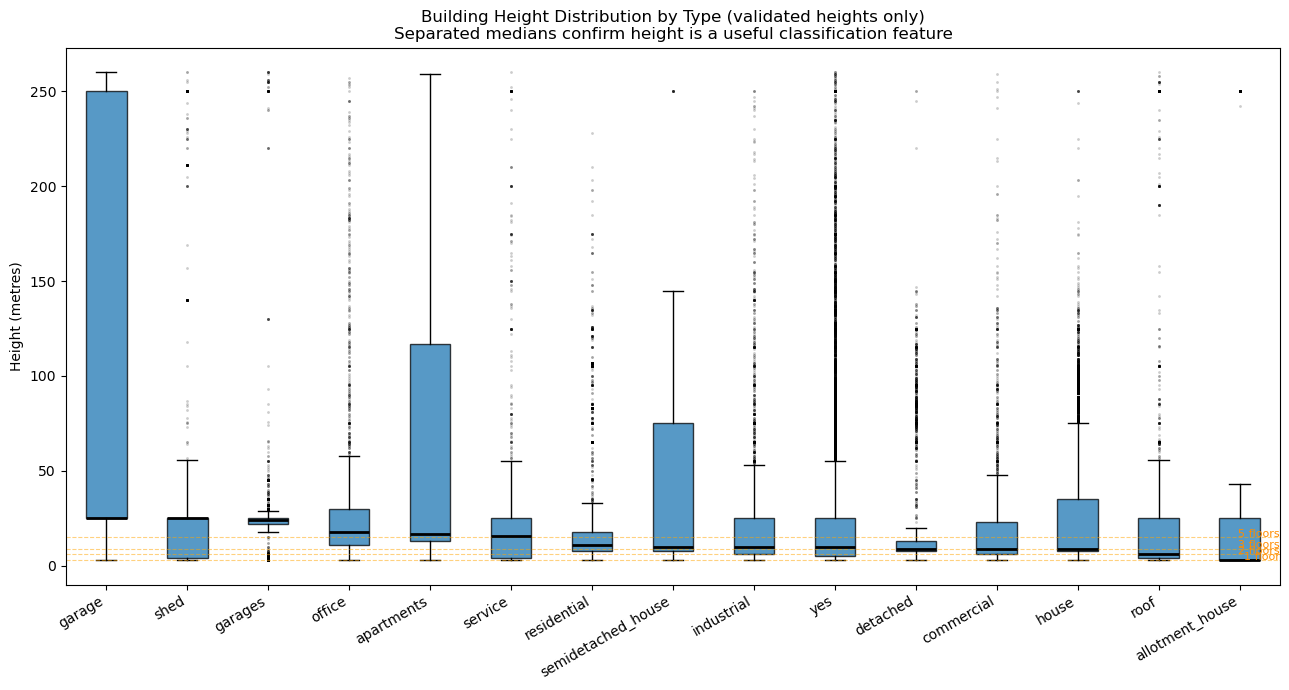

In [ ]:
#  HEIGHT BY BUILDING TYPE (BOXPLOTS)

h_smart = gdf_bldg['height'].apply(clean_height)
gdf_bldg['height_validated'] = h_smart.where((h_smart > 2) & (h_smart <= 260))

# Select types with enough height data for meaningful boxplots
type_height_counts = (gdf_bldg[gdf_bldg['height_validated'].notna()]
                      .groupby('building')['height_validated']
                      .count()
                      .sort_values(ascending=False))

# Take top 15 types that have height data
top_types_h = type_height_counts.head(15).index.tolist()
top_types_h = [t for t in top_types_h if t and str(t) not in ['nan','None']]

plot_data_h = gdf_bldg[gdf_bldg['building'].isin(top_types_h)][
    ['building','height_validated']
].dropna()

# Sort by median height for readability
type_medians = plot_data_h.groupby('building')['height_validated'].median()
top_types_sorted = type_medians.sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(13, 7))
bp_data = [plot_data_h[plot_data_h['building']==t]['height_validated'].values
           for t in top_types_sorted]
bp = ax.boxplot(bp_data, positions=range(len(top_types_sorted)),
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.2))
for patch, btype in zip(bp['boxes'], top_types_sorted):
    patch.set_alpha(0.75)

ax.set_xticks(range(len(top_types_sorted)))
ax.set_xticklabels(top_types_sorted, rotation=30, ha='right')
ax.set_ylabel('Height (metres)')
ax.set_title('Building Height Distribution by Type (validated heights only)\n'
             'Separated medians confirm height is a useful classification feature')

# Add reference lines
for h, lbl in [(3,'1 floor'),(6,'2 floors'),(9,'3 floors'),(15,'5 floors')]:
    ax.axhline(y=h, color='orange', linestyle='--', lw=0.8, alpha=0.5)
    ax.text(len(top_types_sorted)-0.5, h+0.3, lbl,
            fontsize=8, color='darkorange', ha='right')

plt.tight_layout()
plt.show()

gdf_bldg.drop(columns=['height_validated'], inplace=True)

**FINDINGS**
1. Height coverage is very low (0.56%) - this makes it difficult to use height as a primary classification feature for the full dataset

2. Statistics should be recalculated when the height column is cleaned as mean is being very affected by the highly suspicious heights

3. The building type heights are almost all wrong (e.g., garage can't have a mean height of 87.1m, and bungalows are usually one floor)


#### LEVELS vs BUILDING:LEVELS

OSM has TWO floor count fields:
-   building:levels = floors IN the building (standard)
-   levels = total levels including underground and roof levels



In [30]:
# LEVELS vs BUILDING:LEVELS COMPARISON

col = 'levels'
if col in gdf_bldg.columns:
    raw = gdf_bldg[col].notna().sum()
    print(f"LEVELS COLUMN")
    print(f"  Raw non-null : {raw:,}  ({raw/TOTAL*100:.3f}%)")
    print()

    levels_num      = pd.to_numeric(gdf_bldg[col], errors='coerce')
    bldg_levels_num = pd.to_numeric(gdf_bldg.get('building:levels'), errors='coerce')

    # Buildings where BOTH exist
    both_mask = levels_num.notna() & bldg_levels_num.notna()
    print(f"  Buildings with BOTH levels and building:levels: {both_mask.sum():,}")

    if both_mask.sum() > 0:
        diff = (levels_num[both_mask] - bldg_levels_num[both_mask])
        agree    = (diff == 0).sum()
        lev_higher = (diff > 0).sum()
        bldg_higher= (diff < 0).sum()
        print(f"    Same value (agree)          : {agree:,}  ({agree/both_mask.sum()*100:.1f}%)")
        print(f"    levels > building:levels    : {lev_higher:,}  (extra underground/roof levels)")
        print(f"    building:levels > levels    : {bldg_higher:,}  (different convention)")

    # Buildings with ONLY levels (not building:levels)
    only_levels = levels_num.notna() & bldg_levels_num.isna()
    print(f"\n  Buildings with ONLY levels (no building:levels): {only_levels.sum():,}")
    print(f"  These can use 'levels' as a fallback for floor count.")

    print()
    print("  Top raw values:")
    print(gdf_bldg[col].value_counts().head(15).to_string())
else:
    print(f"'{col}' not in dataset")


LEVELS COLUMN
  Raw non-null : 77  (0.000%)

  Buildings with BOTH levels and building:levels: 22
    Same value (agree)          : 17  (77.3%)
    levels > building:levels    : 1  (extra underground/roof levels)
    building:levels > levels    : 4  (different convention)

  Buildings with ONLY levels (no building:levels): 55
  These can use 'levels' as a fallback for floor count.

  Top raw values:
levels
1      35
5      12
3       9
4       8
2       6
10      2
9       1
11      1
17      1
1.5     1
7       1


Levels not very useful as there are only 77 filled values in the entire column

#### BUILDING LEVEL

Number of floors is more directly useful than height for estimating dwellings: dwellings = f(floors, area, type)


BUILDING:LEVELS COLUMN CLEANING ANALYSIS
  Raw non-null values  : 3,664,609  (9.44%)
  Raw null values      : 35,165,394

  RAW SAMPLE (first 30 non-null values):
    ['3', '6', '4', '3', '3']
    ['2', '2', '1', '3', '2']
    ['3', '3', '4', '3.5', '2']
    ['1.5', '2.5', '3', '3', '9']
    ['3', '2', '2', '3', '2']
    ['2', '4', '4', '1', '1']

    Recovered as numeric : 3,664,549  (100.0% of non-null)
    Lost to NaN          : 60  (0.0% of non-null)

  Recover numeric values lost to NaN:
    Total recovered as numeric : 3,664,598  (100.0% of non-null)
    Final lost to NaN          : 11  (0.0% of non-null)
    Extra recovered      : 49 (values saved from NaN)

  UNRECOVERABLE VALUES (11):
building:levels
!                                       2
q                                       2
1 / 2                                   1
Unter Überdachung                       1
Halle                                   1
r                                       1
Heuschopf                    

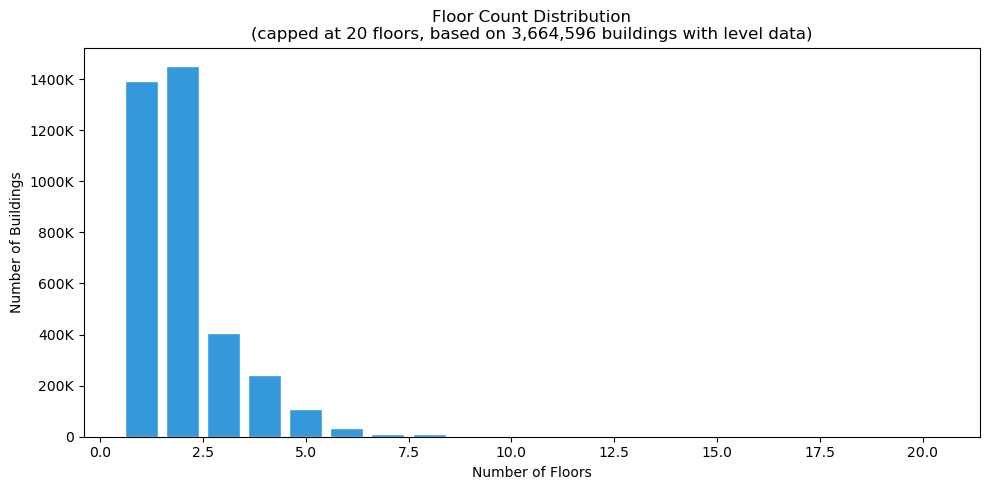

In [ ]:
# BUILDING:LEVELS 

# VALID RANGE FOR GERMANY:
# Min: 1 floor (every building has at least one)
# Max: 60 floors (Millennium Tower Hamburg = 58 floors,
#      tallest residential building in Germany)

# CLEANING STEPS:
# 1. Replace German decimal comma
# 2. Handle attic notation (1+D -> 2, 2+D -> 3)
# 3. Handle Ground+Upper notation (G+1 -> 2)
# 4. Handle German words (Etagen, Geschosse, EG)
# 5. Handle semicolon-separated values -> take max
# 6. Round non-integer values up (1.5 -> 2, mezzanine floors)
# 7. Remove impossible values (< 1 or > 60)

GERMANY_MAX_FLOORS = 60
GERMANY_MIN_FLOORS = 1

def clean_levels(val):
    """
    Extract a valid integer floor count from a raw OSM string.
    Returns int, or NaN if not recoverable.
    """
    if pd.isna(val):
        return np.nan

    s = str(val).strip().lower()

    # Replace German decimal comma
    s = s.replace(',', '.')

    # Handle German ground floor abbreviation
    # EG = Erdgeschoss = ground floor only = 1
    if s in ['eg', 'erdgeschoss', 'ground']:
        return 1

    # Handle attic notation: '1+d', '2+d', '1+dg', '2+dg'
    # D or DG = Dachgeschoss (attic floor) -> add 1
    attic_match = re.match(r'^(\d+\.?\d*)\s*\+\s*d(?:g)?$', s)
    if attic_match:
        base = float(attic_match.group(1))
        return int(base) + 1

    # Handle ground+upper notation: 'g+1', 'g+2', 'eg+1'
    ground_match = re.match(r'^(?:g|eg)\+(\d+)$', s)
    if ground_match:
        upper = int(ground_match.group(1))
        return upper + 1  # ground floor + upper floors

    # Handle German words for floors
    # '5 etagen', '3 geschosse', '2 stockwerke'
    word_match = re.match(
        r'^(\d+\.?\d*)\s*(?:etagen?|geschoss(?:e)?|stockwerk(?:e)?|floors?|étages?)$', s)
    if word_match:
        return max(1, round(float(word_match.group(1))))

    # Handle semicolon-separated values -> take maximum
    # '2;3', '1;2;3', '0;1;2'
    if ';' in s:
        parts = s.split(';')
        nums  = []
        for p in parts:
            try:
                n = float(p.strip())
                if n > 0:
                    nums.append(n)
            except ValueError:
                pass
        if nums:
            return max(1, round(max(nums)))

    # Handle ranges: '2-3', '2–3' -> take ceiling
    range_match = re.match(r'^(\d+\.?\d*)[–\-](\d+\.?\d*)$', s)
    if range_match:
        hi_val = float(range_match.group(2))
        return max(1, round(hi_val))

    # Strip any trailing letters or units and try direct conversion
    s_clean = re.sub(r'[a-zA-ZäöüÄÖÜ\s\+\(\)]', '', s).strip()

    try:
        val_f = float(s_clean)
        # Round non-integer values UP (1.5 floors -> 2, mezzanine)
        return max(1, int(np.ceil(val_f)))
    except (ValueError, TypeError):
        return np.nan


lev_col = 'building:levels'

if lev_col in gdf_bldg.columns:
    raw = gdf_bldg[lev_col].notna().sum()

    print("BUILDING:LEVELS COLUMN CLEANING ANALYSIS")
    print("=" * 58)
    print(f"  Raw non-null values  : {raw:,}  ({raw/TOTAL*100:.2f}%)")
    print(f"  Raw null values      : {gdf_bldg[lev_col].isna().sum():,}")
    print()

    # Show raw sample
    print("  RAW SAMPLE (first 30 non-null values):")
    raw_sample = gdf_bldg[lev_col].dropna().head(30).tolist()
    for i in range(0, len(raw_sample), 5):
        print(f"    {raw_sample[i:i+5]}")
    print()

    # count what it misses with simple numeric conversion
    lev_simple = pd.to_numeric(gdf_bldg[lev_col], errors='coerce')
    simple_clean = lev_simple.notna().sum()
    simple_lost  = raw - simple_clean
    print(f"    Recovered as numeric : {simple_clean:,}  ({simple_clean/raw*100:.1f}% of non-null)")
    print(f"    Lost to NaN          : {simple_lost:,}  ({simple_lost/raw*100:.1f}% of non-null)")
    print()

    # apply the smart cleaning function
    lev_smart = gdf_bldg[lev_col].apply(clean_levels)
    smart_clean     = lev_smart.notna().sum()
    extra_recovered = smart_clean - simple_clean
    print(f"  Recover numeric values lost to NaN:")
    print(f"    Total recovered as numeric : {smart_clean:,}  ({smart_clean/raw*100:.1f}% of non-null)")
    print(f"    Final lost to NaN          : {raw-smart_clean:,}  ({(raw-smart_clean)/raw*100:.1f}% of non-null)")
    print(f"    Extra recovered      : {extra_recovered:,} (values saved from NaN)")
    print()

    # Unrecoverable values
    still_nan = lev_smart.isna() & gdf_bldg[lev_col].notna()
    unrecoverable = gdf_bldg.loc[still_nan, lev_col]
    print(f"  UNRECOVERABLE VALUES ({len(unrecoverable):,}):")
    if len(unrecoverable) > 0:
        print(unrecoverable.value_counts().head(20).to_string())
    print()

    # Validate range
    impossible_lo = (lev_smart < GERMANY_MIN_FLOORS).sum()
    impossible_hi = (lev_smart > GERMANY_MAX_FLOORS).sum()
    valid_mask    = (lev_smart >= GERMANY_MIN_FLOORS) & (lev_smart <= GERMANY_MAX_FLOORS)
    lev_valid     = lev_smart[valid_mask]

    print(f"  RANGE VALIDATION:")
    print(f"    Valid ({GERMANY_MIN_FLOORS} to {GERMANY_MAX_FLOORS} floors) : {len(lev_valid):,}")
    print(f"    Impossible (< {GERMANY_MIN_FLOORS} floor)     : {impossible_lo:,}  <- NaN in pre-processing")
    print(f"    Suspicious (> {GERMANY_MAX_FLOORS} floors)    : {impossible_hi:,}  <- NaN in pre-processing")
    print()

    # Statistics on valid values
    print(f"  STATISTICS (valid range only):")
    print(lev_valid.describe().round(2).to_string())
    print()

    # Most common floor counts
    print(f"  MOST COMMON FLOOR COUNTS:")
    vc = lev_valid.value_counts().sort_index()
    for floors, cnt in vc.items():
        pct = cnt / len(lev_valid) * 100
        bar = '#' * max(1, int(pct / 0.5))
        print(f"    {int(floors):<4} floors : {cnt:>8,}  ({pct:5.1f}%)  {bar}")
    print()

    # Mean floors by building type
    gdf_bldg['levels_clean'] = lev_smart.where(valid_mask)

    print(f"  MEAN FLOORS BY BUILDING TYPE (types with > 200 buildings):")
    print(f"  {'Type':<28} {'Mean floors':>12} {'Median':>8} {'Count':>10}")
    print(f"  {'-'*62}")

    type_lev = (gdf_bldg[gdf_bldg['levels_clean'].notna()]
                .groupby('building')['levels_clean']
                .agg(['mean','median','count'])
                .query('count > 200')
                .sort_values('median', ascending=False))

    for bt, row in type_lev.iterrows():
        print(f"  {str(bt):<28} {row['mean']:>10.1f}  "
              f"{row['median']:>8.0f}  {int(row['count']):>10,}")

    gdf_bldg.drop(columns=['levels_clean'], inplace=True)
    print()

    # Floor count distribution chart
    # Replace the entire chart section at the bottom of the levels cell
    # with just this one chart

    fig, ax = plt.subplots(figsize=(10, 5))

    vc_plot = lev_valid.value_counts().sort_index()
    vc_plot = vc_plot[vc_plot.index <= 20]

    ax.bar(vc_plot.index, vc_plot.values,
        color='#3498db', edgecolor='white')
    ax.set_xlabel('Number of Floors')
    ax.set_ylabel('Number of Buildings')
    ax.set_title(f'Floor Count Distribution\n'
                f'(capped at 20 floors, based on {len(lev_valid):,} buildings with level data)')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K' if x>=1000 else str(int(x))))

    plt.tight_layout()
    plt.show()

else:
    print(f"'{lev_col}' not in dataset")

/tmp/ipykernel_110383/3955286911.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(bp_data,


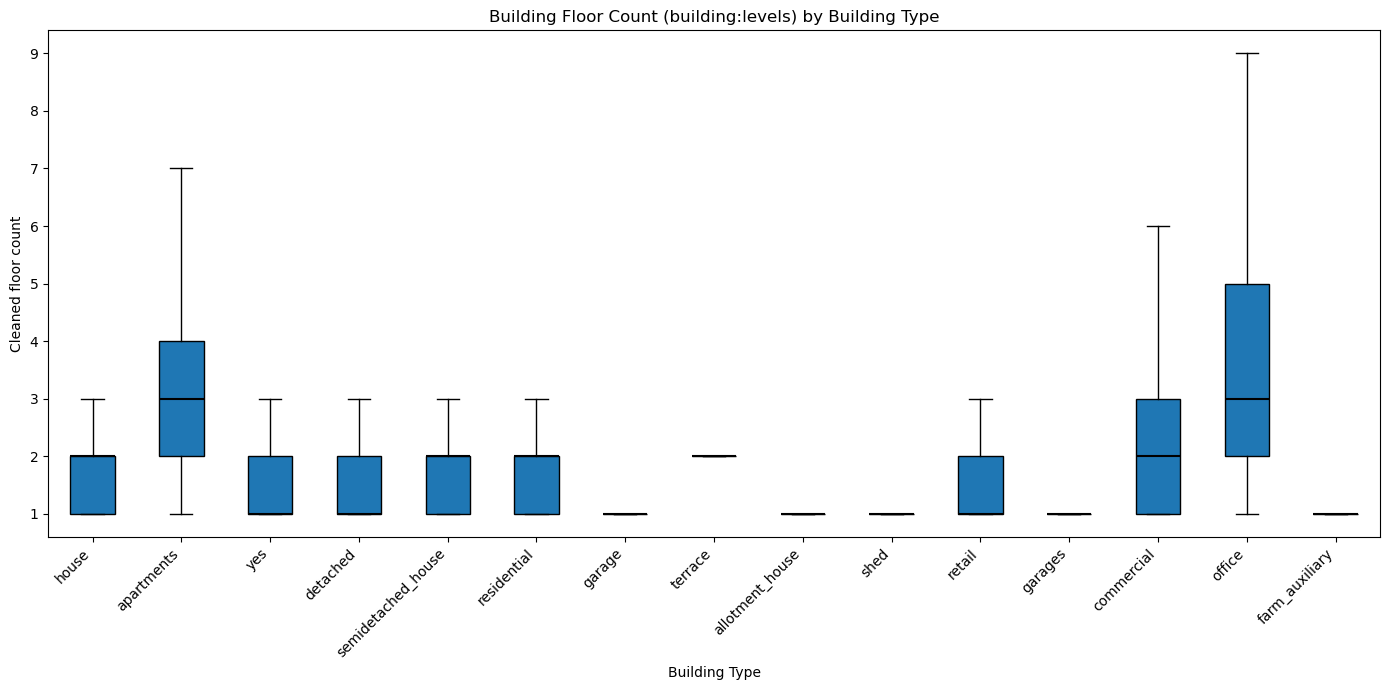

In [32]:
# BOXPLOT: building:levels by building type (for types with enough data)
lev_col = 'building:levels'
if lev_col not in gdf_bldg.columns:
    print(f"'{lev_col}' not in dataset")
else:
    # Recalculate/cleanup levels (clean_levels already defined in cell 42)
    gdf_bldg['levels_clean'] = gdf_bldg[lev_col].apply(clean_levels)
    valid_levels = gdf_bldg['levels_clean'].where(
        (gdf_bldg['levels_clean'] >= GERMANY_MIN_FLOORS) &
        (gdf_bldg['levels_clean'] <= GERMANY_MAX_FLOORS)
    )

    # Build per-type stats
    type_counts = valid_levels.groupby(gdf_bldg['building']).count().sort_values(ascending=False)
    top_types = type_counts.head(15).index.tolist()

    plot_df = gdf_bldg[gdf_bldg['building'].isin(top_types) & valid_levels.notna()]

    if plot_df.empty:
        print("No valid data to plot")
    else:
        fig, ax = plt.subplots(figsize=(14, 7))
        bp_data = [plot_df.loc[plot_df['building'] == t, 'levels_clean'].values for t in top_types]
        ax.boxplot(bp_data,
                   labels=top_types,
                   patch_artist=True,
                   showfliers=False,
                   medianprops=dict(color='black', linewidth=1.5))

        ax.set_title('Building Floor Count (building:levels) by Building Type')
        ax.set_xlabel('Building Type')
        ax.set_ylabel('Cleaned floor count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    # cleanup
    gdf_bldg.drop(columns=['levels_clean'], inplace=True)

/tmp/ipykernel_110383/862496816.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(bp_data,


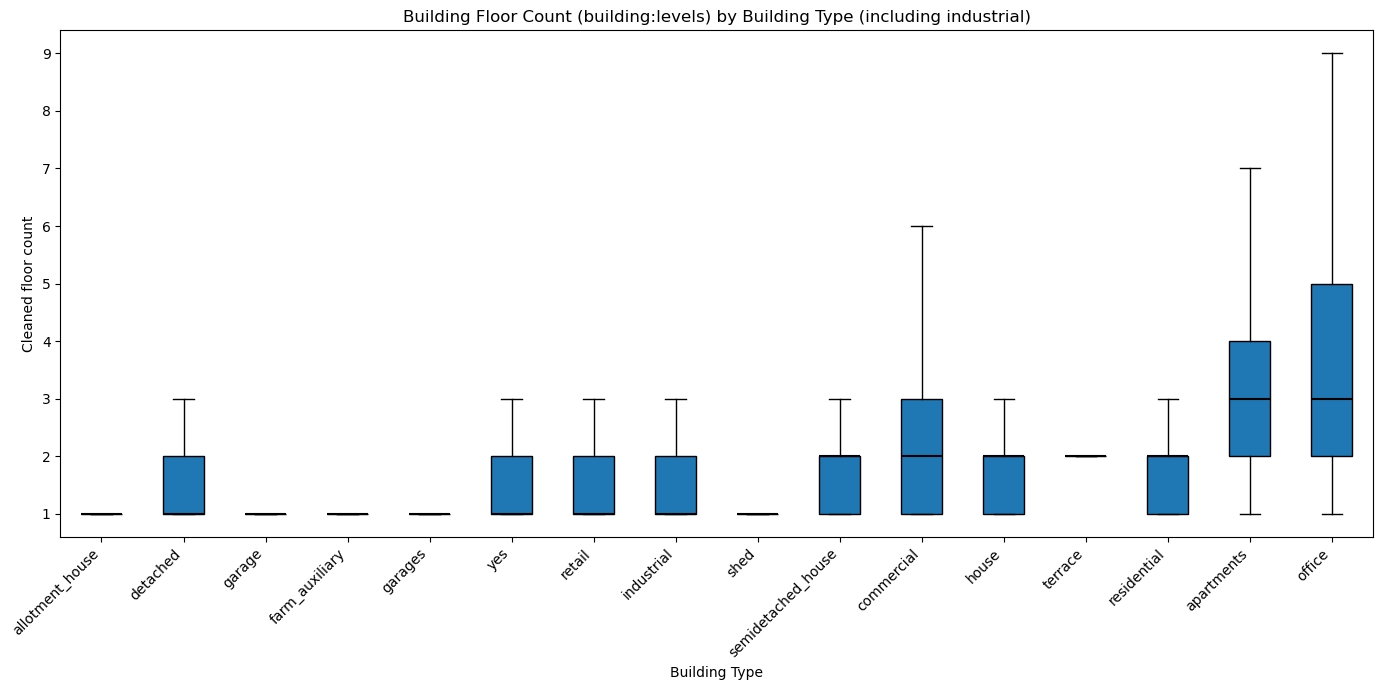

In [33]:
# BOXPLOT: building:levels by building type (including industrial)

import matplotlib.pyplot as plt

# Recalculate levels_clean (assuming clean_levels function is defined from cell 42)
lev_col = 'building:levels'
if lev_col in gdf_bldg.columns:
    gdf_bldg['levels_clean'] = gdf_bldg[lev_col].apply(clean_levels)
    valid_levels = gdf_bldg['levels_clean'].where(
        (gdf_bldg['levels_clean'] >= GERMANY_MIN_FLOORS) &
        (gdf_bldg['levels_clean'] <= GERMANY_MAX_FLOORS)
    )

    # Get type counts
    type_counts = valid_levels.groupby(gdf_bldg['building']).count().sort_values(ascending=False)
    top_types = type_counts.head(15).index.tolist()

    # Ensure 'industrial' is included
    if 'industrial' not in top_types:
        top_types.append('industrial')

    # Filter to types with enough data
    plot_df = gdf_bldg[gdf_bldg['building'].isin(top_types) & valid_levels.notna()]

    if plot_df.empty:
        print("No valid data to plot")
    else:
        # Sort by median levels for better visualization
        medians = plot_df.groupby('building')['levels_clean'].median().sort_values()
        sorted_types = medians.index.tolist()

        fig, ax = plt.subplots(figsize=(14, 7))
        bp_data = [plot_df.loc[plot_df['building'] == t, 'levels_clean'].values
                   for t in sorted_types]
        ax.boxplot(bp_data,
                   labels=sorted_types,
                   patch_artist=True,
                   showfliers=False,
                   medianprops=dict(color='black', linewidth=1.5))

        ax.set_title('Building Floor Count (building:levels) by Building Type (including industrial)')
        ax.set_xlabel('Building Type')
        ax.set_ylabel('Cleaned floor count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    # Cleanup
    gdf_bldg.drop(columns=['levels_clean'], inplace=True)
else:
    print(f"'{lev_col}' not in dataset")

**FINDINGS**
1. Levels coverage is better than height (9.44% vs 0.56%) **should be used as a primary source for floor based dwelling, height can be used as fallback where levels is missing**

2. 77.6% of all buildings with floor data have either 1 or 2 floors

3. it is a stronng classification feature. we can see three distinct tiers in the median column (commercial- 2 floors, industrial- 1 floor)

        > TIER 1 — Tall (median 3+ floors):
        apartments, hospital, hotel, dormitory, university,
        office, government, college, transformer_tower

        > TIER 2 — Medium (median 2 floors):
        house, semidetached_house, residential, commercial,
        church, civic, school, parking, terrace, yes

        > TIER 3 — Low (median 1 floor):
        detached, bungalow, barn, garage, garages, shed,
        greenhouse, allotment_house, hut, carport,         industrial, retail, warehouse, stable, farm_auxiliary

4. it is important to estimate missing values

5. buildings levels can be merged wih the 55 levels not in building levels

#### ADDRESS FIELDS

In [34]:
# ADDRESS FIELDS

addr_cols = ['addr:city', 'addr:country', 'addr:full', 'addr:housenumber',
       'addr:housename', 'addr:postcode', 'addr:place', 'addr:street']


print(f'  {"Column":<25} {"Filled":>10} {"Missing":>10} {"% Filled":>10}')
print('-' * 62)

for col in addr_cols:
    if col in gdf_bldg.columns:
        f = gdf_bldg[col].notna().sum()
        print(f'  {col:<25} {f:>10,} {TOTAL-f:>10,} {f/TOTAL*100:>9.1f}%')
    else:
        print(f'  {col:<25} {"column does not exist":>32}')



  Column                        Filled    Missing   % Filled
--------------------------------------------------------------
  addr:city                 15,472,283 23,357,720      39.8%
  addr:country              11,572,259 27,257,744      29.8%
  addr:full                         88 38,829,915       0.0%
  addr:housenumber          16,103,116 22,726,887      41.5%
  addr:housename                19,766 38,810,237       0.1%
  addr:postcode             15,153,410 23,676,593      39.0%
  addr:place                   177,284 38,652,719       0.5%
  addr:street               16,028,901 22,801,102      41.3%


In [35]:
# ADDRESS COVERAGE BY BUILDING TYPE 
# filter to types with >= 1000 buildings so results are statistically meaningful

# Minimum building count for a type to be included
MIN_COUNT = 1000

# Count buildings per type first
type_counts = gdf_bldg['building'].value_counts()
valid_types  = type_counts[type_counts >= MIN_COUNT].index

# Filter to valid types only
buildings_filtered = gdf_bldg[gdf_bldg['building'].isin(valid_types)]

# Calculate address coverage per type — with include_groups=False
addr_by_type = (buildings_filtered
                .groupby('building', group_keys=False)
                .apply(lambda x: x['addr:street'].notna().sum() / len(x) * 100,
                       include_groups=False)
                .sort_values(ascending=False))

print(f"ADDRESS COVERAGE BY BUILDING TYPE")
print(f"(Only types with >= {MIN_COUNT:,} buildings — statistically meaningful)")
print(f"Total types shown: {len(addr_by_type)}")
print()
print(f"  {'Type':<30} {'% with addr:street':>20} {'Count':>12}")
print(f"  {'—'*65}")

for btype, pct in addr_by_type.items():
    count = type_counts[btype]
    bar   = '#' * int(pct / 3)
    print(f"  {str(btype):<30} {pct:>18.1f}%  {count:>12,}  {bar}")

ADDRESS COVERAGE BY BUILDING TYPE
(Only types with >= 1,000 buildings — statistically meaningful)
Total types shown: 75

  Type                             % with addr:street        Count
  —————————————————————————————————————————————————————————————————
  dwelling_house                               97.0%         4,887  ################################
  supermarket                                  89.2%         3,366  #############################
  house                                        87.0%     3,235,291  ############################
  semidetached_house                           82.7%       418,656  ###########################
  detached                                     81.9%     1,087,977  ###########################
  residential                                  81.8%     1,163,622  ###########################
  apartments                                   78.0%     1,468,741  #########################
  public                                       74.2%        14,663

**Findings**

1. Address coverage follows a clear three-tier pattern aligned with building function and urban/rural location.

| Tier | Coverage | Building Types |
|---|---|---|
| **High (68–100%)** | Urban, always addressable | house 87%, detached 82%, residential 82%, apartments 78%, terrace 74%, retail 70%, civic 69% |
| **Medium (34–67%)** | Mixed urban/rural, inconsistent | hotel 66%, office 66%, church 61%, school 41%, farm 41%, hospital 36%, yes 36% |
| **Low (0–33%)** | Rural, agricultural, infrastructure | industrial 31%, bungalow 27%, warehouse 25%, barn 4%, garage 1%, storage_tank 0% |


2. Residential buildings fall in  75–97% range
  - house (87%), detached (82%), residential (82%), apartments (78%), terrace (74%)
  - Address data is highly reliable for identifying residential buildings
  - No standard residential type (except bungalow) falls below 68%
  - Confirms that a full postal address is a strong residential signal

3. Commercial and Civic — High to Medium (36–89%)
- supermarket (89%), retail (70%), hotel (66%), office (66%),
  civic (69%), university (64%), church (61%)
- Higher tiers are consistent with urban location
- Types below 68% (hotel, office, kindergarten) are just below
  the High boundary  

4. Industrial falls in the low tier
- industrial (31%), warehouse (25%), manufacture (29%)
- Most industrial buildings are not individually addressable
- Industrial infrastructure — storage_tank (0.1%), slurry_tank (0%), digester (0.1%) — have essentially zero coverage
- These belong to industrial complexes and require zone-level load  assignment rather than individual address-based assignment

5. Agricultural (0–5%)
- barn (4%), stable (4%), farm_auxiliary (3%), greenhouse (2%), shed (1%), garage (0.6%)


6. Important Exception: Farm vs Barn Split
- building=farm: 40.6% → Medium tier
- building=barn: 3.9%  → Low tier
- Confirms that `farm` refers to the main farmhouse building
  (which has a postal address) while `barn`, `stable` and `cowshed`
  refer to agricultural outbuildings (which do not)

6. Surprising Finding: Bungalow in Low Tier (27%)
- Despite being a residential type, bungalow falls in the Low tier
- Unlike `house` (87%) and `detached` (82%) which are solidly High,
  bungalow at 27% indicates German bungalows are predominantly
  rural or edge-of-settlement buildings without formal postal addresses
- This is a genuine distributional difference within residential types that the classification model should account for

7. Unclassified Buildings (building=yes) — Bottom of Medium (36%)
- Coverage of 36% places `yes` at the bottom of the Medium tier
- Indicates the unclassified pool is not predominantly residential
- Contains a significant mix of industrial, agricultural and structural
  buildings alongside residential
- The ML model should not assume `building=yes` defaults to residential
- Address presence can help disambiguate these cases

8. Sparse fields that should be dropped
- addr:full (88 rows, 0.0%): pure noise, dropped
- addr:country (29.8%): redundant for a Germany-only dataset, dropped
- addr:housename (0.1%): too sparse for classification value
- addr:place (0.5%): rural location hint only, not a classification signal



**Implication for Modelling**

Raw address fields are not directly useful as classification features.
We can create two derived features:

**`has_full_address`** (binary 0/1)
- True if addr:street + addr:housenumber + addr:postcode all present (strong signal for urban residential and commercial buildings)

**`address_tier`** (ordinal 0 / 1 / 2)
- 0 = no address fields → agricultural / industrial / structural
- 1 = partial address → suburban / mixed use
- 2 = full address → urban residential / commercial
- Captures the three-tier gradient as a single ordinal feature
- Particularly useful for disambiguating `building=yes` buildings

#### SUPPLEMENTARY TAGS
| Column | Why Important |
|---|---|
| `amenity` | Classifies civic and commercial buildings directly |
| `shop` | Classifies commercial buildings directly |
| `office` | Classifies commercial/office buildings directly |
| `building:use` | Explicit use tag — strongest classification signal |
| `landuse` | Zone-level signal for rule-based classification |
| `building:flats` | Direct dwelling count |
| `levels` | Alternative floor field — must compare with building:levels |
| `building:material` | Construction material — proxy for building age |
| `start_date` | Construction year — energy demand estimation |
| `building:min_level` / `building:max_level` | Underground floors and rooftop floors |
| `name` | Can hint at building type via keywords |
| `addr:city` / `addr:postcode` | Location enrichment |

In [36]:
# HELPER FUNCTION FOR STANDARD COLUMN INSPECTION
# shows coverage, top values, examples

def inspect_column(df, col, top_n=20, show_sample=True):
    """
    Standard inspection for any column.
    Shows: coverage, unique count, top values, sample.
    """
    if col not in df.columns:
        print(f"'{col}' does not exist in dataset")
        return

    total   = len(df)
    filled  = df[col].notna().sum()
    missing = total - filled
    unique  = df[col].nunique()

    print(f"COLUMN: '{col}'")
    print(f"  dtype    : {df[col].dtype}")
    print(f"  filled   : {filled:>12,}  ({filled/total*100:.2f}%)")
    print(f"  missing  : {missing:>12,}  ({missing/total*100:.2f}%)")
    print(f"  unique   : {unique:>12,}")
    print()

    if filled > 0:
        print(f"  Top {top_n} values:")
        vc = df[col].value_counts(dropna=True).head(top_n)
        for val, cnt in vc.items():
            pct = cnt / total * 100
            print(f"    {str(val):<40} {cnt:>8,}  ({pct:.3f}%)")
        print()

        if show_sample:
            sample_vals = df[col].dropna().sample(
                min(10, filled), random_state=42).tolist()
            print(f"  Random sample of values:")
            print(f"  {sample_vals}")

    print()

#### AMENITY

In [ ]:
# AMENITY COLUMN INSPECTION

inspect_column(gdf_bldg, 'amenity', top_n=30)

# How many unclassified buildings (yes/null) have amenity filled?
unc_mask    = gdf_bldg['building'].isna() | (gdf_bldg['building'] == 'yes')
unc_amenity = (unc_mask & gdf_bldg['amenity'].notna()).sum()
print(f"RULE-BASED OPPORTUNITY:")
print(f"  Unclassified buildings with amenity tag: {unc_amenity:,}")
print(f"  These can be directly classified in Stage 1 (no ML needed)")
print()
print("Top amenity values for unclassified buildings:")
print(gdf_bldg[unc_mask & gdf_bldg['amenity'].notna()]['amenity']
      .value_counts().head(20).to_string())

COLUMN: 'amenity'
  dtype    : object
  filled   :      251,130  (0.65%)
  missing  :   38,578,873  (99.35%)
  unique   :          555

  Top 30 values:
    place_of_worship                           60,122  (0.155%)
    shelter                                    32,075  (0.083%)
    restaurant                                 19,500  (0.050%)
    fire_station                               16,886  (0.043%)
    community_centre                           13,023  (0.034%)
    social_facility                            10,734  (0.028%)
    kindergarten                                9,385  (0.024%)
    parking                                     7,530  (0.019%)
    school                                      7,164  (0.018%)
    fast_food                                   6,113  (0.016%)
    townhall                                    5,943  (0.015%)
    toilets                                     5,710  (0.015%)
    car_wash                                    4,967  (0.013%)
    fuel       

**FINDINGS**
1. Amenity column is very sparse (0.65% of all buildings) but despite low coverage, can be used as a direct classification
  signal 

2. 139,151 previously unclassified (building=yes) buildings
  have an amenity tag. These can be classified directly in Stage 1 with rule based classification

3. The buildings can be mapped into commercial (restaurant, fast_food, car_wash, fuel, bank, cafe, pub, pharmacy, dentist, clinic) and civic(place_of_worship, fire_station,
community_centre, social_facility, kindergarten, school, townhall, funeral_hall, police, library, nursing_home, childcare) 

4. Need to figure out the broad classificationmapping for types and subtypes as hee are too many (555) unique values

5. Some amenity values that cannot be mapped directly exist (shelter (32,075 total, 20,482 unclassified), parking (7,530), bicycle_parking (4,345), toilets (5,710), trolley_bay (1,051))

6. Top 40 values cover ~95%+ of all amenity-tagged buildings. Remaining ~515 values account for a negligible fraction


7. Implication for Modelling
- Raw amenity field → direct classification rule 
- Mapping: amenity value → taxonomy category applied in Stage 1
- After Stage 1: remove amenity-classified buildings from the
  ML training pool 

In [ ]:
# Apply amenity mapping to buildings
PROJECT_ROOT = '/fast/home/o-olajuyigbe/osm_project/'

sys.path.append(os.path.join(PROJECT_ROOT, 'scripts'))
from amenity_map import apply_amenity_map

gdf_bldg[['amenity_type_l1','amenity_type_l2']] = pd.DataFrame(
    gdf_bldg['amenity'].apply(apply_amenity_map).tolist(),
    index=gdf_bldg.index
)

# Check coverage
total_amenity = gdf_bldg['amenity'].notna().sum()
mapped     = gdf_bldg['amenity_type_l1'].notna().sum()
print(f"Amenity values mapped : {mapped:,} of {total_amenity:,} ({mapped/total_amenity*100:.1f}%)")
print()
print("Subtype frequency:")
print(gdf_bldg['amenity_type_l2'].value_counts().head(20))

Amenity values mapped : 242,258 of 251,130 (96.5%)

Subtype frequency:
amenity_type_l2
religious            60300
food_drink           32853
emergency_service    18276
community            16921
care_facility        12056
retail               11459
kindergarten         10897
school                8551
government_office     6744
office                6225
clinic                5599
cultural              3482
higher_ed              861
recreation             473
hospital               448
animal_keeping         327
greenhouse             148
equestrian             136
accommodation          117
research                95
Name: count, dtype: int64


Might need to reclassify subtypes with very few values

#### SHOP

In [ ]:
# SHOP COLUMN INSPECTION


inspect_column(gdf_bldg, 'shop', top_n=30)

if 'shop' in gdf_bldg.columns:
    has_shop = gdf_bldg['shop'].notna()

    # What building tags do shop buildings have?
    print("BUILDING TAG FOR BUILDINGS WITH SHOP:")
    print("(Shows which building types contain shops)")
    print(gdf_bldg[has_shop]['building'].value_counts(dropna=False).head(15).to_string())
    print()

    # Semi-commercial detection: residential tag + shop
    res_tags = ['house','residential','apartments','detached',
                'semidetached_house','terrace']
    semi_comm_mask = has_shop & gdf_bldg['building'].isin(res_tags)
    print(f"SEMI-COMMERCIAL SIGNAL:")
    print(f"  Buildings with residential tag + shop : {semi_comm_mask.sum():,}")
    print(f"  These are confirmed semi-commercial buildings")
    if semi_comm_mask.sum() > 0:
        print(f"  Shop types on residential buildings:")
        print(gdf_bldg[semi_comm_mask]['shop'].value_counts().head(10).to_string())

COLUMN: 'shop'
  dtype    : object
  filled   :       82,418  (0.21%)
  missing  :   38,747,585  (99.79%)
  unique   :          614

  Top 30 values:
    supermarket                                16,574  (0.043%)
    car_repair                                  8,869  (0.023%)
    car                                         7,904  (0.020%)
    bakery                                      2,924  (0.008%)
    beverages                                   2,855  (0.007%)
    doityourself                                2,609  (0.007%)
    clothes                                     2,347  (0.006%)
    hairdresser                                 2,084  (0.005%)
    furniture                                   1,997  (0.005%)
    kiosk                                       1,867  (0.005%)
    florist                                     1,669  (0.004%)
    mall                                        1,503  (0.004%)
    butcher                                     1,359  (0.003%)
    convenience   

In [40]:
# What shop types appear on industrial buildings?
ind_shop = gdf_bldg[
    (gdf_bldg['building'] == 'industrial') & 
    gdf_bldg['shop'].notna()
]['shop'].value_counts().head(15)
print("Shop types on industrial buildings:")
print(ind_shop.to_string())

Shop types on industrial buildings:
shop
car_repair      699
car             348
trade            70
tyres            56
doityourself     50
wholesale        50
car_parts        39
furniture        37
hardware         30
beverages        26
motorcycle       23
butcher          15
electronics      14
craft            14
bakery           10


In [ ]:
# Apply shop mapping to buildings
PROJECT_ROOT = '/fast/home/o-olajuyigbe/osm_project/'
sys.path.append(os.path.join(PROJECT_ROOT, 'scripts'))
from shop_map import apply_shop_map

gdf_bldg[['shop_type_l1','shop_type_l2']] = pd.DataFrame(
    gdf_bldg['shop'].apply(apply_shop_map).tolist(),
    index=gdf_bldg.index
)

# Check coverage
total_shop = gdf_bldg['shop'].notna().sum()
mapped     = gdf_bldg['shop_type_l1'].notna().sum()
print(f"Shop values mapped : {mapped:,} of {total_shop:,} ({mapped/total_shop*100:.1f}%)")
print()
print("Subtype frequency:")
print(gdf_bldg['shop_type_l2'].value_counts().head(20))

Shop values mapped : 82,310 of 82,418 (99.9%)

Subtype frequency:
shop_type_l2
retail           74186
other_service     3846
food_drink        2932
office            1301
disused              3
school               1
Name: count, dtype: int64


**FINDINGS**
1. Very low coverage but can be sed as direct classification (can buildins are commercial and subtypes can be derived from here like amenity)

2. car related shops dominate and these can be seen as semi-industrial for energy demand due to the equipment used

3. 55.2% unclassified buildings with a shop can be direcly tagged in the stage 1 rule classification

4. 3,195 buildings are semi-commercial as they belon to the residential building type

5. There are 1,796 indusrial buildings with a shop. Further exploration showed most shops were car related (point 2). Others are businesses that need industrial-scale space but serve retail customers.

#### BUILDING USE
building:use can be a more specific tag than building=*
- Semicolon-separated values indicate mixed use

In [42]:
# BUILDING:USE INSPECTION

inspect_column(gdf_bldg, 'building:use', top_n=30)

if 'building:use' in gdf_bldg.columns:
    has_use = gdf_bldg['building:use'].notna()
    if has_use.sum() > 0:
        # Check for semicolon-combined values (mixed use)
        mixed = gdf_bldg[has_use]['building:use'].str.contains(';', na=False).sum()
        print(f"Mixed use (semicolon-separated values): {mixed:,}")
        if mixed > 0:
            print("Examples of mixed use building:use values:")
            mixed_examples = gdf_bldg[
                has_use & gdf_bldg['building:use'].str.contains(';', na=False)
            ]['building:use'].value_counts()
            print(mixed_examples.to_string())
        print()

        # Does building:use disagree with building tag?
        print("BUILDING TAG FOR BUILDINGS WITH building:use:")
        print(gdf_bldg[has_use]['building'].value_counts(dropna=False).head(30).to_string())
        
        

COLUMN: 'building:use'
  dtype    : object
  filled   :      200,338  (0.52%)
  missing  :   38,629,665  (99.48%)
  unique   :          319

  Top 30 values:
    residential                               165,868  (0.427%)
    residential;industrial                     14,254  (0.037%)
    residential;commercial                      2,943  (0.008%)
    commercial                                  2,822  (0.007%)
    industrial                                  2,739  (0.007%)
    garage                                      1,395  (0.004%)
    office                                      1,339  (0.003%)
    agricultural                                1,097  (0.003%)
    education                                     695  (0.002%)
    gathering                                     579  (0.001%)
    storage                                       527  (0.001%)
    religious                                     490  (0.001%)
    public;residential                            446  (0.001%)
    depot 

In [43]:
# Isolate the residential;industrial buildings
res_ind = gdf_bldg[gdf_bldg['building:use'] == 'residential;industrial'].copy()
print(f"Total: {len(res_ind):,}")

# Look at the 'name', 'operator', or 'craft' tags
# This is where the truth usually hides!
print("TOP NAMES (What businesses are these?):")
if 'name' in res_ind.columns:
    print(res_ind['name'].value_counts().head(10))

print("\nTOP CRAFTS (If the 'craft' column exists):")
if 'craft' in res_ind.columns:
    print(res_ind['craft'].value_counts().head(10))


res_ind.head(30)


Total: 14,254
TOP NAMES (What businesses are these?):
name
Haar Paradies                                 1
Herkules-Hochhaus                             1
Vitalis Pflegedienst Kölner Norden            1
Hafenamt                                      1
A.T.U                                         1
Oranieneck                                    1
Seniorenheim Oranienhof                       1
Kolumbahaus                                   1
Kunsthochschule für Medien - Vor St.Martin    1
Naturheilpraxis Meschede                      1
Name: count, dtype: int64

TOP CRAFTS (If the 'craft' column exists):
craft
electrician            1
scaffolder             1
sculptor;stonemason    1
Name: count, dtype: int64


,addr:city,addr:country,addr:full,addr:housenumber,addr:housename,addr:postcode,addr:place,addr:street,email,name,opening_hours,operator,phone,ref,url,visible,website,building,amenity,building:flats,building:levels,building:material,building:max_level,building:min_level,building:fireproof,building:use,craft,height,internet_access,landuse,levels,office,shop,source,start_date,wikipedia,id,timestamp,version,tags,osm_type,geometry,changeset,amenity_type_l1,amenity_type_l2,shop_type_l1,shop_type_l2
13678,Köln,DE,NaN,1,NaN,50823,NaN,Graeffstraße,NaN,Herkules-Hochhaus,NaN,NaN,NaN,NaN,NaN,False,http://www.herkules-hochhaeuser.de/,yes,NaN,NaN,31,NaN,NaN,NaN,NaN,residential;industrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,photography,NaN,de:Herkules-Hochhaus,24017666,1689104958,12,"{""level"":""1"",""wikidata"":""Q1610073"",""wikimedia_...",way,"POLYGON ((6.9336 50.95049, 6.93354 50.95043, 6...",NaN,None,None,None,None
28708,Köln,DE,NaN,2,NaN,50667,NaN,Wallrafplatz,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,apartments,NaN,NaN,6,NaN,NaN,NaN,NaN,residential;industrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,photography,NaN,NaN,25257556,1648289711,11,"{""roof:shape"":""flat""}",way,"POLYGON ((6.9566 50.9403, 6.95659 50.94026, 6....",NaN,None,None,None,None
37362,Köln,DE,NaN,20,NaN,50767,NaN,Haselnußweg,NaN,Vitalis Pflegedienst Kölner Norden,NaN,Vitalis,NaN,NaN,NaN,False,NaN,yes,social_facility,NaN,1,NaN,NaN,NaN,NaN,residential;industrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26134631,1762869721,12,"{""check_date"":""2025-11-11"",""contact:email"":""vi...",way,"POLYGON ((6.90534 51.01117, 6.90531 51.01119, ...",NaN,civic,care_facility,None,None
38442,Köln,DE,NaN,2,NaN,50678,NaN,Harry-Blum-Platz,NaN,Hafenamt,NaN,NaN,NaN,NaN,NaN,False,NaN,office,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residential;industrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yahoo,NaN,NaN,26230009,1764509321,12,"{""image"":""https://commons.wikimedia.org/wiki/F...",way,"POLYGON ((6.96588 50.92526, 6.96588 50.92527, ...",NaN,None,None,None,None
42806,Köln,DE,NaN,435,NaN,51067,NaN,Piccoloministraße,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,yes,NaN,NaN,8,NaN,NaN,NaN,NaN,residential;industrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yahoo,NaN,NaN,26677436,1762015575,8,"{""roof:colour"":""silver"",""roof:material"":""tar_p...",way,"POLYGON ((7.04849 50.97322, 7.04849 50.97323, ...",NaN,None,None,None,None
42807,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,yes,NaN,NaN,3,NaN,NaN,NaN,NaN,residential;industrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26677462,1697220420,5,"{""roof:levels"":""2""}",way,"POLYGON ((7.0425 50.97321, 7.04253 50.97309, 7...",NaN,None,None,None,None
52140,Köln,DE,NaN,51-55,NaN,50668,NaN,Marzellenstraße,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residential;industrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27274759,1449858705,7,NaN,way,"POLYGON ((6.95578 50.94478, 6.95578 50.94477, ...",NaN,None,None,None,None
52173,Köln,DE,NaN,44,NaN,50823,NaN,Jessestraße,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residential;industrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yahoo,NaN,NaN,27277297,1432322158,4,NaN,way,"POLYGON ((6.92237 50.955, 6.92233 50.95496, 6....",NaN,None,None,None,None
52175,Köln,DE,NaN,140,NaN,50823,NaN,Ehrenfeldgürtel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,apartments,NaN,NaN,NaN,NaN,NaN,NaN,NaN,residential;industrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yahoo,NaN,NaN,27277355,1574373580,7,NaN,way,"POLYGON ((6.92147 50.95457, 6.92162 50.95452, ...",NaN,None,None,None,None
52182,Köln,DE,NaN,204,NaN,50823,NaN,Subbelrather Straße,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,yes,NaN,NaN,4,NaN,NaN,NaN,NaN,residential;industrial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27277462,1575556919,7,"{""roof:shape"":""gabled""}",way,"POLYGON ((6.92208 50.9532, 6.92216 50.95329, 6...",NaN,None,None,None,None


In [44]:
# Count how many residential+industrial buildings are in Köln
koln_mask = res_ind['addr:city'].astype(str).str.strip().str.lower().isin(['köln', 'koln'])
count_koln = koln_mask.sum()

print(f"res_ind rows in Köln: {count_koln:,}")

# percentage of res_ind that are in Köln
if len(res_ind) > 0:
    perc_koln = count_koln / len(res_ind) * 100
    print(f"Percentage of res_ind in Köln: {perc_koln:.1f}%")

res_ind rows in Köln: 13,814
Percentage of res_ind in Köln: 96.9%


In [45]:
# Apply building use mapping to buildings
sys.path.append(os.path.join(PROJECT_ROOT, 'scripts'))
from buildinguse_map import apply_building_use_map

gdf_bldg[['building_use_l1','building_use_l2','is_mixed']] = pd.DataFrame(
    gdf_bldg['building:use'].apply(apply_building_use_map).tolist(),
    index=gdf_bldg.index
)

# Check coverage
total_building_use = gdf_bldg['building:use'].notna().sum()
mapped     = gdf_bldg['building_use_l1'].notna().sum()
print(f"Building use values mapped : {mapped:,} of {total_building_use:,} ({mapped/total_building_use*100:.1f}%)")
print()
print("Type frequency:")
print(gdf_bldg['building_use_l1'].value_counts().head(20))
print()
print("Subtype frequency:")
print(gdf_bldg['building_use_l2'].value_counts().head(20))
print()
print("Mixed use flag:")
print(gdf_bldg['is_mixed'].value_counts())

Building use values mapped : 184,076 of 200,338 (91.9%)

Type frequency:
building_use_l1
residential        166170
commercial           5247
semi_commercial      3572
industrial           3056
civic                2867
filter               1700
agricultural         1344
transportation        120
Name: count, dtype: int64

Subtype frequency:
building_use_l2
residential_commercial    2973
office                    1411
school                     953
religious                  570
residential_civic          451
accommodation              421
retail                     401
manufacturing              266
recreation                 254
cultural                   199
food_drink                 190
MFH                        190
equestrian                 176
clinic                     151
residential_retail         101
parking                     99
kindergarten                92
hospital                    76
government_office           76
farm_auxiliary              50
Name: count, dtype: i

**FINDINGS**

1. It is only 0.52% filled, but it provides over 200,000 highly precise labels that can be used for direct classification for 46,000 buildings that are currently untagged

2. It explicitly identifies mixed-use buildings (like residential;commercial) using semicolons

3. There is a massive spike in residential;industrial tags (14,254 buildings), and with further exploration can be iidentifies as a localized mapping error as ~97% of the tags are isolated to a single city (Köln) and are applied to some clearly non-industrial buildings such as a 31-story residential tower ('Herkules-Hochhaus'), "Hafenamt" (Port Authority office), and "Seniorenheim Oranienhof" (Senior citizen home), so the res,ind tag shouldn't be trusted

**Actionable Next Steps**
-  Write a pre-processing rule to erase building:use = residential;industrial 


#### OFFICE

In [ ]:
# OFFICE COLUMN INSPECTION

inspect_column(gdf_bldg, 'office', top_n=20)

if 'office' in gdf_bldg.columns:
    has_office = gdf_bldg['office'].notna()
    print("BUILDING TAG FOR BUILDINGS WITH OFFICE:")
    print(gdf_bldg[has_office]['building'].value_counts(dropna=False).head(10).to_string())
    print()

    res_tags = ['house','residential','apartments','detached','semidetached_house','terrace']
    semi_office = has_office & gdf_bldg['building'].isin(res_tags)
    print(f"Residential buildings with office tag (semi-commercial): {semi_office.sum():,}")

COLUMN: 'office'
  dtype    : object
  filled   :       19,731  (0.05%)
  missing  :   38,810,272  (99.95%)
  unique   :          202

  Top 20 values:
    company                                     5,934  (0.015%)
    government                                  3,521  (0.009%)
    religion                                    1,082  (0.003%)
    yes                                           887  (0.002%)
    insurance                                     854  (0.002%)
    association                                   831  (0.002%)
    it                                            637  (0.002%)
    educational_institution                       426  (0.001%)
    employment_agency                             417  (0.001%)
    research                                      403  (0.001%)
    parish                                        329  (0.001%)
    logistics                                     297  (0.001%)
    lawyer                                        274  (0.001%)
    estate_agent

In [47]:
# Check what office types appear on industrial buildings
# to understand the office-in-industrial-premises pattern
ind_office = gdf_bldg[
    (gdf_bldg['building'] == 'industrial') &
    gdf_bldg['office'].notna()
]['office'].value_counts().head(10)
print("Office types on industrial buildings:")
print(ind_office.to_string())

Office types on industrial buildings:
office
company                 673
yes                      27
logistics                22
it                       18
research                 16
advertising_agency       12
moving_company           11
government                9
engineer                  8
construction_company      4


**FINDINGS**

1. The office tag is extremely sparse (~0.05%), but can be used as direct classification for 10,499 untagged buildings

2. Not all offices are commercial, some fall in under the civic type (government, religion, association, public, ngo, educational_institution, etc)

3. A total of 1,074 residential buildings contain office activities an can be classified as semi-commercial.

4. Offices also fall in the industrial type- these are administrative offices within industrial complexes

**since the office types of on industrial buildings overlap with types on commercial buildings e.g company, there won't be a direct map for office, rather it will be used in rule based, e.g for semi commercial buildings**

#### BUILDING:FLATS

It directly states how many dwelling units are in a building

In [48]:
# BUILDING:FLATS INSPECTION AND CLEANING

# CLEANING:
# Stored as string — convert to integer.
# Remove impossible values (<= 0 or > 500).

col = 'building:flats'
if col in gdf_bldg.columns:
    raw = gdf_bldg[col].notna().sum()
    print(f"BUILDING:FLATS COLUMN")
    print(f"  Raw non-null    : {raw:,}  ({raw/TOTAL*100:.3f}%)")
    print()

    # Show raw sample
    print("  Raw sample:")
    print(f"  {gdf_bldg[col].dropna().head(20).tolist()}")
    print()

    # Clean: convert to numeric
    flats_num = pd.to_numeric(gdf_bldg[col], errors='coerce')
    clean = flats_num.notna().sum()
    print(f"  Numeric after pd.to_numeric : {clean:,}  ({clean/raw*100:.1f}% of non-null)")

    # Validate range
    valid_mask  = (flats_num >= 1) & (flats_num <= 500)
    flats_valid = flats_num[valid_mask]
    impossible  = (flats_num < 1).sum()
    suspicious  = (flats_num > 500).sum()

    print(f"\n  RANGE VALIDATION:")
    print(f"    Valid (1-500 flats)   : {len(flats_valid):,}")
    print(f"    Impossible (< 1)     : {impossible:,}")
    print(f"    Suspicious (> 500)   : {suspicious:,}")

    if len(flats_valid) > 0:
        print(f"\n  STATISTICS (valid range):")
        print(flats_valid.describe().round(1).to_string())
        print()

        print("  MOST COMMON FLAT COUNTS:")
        vc = flats_valid.value_counts().sort_index().head(30)
        for val, cnt in vc.items():
            pct = cnt / len(flats_valid) * 100
            bar = '#' * max(1, int(pct/1))
            print(f"    {int(val):<5} flats : {cnt:>6,}  ({pct:5.1f}%)  {bar}")
        print()

        # Mean flats by building type
        gdf_bldg['flats_clean'] = flats_num.where(valid_mask)
        type_flats = (gdf_bldg[gdf_bldg['flats_clean'].notna()]
                      .groupby('building')['flats_clean']
                      .agg(['mean','median','count'])
                      .query('count > 10')
                      .sort_values('median', ascending=False))

        print("  MEAN FLATS BY BUILDING TYPE (types with > 10 buildings):")
        print(f"  {'Type':<28} {'Mean':>8} {'Median':>8} {'Count':>8}")
        print(f"  {'—'*56}")
        for bt, row in type_flats.iterrows():
            print(f"  {str(bt):<28} {row['mean']:>8.1f} {row['median']:>8.0f} {int(row['count']):>8,}")

        gdf_bldg.drop(columns=['flats_clean'], inplace=True)

    # Unrecoverable
    unrecov = gdf_bldg.loc[flats_num.isna() & gdf_bldg[col].notna(), col]
    if len(unrecov) > 0:
        print(f"\n  UNRECOVERABLE VALUES ({len(unrecov):,}):")
        print(unrecov.value_counts().head(10).to_string())
else:
    print(f"'{col}' not in dataset")

BUILDING:FLATS COLUMN
  Raw non-null    : 16,329  (0.042%)

  Raw sample:
  ['9', '40', '59', '10', '2', '3', '10', '4', '6', '55', '8', '4', '3', '2', '4', '4', '22', '23', '22', '136']

  Numeric after pd.to_numeric : 16,314  (99.9% of non-null)

  RANGE VALIDATION:
    Valid (1-500 flats)   : 16,244
    Impossible (< 1)     : 70
    Suspicious (> 500)   : 0

  STATISTICS (valid range):
count    16244.0
mean         6.0
std         13.7
min          1.0
25%          1.0
50%          3.0
75%          6.0
max        447.0

  MOST COMMON FLAT COUNTS:
    1     flats :  4,932  ( 30.4%)  ##############################
    2     flats :  2,694  ( 16.6%)  ################
    3     flats :  1,328  (  8.2%)  ########
    4     flats :  1,213  (  7.5%)  #######
    5     flats :    562  (  3.5%)  ###
    6     flats :  1,625  ( 10.0%)  ##########
    7     flats :    266  (  1.6%)  #
    8     flats :  1,005  (  6.2%)  ######
    9     flats :    322  (  2.0%)  #
    10    flats :    408  (  

**FINDINGS**

1. Coverage very low (0.042%)

2. Strong correlation with building type (apartments have the highest flat count, with a mean of 9.3 and median  of 6)

3. Houses or residential buildings with one flat can be classified into Single family homes

4. Flats support residential classification and enable flat-count inference for missing buildings.

#### CRAFT

These are commercial/industrial buildings that can be classified directly from the craft tag.

In [49]:
#  CRAFT COLUMN 

if 'craft' in gdf_bldg.columns:
    raw = gdf_bldg['craft'].notna().sum()
    if raw > 0:
        print(f"CRAFT COLUMN: {raw:,} buildings ({raw/TOTAL*100:.3f}%)")
        print(gdf_bldg['craft'].value_counts().head(20).to_string())
        print()
        # Craft on unclassified buildings
        unc_mask = gdf_bldg['building'].isna() | (gdf_bldg['building']=='yes')
        unc_craft = (unc_mask & gdf_bldg['craft'].notna()).sum()
        print(f"Unclassified buildings with craft tag: {unc_craft:,}")
        print("These are classifiable as Commercial or Industrial by rule.")
    else:
        print("craft column exists but is entirely empty")
else:
    print("'craft' not in dataset")



CRAFT COLUMN: 14,826 buildings (0.038%)
craft
carpenter               1627
metal_construction      1328
electrician              886
plumber                  882
winery                   743
joiner                   725
hvac                     680
painter                  669
gardener                 650
roofer                   582
stonemason               576
sawmill                  356
agricultural_engines     326
builder                  325
window_construction      314
brewery                  305
beekeeper                297
tiler                    217
yes                      204
glaziery                 187

Unclassified buildings with craft tag: 9,806
These are classifiable as Commercial or Industrial by rule.


**Create craft mapping**

#### LANDUSE

In [ ]:
# LANDUSE COLUMN IN BUILDINGS DATASET


inspect_column(gdf_bldg, 'landuse', top_n=20)

if 'landuse' in gdf_bldg.columns:
    has_lu = gdf_bldg['landuse'].notna()
    if has_lu.sum() > 0:
        # How many unclassified buildings have direct landuse tag?
        unc_mask = gdf_bldg['building'].isna() | (gdf_bldg['building']=='yes')
        unc_with_lu = (unc_mask & has_lu).sum()
        print(f"Unclassified buildings with direct landuse tag: {unc_with_lu:,}")
        print("These can be partially classified by landuse alone.")

COLUMN: 'landuse'
  dtype    : object
  filled   :        3,005  (0.01%)
  missing  :   38,826,998  (99.99%)
  unique   :           41

  Top 20 values:
    greenhouse_horticulture                       985  (0.003%)
    garages                                       499  (0.001%)
    industrial                                    351  (0.001%)
    military                                      271  (0.001%)
    farmyard                                      149  (0.000%)
    retail                                        137  (0.000%)
    residential                                   134  (0.000%)
    basin                                          84  (0.000%)
    reservoir                                      80  (0.000%)
    commercial                                     60  (0.000%)
    construction                                   55  (0.000%)
    quarry                                         37  (0.000%)
    brownfield                                     22  (0.000%)
    religious  

**FINDINGS**

Unclassified buildings with direct landuse tag: 1,798
These can be partially classified by landuse alone.

**Create landuse map**

#### Other columns

In [51]:
#  MIN/MAX LEVEL INSPECTION

for col in ['building:min_level', 'building:max_level']:
    if col in gdf_bldg.columns:
        raw = gdf_bldg[col].notna().sum()
        print(f"{col.upper()}")
        print(f"  Non-null : {raw:,}  ({raw/TOTAL*100:.4f}%)")

        num = pd.to_numeric(gdf_bldg[col], errors='coerce')
        valid = num.dropna()
        if len(valid) > 0:
            print(f"  Statistics:")
            print(valid.describe().round(1).to_string())

            if col == 'building:min_level':
                underground = (valid < 0).sum()
                print(f"  Underground floors (< 0): {underground:,}")
                print(f"  Distribution of negative values:")
                print(valid[valid < 0].value_counts().head(10).to_string())
        print()
    else:
        print(f"'{col}' not in dataset")
        print()

BUILDING:MIN_LEVEL
  Non-null : 4,597  (0.0118%)
  Statistics:
count    4596.0
mean        1.3
std         0.8
min        -2.0
25%         1.0
50%         1.0
75%         1.0
max        12.0
  Underground floors (< 0): 28
  Distribution of negative values:
building:min_level
-1.0    22
-2.0     4
-0.5     2

BUILDING:MAX_LEVEL
  Non-null : 32  (0.0001%)
  Statistics:
count    32.0
mean      2.5
std       1.7
min      -1.0
25%       1.0
50%       2.5
75%       4.0
max       8.0



In [52]:
#  BUILDING:MATERIAL INSPECTION

inspect_column(gdf_bldg, 'building:material', top_n=30)

if 'building:material' in gdf_bldg.columns:
    has_mat = gdf_bldg['building:material'].notna()
    if has_mat.sum() > 0:
        print("MATERIAL BY BUILDING TYPE (top types):")
        mat_type = (gdf_bldg[has_mat]
                    .groupby('building')['building:material']
                    .value_counts().sort_values(ascending=False)
                    .groupby(level=0)
                    .head(3)
                    .reset_index())
        print(mat_type.head(30).to_string(index=False))

COLUMN: 'building:material'
  dtype    : object
  filled   :      227,414  (0.59%)
  missing  :   38,602,589  (99.41%)
  unique   :          304

  Top 30 values:
    plaster                                   126,423  (0.326%)
    brick                                      50,146  (0.129%)
    concrete                                   15,463  (0.040%)
    wood                                       11,336  (0.029%)
    timber_framing                              5,449  (0.014%)
    glass                                       4,979  (0.013%)
    metal                                       3,731  (0.010%)
    stone                                       2,386  (0.006%)
    roof_tiles                                  1,390  (0.004%)
    slate                                       1,025  (0.003%)
    sandstone                                     899  (0.002%)
    plastic                                       406  (0.001%)
    tar_paper                                     377  (0.001%)
    s

In [ ]:
# QUICK SCAN OF REMAINING COLUMNS

low_value_cols = [
    'operator', 'ref', 'wikipedia', 'url', 'website',
    'opening_hours', 'phone', 'start_date', 'email', 'internet_access',
    'building:fireproof', 'source',
    'visible', 'timestamp', 'version', 'changeset'
]

print("LOW-VALUE COLUMN COVERAGE SCAN")
print("-" * 55)
print(f"  {'Column':<30} {'Filled':>10} {'% Filled':>10}")
print("-" * 55)

for col in low_value_cols:
    if col in gdf_bldg.columns:
        f   = gdf_bldg[col].notna().sum()
        pct = f / TOTAL * 100
        print(f"  {col:<30} {f:>10,} {pct:>9.3f}%")
    else:
        print(f"  {col:<30} {'not in dataset':>20}")



LOW-VALUE COLUMN COVERAGE SCAN
-------------------------------------------------------
  Column                             Filled   % Filled
-------------------------------------------------------


  operator                          138,978     0.358%
  ref                                43,598     0.112%
  wikipedia                          36,470     0.094%
  url                                 4,014     0.010%
  website                           134,717     0.347%
  opening_hours                      90,461     0.233%
  phone                              78,512     0.202%
  start_date                        116,389     0.300%
  email                              33,147     0.085%
  internet_access                    11,532     0.030%
  building:fireproof                 17,139     0.044%
  source                          3,344,640     8.614%
  visible                        38,802,474    99.929%
  timestamp                      38,830,003   100.000%
  version                        38,830,003   100.000%
  changeset                          27,529     0.071%


**Drop columns, not useful for classification**

In [ ]:
# NAME COLUMN — KEYWORD ANALYSIS


if 'name' in gdf_bldg.columns:
    raw = gdf_bldg['name'].notna().sum()
    print(f"NAME COLUMN")
    print(f"  Non-null : {raw:,}  ({raw/TOTAL*100:.2f}%)")
    print()

    # Keyword mapping
    NAME_KEYWORDS = {
        # German
        'kirche':       'Civic_Religious',
        'kapelle':      'Civic_Religious',
        'dom':          'Civic_Religious',
        'kloster':      'Civic_Religious',
        'schule':       'Civic_Education',
        'gymnasium':    'Civic_Education',
        'grundschule':  'Civic_Education',
        'gesamtschule': 'Civic_Education',
        'kindergarten': 'Civic_Education',
        'rathaus':      'Civic_Government',
        'krankenhaus':  'Civic_Healthcare',
        'klinik':       'Civic_Healthcare',
        'feuerwehr':    'Civic_Emergency',
        'bahnhof':      'Civic_Transport',
        'werkstatt':    'Industrial_General',
        'lager':        'Industrial_Warehouse',
        'fabrik':       'Industrial_General',
        'werk':         'Industrial_General',
        # English
        'church':       'Civic_Religious',
        'chapel':       'Civic_Religious',
        'school':       'Civic_Education',
        'hospital':     'Civic_Healthcare',
        'station':      'Civic_Transport',
        'warehouse':    'Industrial_Warehouse',
        'factory':      'Industrial_General',
    }

    # Apply keyword matching to unclassified buildings
    unc_mask    = gdf_bldg['building'].isna() | (gdf_bldg['building']=='yes')
    unc_named   = gdf_bldg[unc_mask & gdf_bldg['name'].notna()].copy()

    print(f"  Unclassified buildings with name: {len(unc_named):,}")

    if len(unc_named) > 0:
        name_lower = unc_named['name'].str.lower()

        keyword_hits = {}
        for kw, category in NAME_KEYWORDS.items():
            hits = name_lower.str.contains(kw, na=False).sum()
            if hits > 0:
                keyword_hits[kw] = (category, hits)

        total_keyword_classified = 0
        print(f"\n  KEYWORD CLASSIFICATION OPPORTUNITIES:")
        print(f"  {'Keyword':<20} {'Category':<30} {'Buildings':>10}")
        print(f"  {'—'*62}")
        for kw, (cat, cnt) in sorted(keyword_hits.items(), key=lambda x: -x[1][1]):
            print(f"  {kw:<20} {cat:<30} {cnt:>10,}")
            total_keyword_classified += cnt

        print(f"\n  Total classifiable by name keyword: ~{total_keyword_classified:,}")
        print(f"  (Some buildings may match multiple keywords — count is approximate)")
else:
    print("'name' not in dataset")

NAME COLUMN
  Non-null : 606,171  (1.56%)

  Unclassified buildings with name: 324,567

  KEYWORD CLASSIFICATION OPPORTUNITIES:
  Keyword              Category                        Buildings
  ——————————————————————————————————————————————————————————————
  feuerwehr            Civic_Emergency                     9,300
  werk                 Industrial_General                  6,661
  schule               Civic_Education                     5,480
  kirche               Civic_Religious                     4,503
  kindergarten         Civic_Education                     2,609
  rathaus              Civic_Government                    2,497
  station              Civic_Transport                     2,434
  kapelle              Civic_Religious                     2,016
  werkstatt            Industrial_General                  1,227
  grundschule          Civic_Education                     1,082
  bahnhof              Civic_Transport                       871
  klinik               Civi

There are 324,567 with a name without a building tag

Name contais unstructured text so it wil be difficult to use it for classification, however a keyword dictionary can be built for general names. **only useful for German dataset**



In [ ]:
# HOW MANY BUILDINGS CAN BE CLASSIFIED BY EACH SIGNAL?


unc_mask = gdf_bldg['building'].isna() | (gdf_bldg['building']=='yes')
unclassified = gdf_bldg[unc_mask]
total_unc = len(unclassified)

print("CLASSIFICATION SIGNAL COVERAGE FOR UNCLASSIFIED BUILDINGS")
print(f"Total unclassified: {total_unc:,}")
print("=" * 62)

signals = [
    ('amenity tag',        'amenity'),
    ('shop tag',           'shop'),
    ('office tag',         'office'),
    ('building:use tag',   'building:use'),
    ('landuse tag',        'landuse'),
    ('name (keyword)',     'name'),
    ('craft tag',          'craft'),
    ('addr:street',        'addr:street'),
    ('building:flats',     'building:flats'),
    ('building:levels',    'building:levels'),
    ('height',             'height'),
]

classifiable_any = pd.Series([False] * total_unc, index=unclassified.index)

print(f"\n  {'Signal':<30} {'Buildings':>12} {'% of unclassified':>20}")
print(f"  {'—'*65}")

for label, col in signals:
    if col in unclassified.columns:
        has_signal = unclassified[col].notna()
        cnt = has_signal.sum()
        pct = cnt / total_unc * 100

        # Only the strong classification signals contribute
        # to the rule-classifiable count
        if col in ['amenity','shop','office','building:use','landuse','craft']:
            classifiable_any = classifiable_any | has_signal

        print(f"  {label:<30} {cnt:>12,} {pct:>19.2f}%")

print(f"  {'—'*65}")
print()
rule_classifiable = classifiable_any.sum()
need_ml           = total_unc - rule_classifiable

print(f"  SUMMARY:")
print(f"  Classifiable by rule (Stage 1) : {rule_classifiable:>12,}  "
      f"({rule_classifiable/total_unc*100:.1f}% of unclassified)")
print(f"  Need ML (Stage 2)              : {need_ml:>12,}  "
      f"({need_ml/total_unc*100:.1f}% of unclassified)")
print()
print(f"  For Stage 2 ML gdf_bldg, available features are:")
print(f"  area_sqm, perimeter_m, compactness (from geometry — 100% available)")
print(f"  + building:levels where available ({3664609/TOTAL*100:.1f}% of all buildings)")
print(f"  + land use zone from spatial join")
print(f"  + distance to city centre")

CLASSIFICATION SIGNAL COVERAGE FOR UNCLASSIFIED BUILDINGS
Total unclassified: 25,845,306

  Signal                            Buildings    % of unclassified
  —————————————————————————————————————————————————————————————————
  amenity tag                         139,151                0.54%
  shop tag                             45,481                0.18%
  office tag                           10,499                0.04%
  building:use tag                     46,036                0.18%
  landuse tag                           1,798                0.01%
  name (keyword)                      324,567                1.26%
  craft tag                             9,806                0.04%
  addr:street                       9,271,157               35.87%
  building:flats                          565                0.00%
  building:levels                     374,430                1.45%
  height                               48,032                0.19%
  ————————————————————————————————————

## Tag Completeness Analysis

Full picture of how complete the data is across ALL columns.

In [56]:
# FULL COMPLETENESS TABLE

full_comp = (gdf_bldg.notna().sum() / TOTAL * 100).sort_values(ascending=False)
full_comp_df = full_comp.reset_index()
full_comp_df.columns         = ['column','pct_filled']
full_comp_df['pct_filled']    = full_comp_df['pct_filled'].round(2)
full_comp_df['filled_count']  = (full_comp_df['pct_filled'] / 100 * TOTAL).astype(int)
full_comp_df['missing_count'] = TOTAL - full_comp_df['filled_count']

print('FULL TAG COMPLETENESS TABLE')
print('-' * 72)
print(f'  {"Column":<32} {"% Filled":>10} {"Filled":>12} {"Missing":>12}')
print('-' * 72)

for _, r in full_comp_df.iterrows():
    flag = ''
    if r['pct_filled'] < 5:    flag = '  <- VERY LOW needs inference/classification'
    elif r['pct_filled'] < 20: flag = '  <- LOW'
    print(f'  {r["column"]:<32} {r["pct_filled"]:>9.1f}%'
          f' {r["filled_count"]:>12,} {r["missing_count"]:>12,}{flag}')
print('-' * 72)

FULL TAG COMPLETENESS TABLE
------------------------------------------------------------------------
  Column                             % Filled       Filled      Missing
------------------------------------------------------------------------
  building                             100.0%   38,830,003            0
  version                              100.0%   38,830,003            0
  geometry                             100.0%   38,830,003            0
  id                                   100.0%   38,830,003            0
  osm_type                             100.0%   38,830,003            0
  timestamp                            100.0%   38,830,003            0
  visible                               99.9%   38,802,821       27,182
  addr:housenumber                      41.5%   16,102,802   22,727,201
  addr:street                           41.3%   16,029,025   22,800,978
  addr:city                             39.9%   15,473,756   23,356,247
  addr:postcode                   

In [57]:
useful_columns = ['addr:housenumber', 'addr:postcode', 'addr:street', 
       'name', 'building', 'amenity', 'building:flats', 'building:levels',
       'building:use', 'craft', 'height', 'landuse', 'levels', 'office', 'shop', 'id', 'tags',
       'osm_type', 'geometry']

In [58]:
# FULL COMPLETENESS TABLE FOR USEFUL COLUMNS ONLY

comp = (gdf_bldg[useful_columns].notna().sum() / TOTAL * 100).sort_values(ascending=False)
comp_df = comp.reset_index()
comp_df.columns         = ['column','pct_filled']
comp_df['pct_filled']    = comp_df['pct_filled'].round(2)
comp_df['filled_count']  = (comp_df['pct_filled'] / 100 * TOTAL).astype(int)
comp_df['missing_count'] = TOTAL - comp_df['filled_count']

print('USEFUL TAG COMPLETENESS TABLE')
print('-' * 72)
print(f'  {"Column":<32} {"% Filled":>10} {"Filled":>12} {"Missing":>12}')
print('-' * 72)

for _, r in comp_df.iterrows():
    flag = ''
    if r['pct_filled'] < 5:    flag = '  <- VERY LOW needs inference/classification'
    elif r['pct_filled'] < 20: flag = '  <- LOW'
    print(f'  {r["column"]:<32} {r["pct_filled"]:>9.1f}%'
          f' {r["filled_count"]:>12,} {r["missing_count"]:>12,}{flag}')
print('-' * 72)

USEFUL TAG COMPLETENESS TABLE
------------------------------------------------------------------------
  Column                             % Filled       Filled      Missing
------------------------------------------------------------------------
  geometry                             100.0%   38,830,003            0
  id                                   100.0%   38,830,003            0
  building                             100.0%   38,830,003            0
  osm_type                             100.0%   38,830,003            0
  addr:housenumber                      41.5%   16,102,802   22,727,201
  addr:street                           41.3%   16,029,025   22,800,978
  addr:postcode                         39.0%   15,155,350   23,674,653
  tags                                  22.9%    8,907,602   29,922,401
  building:levels                        9.4%    3,665,552   35,164,451  <- LOW
  name                                   1.6%      605,748   38,224,255  <- VERY LOW needs infer

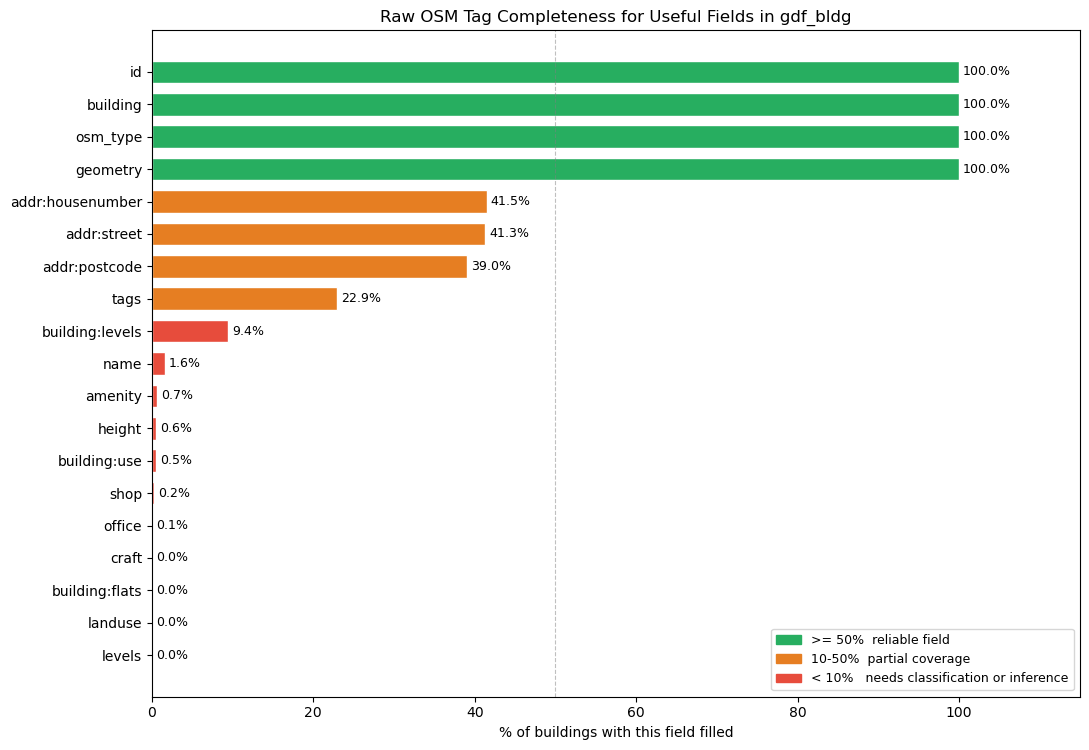

In [ ]:
#  TAG COMPLETENESS BAR CHART FOR USEFUL FIELDS

# - Green bars (>= 50%): these fields are reliable in OSM
# - Orange bars (10-50%): partially available, useful but incomplete
# - Red bars (< 10%): mostly missing — classification pipeline must fill in

plot_df = comp_df[comp_df['pct_filled'] >= 0].sort_values('pct_filled')
colors  = ['#27ae60' if v>=50 else '#e67e22' if v>=10 else '#e74c3c'
           for v in plot_df['pct_filled']]

fig, ax = plt.subplots(figsize=(11, max(5, len(plot_df)*0.40)))
bars    = ax.barh(plot_df['column'], plot_df['pct_filled'],
                  color=colors, edgecolor='white', height=0.7)

for bar, val in zip(bars, plot_df['pct_filled']):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

patches = [
    mpatches.Patch(color='#27ae60', label='>= 50%  reliable field'),
    mpatches.Patch(color='#e67e22', label='10-50%  partial coverage'),
    mpatches.Patch(color='#e74c3c', label='< 10%   needs classification or inference'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.axvline(x=50, color='gray', linestyle='--', lw=0.8, alpha=0.5)
ax.set_xlabel('% of buildings with this field filled')
ax.set_xlim(0, 115)
ax.set_title('Raw OSM Tag Completeness for Useful Fields in gdf_bldg', fontsize=12)
plt.tight_layout()
plt.show()


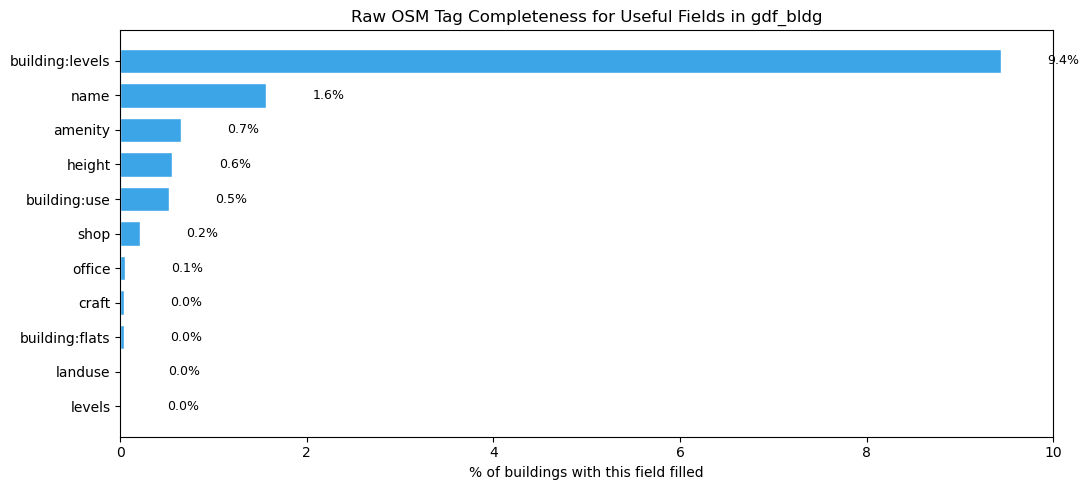

In [ ]:
#  TAG COMPLETENESS BAR CHART FOR USEFUL FIELDS ZOOMED IN ON LOW-COVERAGE FIELDS

plot_df = comp_df[comp_df['pct_filled'] < 10].sort_values('pct_filled')
colors  = ['#27ae60' if v>=50 else '#e67e22' if v>=10 else '#3ca5e7'
           for v in plot_df['pct_filled']]

fig, ax = plt.subplots(figsize=(11, max(5, len(plot_df)*0.40)))
bars    = ax.barh(plot_df['column'], plot_df['pct_filled'],
                  color=colors, edgecolor='white', height=0.7)

for bar, val in zip(bars, plot_df['pct_filled']):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)


ax.axvline(x=10, color='gray', linestyle='--', lw=0.8, alpha=0.5)
ax.set_xlabel('% of buildings with this field filled')
ax.set_xlim(0, 10)
ax.set_title('Raw OSM Tag Completeness for Useful Fields in gdf_bldg', fontsize=12)
plt.tight_layout()
plt.show()


**KEY INSIGHTS**

Severe data sparsity: Most useful tags (amenity, shop, office, building:use) are <1% coverage. building:levels is the only feature with meaningful coverage, but still missing in ~90% of buildings


**Next Steps**
Explore POI data from OSM to see if it's more useful



## Building Type Analysis

In [ ]:
# DEFINE CATEGORY GROUPS 

residential_tags = [
    # Standard residential
    'house', 'residential', 'apartments', 'detached', 'semidetached_house',
    'terrace', 'dormitory', 'bungalow', 'cabin', 'static_caravan',
    # Variants and synonyms found in data
    'dwelling_house', 'detached_house', 'terraced_house', 'terrace_house',
    'semidetached', 'semi_detached', 'semi-detached', 'double_house',
    'row_house', 'flat', 'flats', 'lofts', 'houseboat', 'mobile_home',
    'stilt_house', 'log_cabin', 'chalet', 'villa', 'cottage', 'farmhouse',
    'summer_house', 'summerhouse', 'holiday_home', 'garden_house',
    'allotment_house', 'single_apartment', 'show_house', 'tiny_house',
    'conservatory', 'semi',
    # Typos and case variants from data
    'terraced', 'appartments', 'appartements', 'residental', 'residential',
    'detatched', 'deteched', 'detachedaddr:city=Südheide',
    'semidetatched house', 'RESIDENTIAL', 'residentisl', 'reidentisl',
    'Wohnhaus', 'Freistehendes Mehrfamilienhaus',
    'einzelzimmer,_doppelzimmer_und_appartments',
    # Semicolon combined but primarily residential
    'house;residential', 'residential;house', 'residential;apartments',
    'apartments;residential', 'detached;residential', 'detached;yes',
    'house;yes', 'yes;house', 'residential;yes', 'yes;residential',
    'yes;apartments', 'apartments;yes', 'yes;terrace', 'terrace;yes',
    'terrace;apartments', 'semidetached_house;house', 'residential;garage',
    'roof;semidetached_house', 'roof;residential', 'roof;detached',
    'house;garage', 'garage;house', 'garage;residential', 
    'apartments;garage', 'garage;detached', 'residential;garages',
]

commercial_tags = [
    # Standard commercial
    'commercial', 'retail', 'office', 'supermarket', 'shop',
    'hotel', 'restaurant', 'bank', 'kiosk', 'service',
    # Additional commercial types found in data
    'mall', 'showroom', 'car_wash', 'carwash', 'car_cleaning',
    'car_repair', 'fuel', 'fuel_station', 'gas_station',
    'fast_food', 'pub', 'cafe', 'bakery', 'pharmacy',
    'cinema', 'theatre', 'nightclub', 'casino', 'motel',
    'market_hall', 'shopping_centre', 'shopping_mall',
     'event_center',
    'concert_hall', 'music_hall', 'music_venue',
    'data_center', 'data_centre', 'datacenter',
    'workshop', 'laundry', 'bakehouse', 'store',
    'central_office', 'research_office', 'administration',
    'logistics', 'logistic', 'forwarding_office',
    'post_office', 'ticket_office',
    #commercial use but residential purpose
     'hostel', 'inn', 'guest_house', 'guesthouse', 'skyscraper',
    'boarding_house', 'workers_housing', 'hall_of_residence',
    # Typos
    'Restaurant', 'fast_food', 'foodservice', 'yesoutletstores_direct', 
    'office;yes', 'commercial;yes', 'retail;yes', 'yes;commercial',
    'yes;retail', 'retail;roof', 'retail;commercial;office',
    'commercial;office', 'retail;commercial;office;yes',
    'service;retail', 'retail;office', 'roof;retail', 'roof;commercial',
]

industrial_tags = [
    # Standard industrial
    'industrial', 'warehouse', 'factory', 'manufacture',
    'storage_tank', 'hangar', 'plant',
    # Additional industrial types found in data
    'silo', 'digester', 'slurry_tank', 'bunker_silo',
    'gasometer', 'tank', 'water_tower', 'water_tank',
    'water_storage', 'water_works', 'reservoir', 'cistern',
    'substation', 'sub_station', 'power_substation',
    'power', 'power_station', 'power_house', 'powerhouse',
    'powerstation', 'transformer', 'transformer_tower',
    'transformer_house', 'transformer_kiosk', 'transformer_building',
    'tech_cab', 'tech_cabin', 'electricity',
    'pumping_station', 'sewage_pumping_station',
    'cooling_tower', 'reactor', 'generator',
    'depot', 'storage', 'cold_store', 'coldstore',
    'grain_storage', 'granary',
    'works', 'sawmill', 'brewery', 'slaughterhouse', 'dairy',
    'production_hall', 'fermenter', 'fermentation_plant',
    'bunker', 'signal_box',
    'engine_shed', 'railway_control_centre', 'railway_auxiliary',
    'boat', 'ship', 'boathouse', 'dock', 'wharf', 'pier',
    'container', 'containers', 'control_tower', 'windmill','watermill',
    'office;industrial', 'industrial;office',

    # Typos and variants
    'industrial;yes', 'yes;industrial', 'industrial;warehouse',
    'warehouse;office', 'industrial;commercial',
    'roof;industrial', 'industrial;abandoned', 'abandoned:industrial',
    'îndustrial', 'engine shed', 'farm'
    'power_plant', 'waterworks',  'Umspannwerk', 'heat_station'
    ]

civic_tags = [
    # Education
    'school', 'university', 'college', 'kindergarten', 'kindergarden',
    'Kindergarten', 'dormitory', 'laboratory', 'research',
    'sports_school', 'academy', 'educational', 'education',
    'school_assembly_hall', 'madrasa',
    # Healthcare
    'hospital', 'clinic', 'nursing_home', 'social_facility',
    'hospice', 'mortuary', 'ambulance_station', 'rescue_station',
    'rehabilitation',
    # Government / emergency
    'government', 'civic', 'public', 'townhall', 'government_office',
    'courthouse', 'court_house', 'police', 'police_station',
    'policestation', 'fire_station', 'fire_department', 'firehouse',
    'prison', 'jail', 'barracks', 'embassy', 'guardhouse',
    'military', 'barrack',
    'tax_office', 'post_office', 'public_building',
    'administrative', 'administration', 'city_hall', 'central_office',
    # Religious
    'church', 'chapel', 'cathedral', 'mosque', 'temple', 'synagogue',
    'monastery', 'convent', 'presbytery', 'rectory', 'vicarage',
    'parish', 'parish_hall', 'parish_home', 'wayside_shrine',
    'wayside_chapel', 'kingdom_hall', 'basilica', 'religious',
    'place_of_worship', 'shrine', 'bell_tower', 'campanile',
    'funeral_hall', 'mortuary', 'columbarium', 'mausoleum', 'crypt',
    'cemetery_hall', 'cemetery_chapel', 'ossuary', 'tomb',
    # Culture / community / sport
    'museum', 'library', 'theatre', 'community_centre', 'community_center',
    'social_centre', 'social_club', 'clubhouse', 'club_house',
    'arts_centre', 'exhibition_hall', 'exhibition_centre',
    'concert_hall', 'arena', 'auditorium', 'stadium', 'grandstand',
    'sports_hall', 'sports_centre', 'sports_facility',
    'swimming_pool', 'public_bath', 'sauna', 'skating_rink',
    'bowling_alley', 'gymnasium', 'sport', 'sport_hall', 'sports',
    'riding_school', 'riding_hall', 'observatory', 'castle',
    'hall', 'recreation', 'station', 'gym',
    # Transport / civic
    'parking', 'train_station', 'bus_station', 'ferry_terminal',
    'train_station', 'railway', 'railway_station','transportation', 'bus_station', 'terminal', 'airport',
    'airport_terminal', 'public_transport',
    # Typos and variants
    'chruch', 'curch', 'Kloster', 'kindergarden',
    'civic;retail', 'public;yes', 'yes;public', 'yes;church',
    'school;yes', 'sports_centre;yes', 'yes;school',
    'Rettungswache', 'healthcare', 'castle', 'palace', 'lighthouse', 'manor', 'skyscraper',
    'conference_centre', 'retirement_home', 'childcare',
    'club_home', 'church_hall', 'funeral_home',
]

# Semi-commercial: mixed residential + commercial use
# These get their own category — do not merge into commercial
semi_commercial_tags = [
    'residential;commercial', 'commercial;residential',
    'retail;apartments', 'apartments;retail',
    'retail;residential', 'residential;retail',
    'house;retail', 'residential;shop',
    'mixed_use', 'multi_use', 'mix_used',
    'retail; apartments', 'residential; commercial',
    'commercial;apartments', 'apartments;commercial',
    'civic;retail', 'commercial;civic',
    'commercial;office', 'office;commercial',
    'house;retail', 'apartments;office', 'residential;office',
    'residential; retail', 'residential,commercial',
    'residential, commercial', 'residential, office',
    'retail;residential;commercial',
    'commercial;residential;retail',
    'apartments;hotel',
]

agricultural_tags = [
    'farm', 'farm_auxiliary', 'farm_auxilary', 'barn', 'hay_barn',
    'stable', 'cowshed', 'sty', 'chicken_coop', 'chickenhouse',
    'henhouse', 'poultry_house', 'turkey_coop', 'goat_shed',
    'greenhouse', 'greenhouse_horticulture', 'glasshouse',
    'riding_hall', 'granary', 'grain_storage', 'bunker_silo',
    'slurry_tank', 'livestock', 'livestock_barn', 'animal_keeping',
    'animal_enclosure', 'sheepfold', 'aviary', 'kennel',
    'dog_kennel', 'beehive', 'apiary', 'dovecote',
    'fermentation_plant', 'fermenter', 'agricultural',
    'farmhouse',  # also residential but primarily agricultural context
    'horsewalker', 'horse_walker', 'horse_shelter', 'horseshed',
    'stables',
]

# Filter: not real buildings for energy analysis
filter_tags = [
    'garage', 'garages', 'carport', 'carports', 'shed', 'hut',
    'roof', 'wall', 'bridge', 'container', 'tent', 'scaffold',
    'scaffolding', 'balcony', 'veranda', 'porch', 'pergola',
    'stairs', 'staircase', 'stairwell', 'steps', 'passage',
    'passageway', 'skywalk', 'corridor', 'archway', 'arch',
    'viaduct', 'platform', 'chimney', 'pylon', 'tower',
    'water_tower', 'column', 'pillar', 'cistern', 'fountain',
    'gate', 'gate_pillar', 'gate_tower', 'gatehouse', 'fence',
    'hedge', 'retaining_wall', 'citywall', 'city_wall', 'dam',
    'weir', 'culvert', 'swimming_pool', 'basin',
    'sedimentation_tank', 'cesspit', 'latrine', 'toilet', 'toilets',
    'boiler', 'generator', 'antenna', 'radar', 'satellite_dish',
    'radome', 'bell_tower', 'trolley_bay', 'shelter', 'pavilion',
    'arbour', 'arbor', 'marquee', 'tree_house', 'demountable',
    'sanitary', 'elevator', 'bicycle_parking', 'parking_entrance',
    'collapsed', 'demolished', 'razed', 'destroyed', 'ruins', 'ruin',
    'disused', 'abandoned', 'proposed', 'planned', 'construction',
    'no', 'unknown',
]

# ============================================================
# broad_cat FUNCTION
# Checks all category lists in priority order.
# Semi-commercial checked BEFORE residential and commercial
# to correctly capture mixed-use buildings.
# ============================================================

def broad_cat(tag):
    if pd.isna(tag):
        return 'Null'
    t = str(tag).strip()
    if t == 'yes':
        return 'Yes (unclassified)'
    if t in semi_commercial_tags:
        return 'Semi_Commercial'
    if t in residential_tags:
        return 'Residential'
    if t in commercial_tags:
        return 'Commercial'
    if t in industrial_tags:
        return 'Industrial'
    if t in civic_tags:
        return 'Civic'
    if t in agricultural_tags:
        return 'Agricultural'
    if t in filter_tags:
        return 'Filter'
    return 'Other Tagged'

def tag_color(val):
    cat = broad_cat(val)
    colors = {
        'Residential':       '#3498db',
        'Commercial':        '#e67e22',
        'Industrial':        '#e74c3c',
        'Civic':      '#9b59b6',
        'Semi_Commercial':   '#1abc9c',
        'Agricultural':      '#27ae60',
        'Filter':            '#95a5a6',
        'Yes (unclassified)':'#f39c12',
        'Null':              '#bdc3c7',
        'Other Tagged':      '#ecf0f1',
    }
    return colors.get(cat, '#ecf0f1')

gdf_bldg['broad_cat'] = gdf_bldg['building'].apply(broad_cat)

# ============================================================
# VALIDATION — what is left in Other Tagged?
# These are the genuinely unmappable junk values.
# Should only be: single letters, numbers, URLs, pure German
# text that cannot be classified, keyboard accidents.
# ============================================================

other = gdf_bldg[gdf_bldg['broad_cat'] == 'Other Tagged']
print(f"'Other Tagged' buildings: {len(other):,}")
print()
print("Top values in Other Tagged (check these are genuine junk):")
print(other['building'].value_counts().head(30).to_string())


'Other Tagged' buildings: 12,813

Top values in Other Tagged (check these are genuine junk):
building
outbuilding               9352
annex                      571
annexe                     523
prefabricated              241
cot                        150
historic                   119
utility                     59
ger                         39
yesmoataz_alali             37
reception                   35
garbage_shed                35
addition                    26
gazebo                      25
residential;industrial      23
private                     22
supporting                  17
outline                     17
hos                         17
roundhouse                  17
entrance                    17
extension                   14
installations               14
advertising                 14
cellar                      14
ventilation                 13
waste_disposal              13
patio                       13
storage_room                13
pavillion                   13

In [62]:
# CLASSIFICATION BREAKDOWN 

b = gdf_bldg['building']

# Masks for each category
m_res        = b.isin(residential_tags)
m_com        = b.isin(commercial_tags)
m_ind        = b.isin(industrial_tags)
m_civ        = b.isin(civic_tags)
m_semi       = b.isin(semi_commercial_tags)
m_agr        = b.isin(agricultural_tags)
m_filt       = b.isin(filter_tags)
m_yes        = (b == 'yes')
m_null       = b.isna()

# Other Tagged = has a value, but not in any known list and not yes
all_known    = (residential_tags + commercial_tags + industrial_tags +
                civic_tags + semi_commercial_tags + agricultural_tags +
                filter_tags + ['yes'])
m_other_tag  = b.notna() & ~b.isin(all_known)
m_unclassed  = m_yes | m_null

TAGGED_COUNT       = (~m_yes & ~m_null).sum()
JUST_YES_COUNT     = m_yes.sum()
NULL_COUNT         = m_null.sum()
UNCLASSIFIED_COUNT = m_unclassed.sum()

print('BUILDING TYPE BREAKDOWN')
print('=' * 68)
cats = [
    ('Residential (tagged)',               m_res),
    ('Commercial (tagged)',                m_com),
    ('Industrial (tagged)',                m_ind),
    ('Civic (tagged)',            m_civ),
    ('Semi-Commercial (tagged)',           m_semi),
    ('Agricultural (tagged)',              m_agr),
    ('Filter structures (garage/shed)',    m_filt),
    ('Other tagged (rare/junk values)',    m_other_tag),
    ('Tagged only as yes -> no type',      m_yes),
    ('No building tag at all (null)',      m_null),
]
for label, mask in cats:
    cnt = mask.sum()
    print(f'  {label:<48} {cnt:>10,}  ({cnt/TOTAL*100:5.1f}%)')

print()
print(f'  {"TOTAL NEEDING CLASSIFICATION (yes + null)":<48}'
      f' {UNCLASSIFIED_COUNT:>10,}  ({UNCLASSIFIED_COUNT/TOTAL*100:5.1f}%)')


BUILDING TYPE BREAKDOWN
  Residential (tagged)                              7,870,696  ( 20.3%)
  Commercial (tagged)                                 380,109  (  1.0%)
  Industrial (tagged)                                 265,002  (  0.7%)
  Civic (tagged)                                      244,358  (  0.6%)
  Semi-Commercial (tagged)                                 94  (  0.0%)
  Agricultural (tagged)                               354,896  (  0.9%)
  Filter structures (garage/shed)                   3,878,994  ( 10.0%)
  Other tagged (rare/junk values)                      12,813  (  0.0%)
  Tagged only as yes -> no type                    25,845,306  ( 66.6%)
  No building tag at all (null)                             0  (  0.0%)

  TOTAL NEEDING CLASSIFICATION (yes + null)        25,845,306  ( 66.6%)


**FINDINGS** 

67% of buildings have no specific type.

Under-tagged non-residential:
-  Industrial  :    265,002  (0.68%)
- Commercial  :    380,173  (0.98%)
- Civic       :    244,358  (0.63%)

Filter candidates (not buildings): Garages/sheds (3,878,994) (9.99%)

Semi-commercial confirmed in tags: 94
  

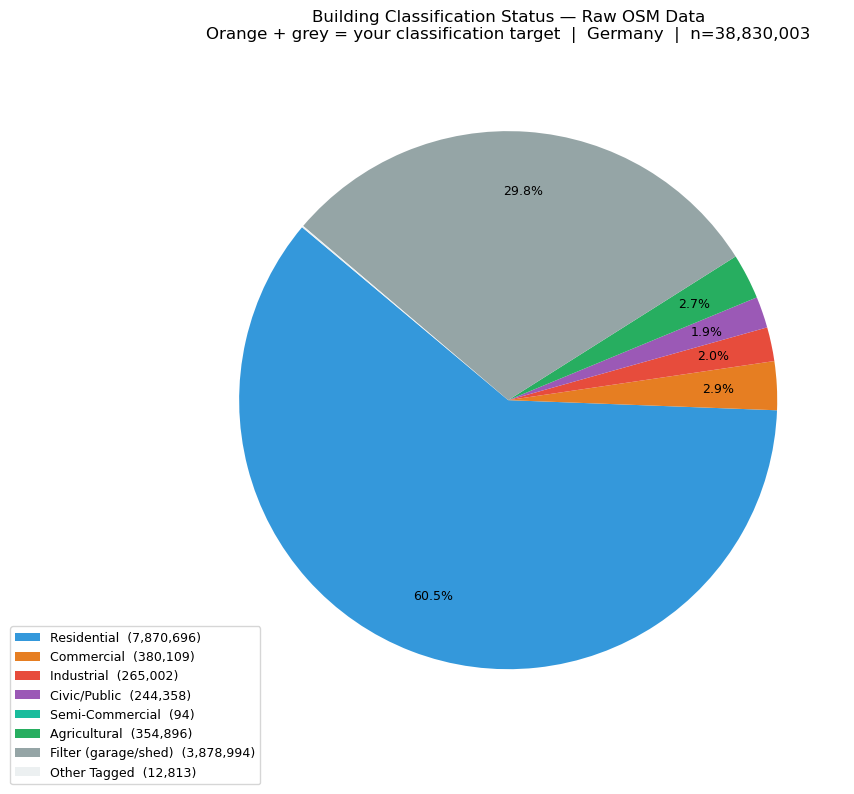

In [ ]:

import matplotlib.patches as mpatches

labels_p = [
    'Residential', 'Commercial', 'Industrial', 'Civic/Public',
    'Semi-Commercial', 'Agricultural', 'Filter (garage/shed)',
    'Other Tagged'
]
sizes_p = [
    m_res.sum(), m_com.sum(), m_ind.sum(), m_civ.sum(),
    m_semi.sum(), m_agr.sum(), m_filt.sum(),
    m_other_tag.sum(), m_yes.sum(), m_null.sum()
]
colors_p = [
    '#3498db',  # Residential
    '#e67e22',  # Commercial
    '#e74c3c',  # Industrial
    '#9b59b6',  # Civic
    '#1abc9c',  # Semi-Commercial
    '#27ae60',  # Agricultural
    '#95a5a6',  # Filter
    '#ecf0f1',  # Other Tagged
    '#f39c12',  # yes
    '#bdc3c7',  # Null
]

# Filter out zero-count categories
filt_data = [(l, s, c) for l, s, c in zip(labels_p, sizes_p, colors_p) if s > 0]
lf, sf, cf = zip(*filt_data)

fig, ax = plt.subplots(figsize=(12, 8))
wedges, _, autotexts = ax.pie(
    sf, labels=None, colors=cf,
    autopct=lambda p: f'{p:.1f}%' if p > 0.5 else '',
    startangle=140, pctdistance=0.78
)
for t in autotexts:
    t.set_fontsize(9)

ax.legend(
    wedges,
    [f'{l}  ({s:,})' for l, s in zip(lf, sf)],
    loc='lower left',
    bbox_to_anchor=(-0.25, -0.08),
    fontsize=9
)
ax.set_title(
    'Building Classification Status — Raw OSM Data\n'
    'Orange + grey = your classification target  |  '
    f'Germany  |  n={TOTAL:,}',
    pad=18
)
plt.tight_layout()
plt.show()


/tmp/ipykernel_110383/783048682.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sizes_sorted, y=labels_sorted, palette="viridis")


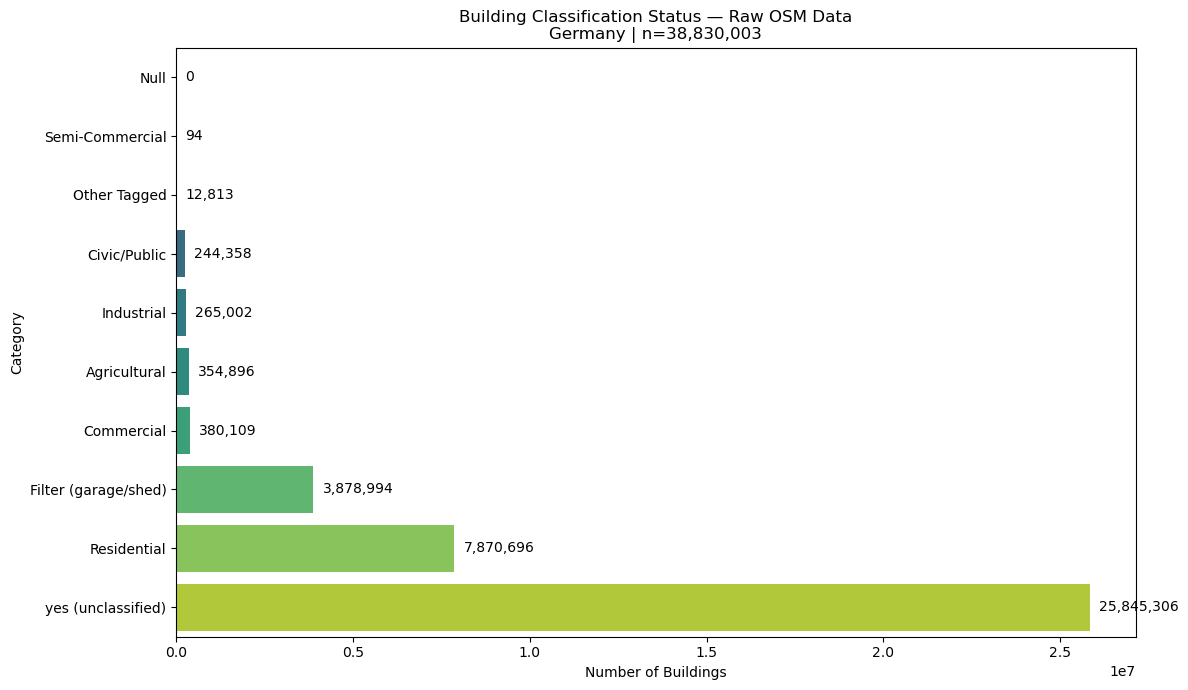

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

labels = [
    'Residential', 'Commercial', 'Industrial', 'Civic/Public',
    'Semi-Commercial', 'Agricultural', 'Filter (garage/shed)',
    'Other Tagged', 'yes (unclassified)', 'Null'
]

sizes = [
    m_res.sum(), m_com.sum(), m_ind.sum(), m_civ.sum(),
    m_semi.sum(), m_agr.sum(), m_filt.sum(),
    m_other_tag.sum(), m_yes.sum(), m_null.sum()
]

# Sort by size
labels_sorted, sizes_sorted = zip(*sorted(zip(labels, sizes), key=lambda x: x[1]))

plt.figure(figsize=(12, 7))
sns.barplot(x=sizes_sorted, y=labels_sorted, palette="viridis")

plt.xlabel("Number of Buildings")
plt.ylabel("Category")
plt.title(f"Building Classification Status — Raw OSM Data\nGermany | n={TOTAL:,}")

# Add labels
for i, v in enumerate(sizes_sorted):
    plt.text(v + max(sizes_sorted)*0.01, i, f"{v:,}", va='center')

plt.tight_layout()
plt.show()


/tmp/ipykernel_110383/3766395287.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sizes_sorted, y=labels_sorted, palette="Blues")


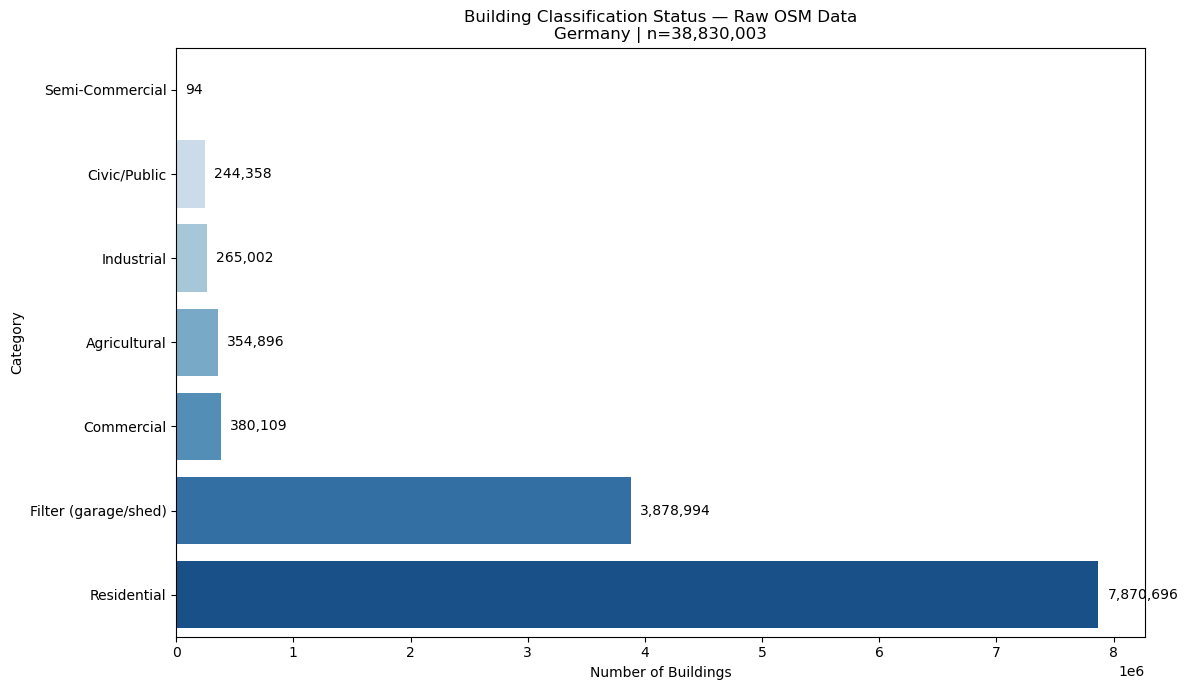

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

labels = [
    'Residential', 'Commercial', 'Industrial', 'Civic/Public',
    'Semi-Commercial', 'Agricultural', 'Filter (garage/shed)',
    'Other Tagged'
]

sizes = [
    m_res.sum(), m_com.sum(), m_ind.sum(), m_civ.sum(),
    m_semi.sum(), m_agr.sum(), m_filt.sum()
]

# Sort by size
labels_sorted, sizes_sorted = zip(*sorted(zip(labels, sizes), key=lambda x: x[1]))

plt.figure(figsize=(12, 7))
sns.barplot(x=sizes_sorted, y=labels_sorted, palette="Blues")

plt.xlabel("Number of Buildings")
plt.ylabel("Category")
plt.title(f"Building Classification Status — Raw OSM Data\nGermany | n={TOTAL:,}")

# Add labels
for i, v in enumerate(sizes_sorted):
    plt.text(v + max(sizes_sorted)*0.01, i, f"{v:,}", va='center')

plt.tight_layout()
plt.show()


/tmp/ipykernel_110383/1889882023.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=labels, palette="Blues")


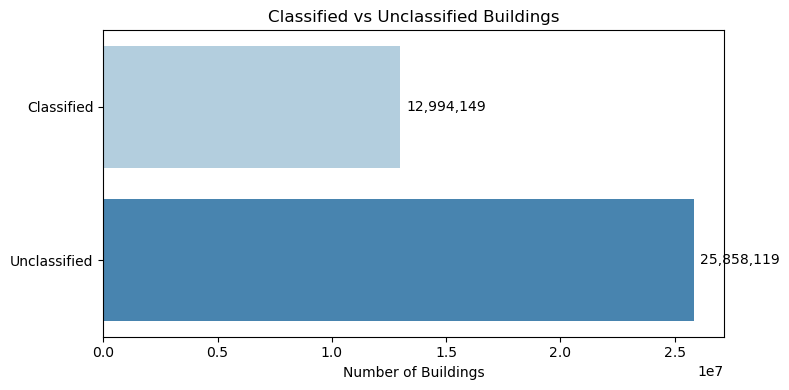

In [66]:

classified = (
    m_res.sum() + m_com.sum() + m_ind.sum() + m_civ.sum() +
    m_semi.sum() + m_agr.sum() + m_filt.sum() 
)

unclassified = m_yes.sum() + + m_other_tag.sum()

labels = ["Classified", "Unclassified"]
values = [classified, unclassified]

plt.figure(figsize=(8, 4))
sns.barplot(x=values, y=labels, palette="Blues")

plt.xlabel("Number of Buildings")
plt.title("Classified vs Unclassified Buildings")

# Add labels
for i, v in enumerate(values):
    plt.text(v + max(values)*0.01, i, f"{v:,}", va='center')

plt.tight_layout()
plt.show()




/tmp/ipykernel_110383/386672852.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=labels, palette="crest")


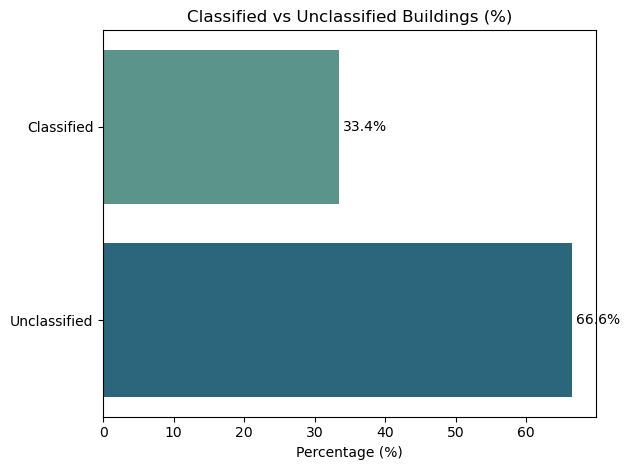

In [67]:
total = classified + unclassified
pct_class = classified / total * 100
pct_unclass = unclassified / total * 100

labels = ["Classified", "Unclassified"]
values = [pct_class, pct_unclass]

sns.barplot(x=values, y=labels, palette="crest")
plt.xlabel("Percentage (%)")
plt.title("Classified vs Unclassified Buildings (%)")

for i, v in enumerate(values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()


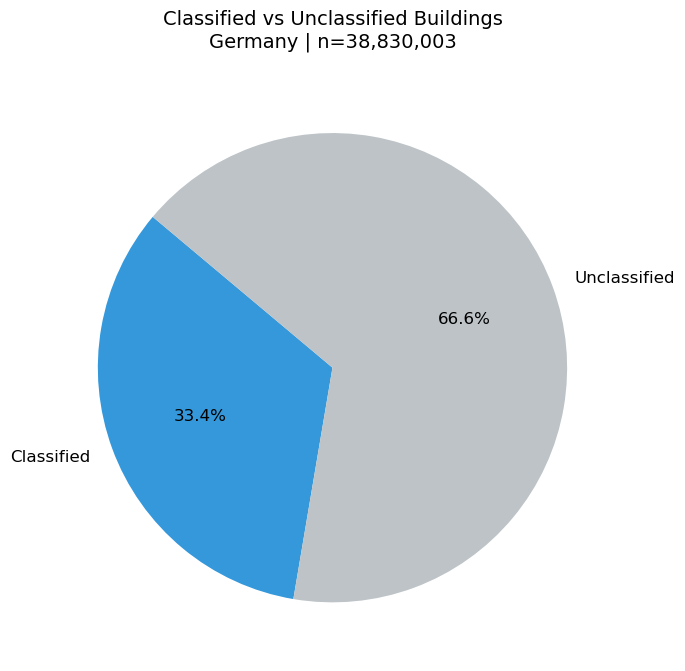

In [ ]:

# Compute totals
classified = (
    m_res.sum() + m_com.sum() + m_ind.sum() + m_civ.sum() +
    m_semi.sum() + m_agr.sum() + m_filt.sum() 
)

unclassified = m_yes.sum() + m_null.sum() + m_other_tag.sum()

labels = ["Classified", "Unclassified"]
sizes = [classified, unclassified]
colors = ["#3498db", "#bdc3c7"]  # blue + grey

fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    textprops={"fontsize": 12}
)

ax.set_title(
    f"Classified vs Unclassified Buildings\nGermany | n={TOTAL:,}",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()


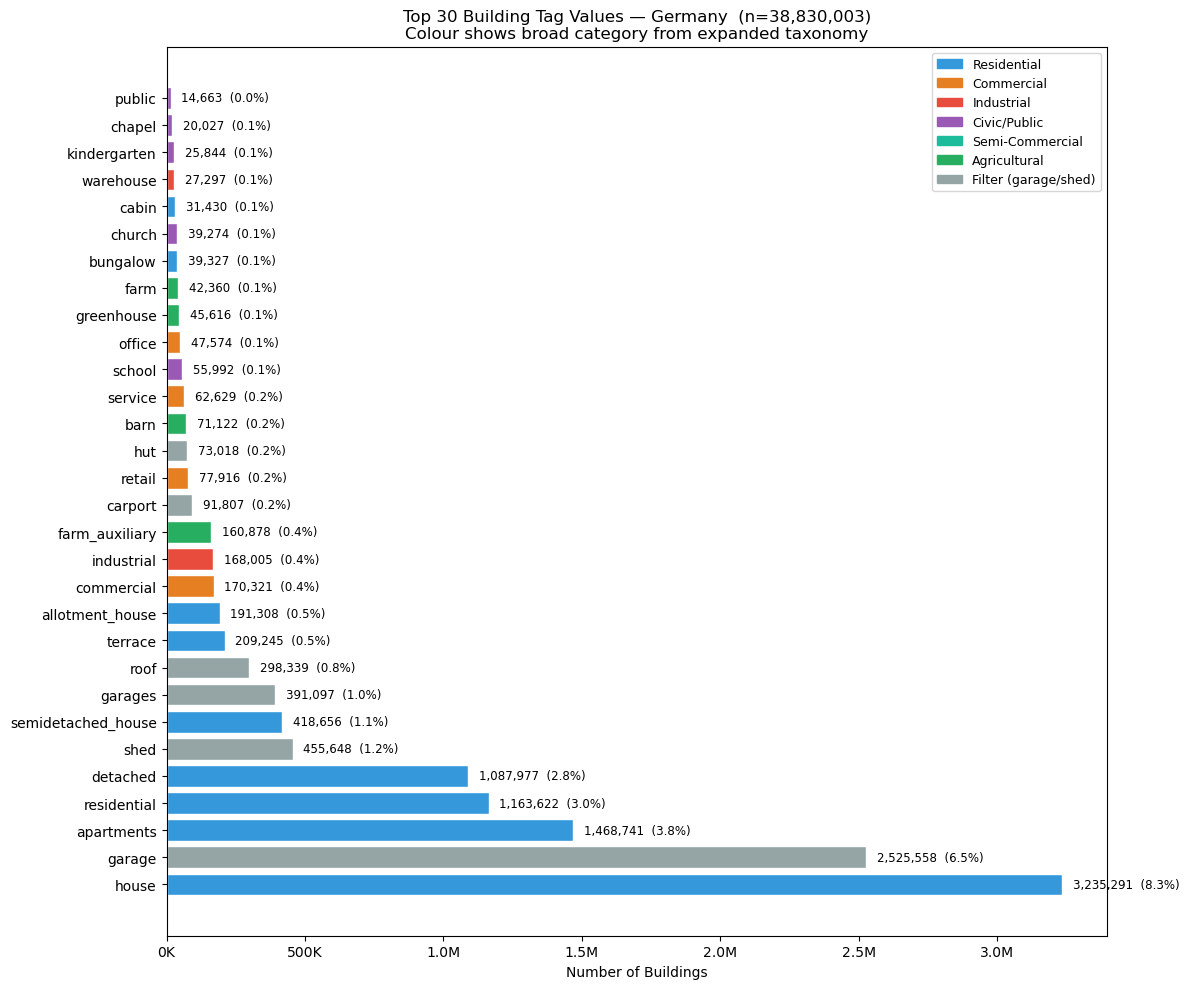

In [ ]:

def tag_color(val):
    """Return color for a building tag value based on broad category."""
    cat = broad_cat(val)
    colors = {
        'Residential':        '#3498db',
        'Commercial':         '#e67e22',
        'Industrial':         '#e74c3c',
        'Civic':       '#9b59b6',
        'Semi_Commercial':    '#1abc9c',
        'Agricultural':       '#27ae60',
        'Filter':             '#95a5a6',
        'Other Tagged':       '#ecf0f1',
    }
    return colors.get(cat, '#ecf0f1')

# Remove "yes" from the building tag list
filtered = gdf_bldg['building'].replace("yes", pd.NA).dropna()

# Now take the top 30 without "yes"
top30 = filtered.value_counts().head(30)


fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(
    [str(v) if pd.notna(v) else 'null' for v in top30.index],
    top30.values,
    color=[tag_color(v) for v in top30.index],
    edgecolor='white'
)
for bar, val in zip(bars, top30.values):
    ax.text(
        bar.get_width() + TOTAL * 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}  ({val/TOTAL*100:.1f}%)',
        va='center', fontsize=8.5
    )

# Updated legend to match new taxonomy
patches = [
    mpatches.Patch(color='#3498db', label='Residential'),
    mpatches.Patch(color='#e67e22', label='Commercial'),
    mpatches.Patch(color='#e74c3c', label='Industrial'),
    mpatches.Patch(color='#9b59b6', label='Civic/Public'),
    mpatches.Patch(color='#1abc9c', label='Semi-Commercial'),
    mpatches.Patch(color='#27ae60', label='Agricultural'),
    mpatches.Patch(color='#95a5a6', label='Filter (garage/shed)'),
]
ax.legend(handles=patches, loc='upper right', fontsize=9)
ax.set_xlabel('Number of Buildings')
ax.set_title(
    f'Top 30 Building Tag Values — Germany  (n={TOTAL:,})\n'
    'Colour shows broad category from expanded taxonomy'
)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'
    )
)
plt.tight_layout()
plt.show()


## GEOMETRY ANALYSIS

In [ ]:
#  GEOMETRY TYPES AND VALIDITY

# - Invalid geometries = self-intersecting polygons (a figure-8 shape).
#   These cause errors in spatial operations. Fix with .buffer(0).

print('GEOMETRY TYPE DISTRIBUTION:')
for gt, cnt in gdf_bldg.geometry.geom_type.value_counts(dropna=False).items():
    flag = '' if str(gt) in ['Polygon','MultiPolygon'] else '  <- problematic'
    print(f'  {str(gt):<22} {cnt:>10,}  ({cnt/TOTAL*100:.2f}%){flag}')

null_g    = gdf_bldg.geometry.isna().sum()
invalid_g = (~gdf_bldg.geometry.is_valid).sum()
empty_g   = gdf_bldg.geometry.is_empty.sum()
print()
print('GEOMETRY VALIDITY:')
print(f'  Null geometries           : {null_g:>10,}')
print(f'  Invalid (self-intersect.) : {invalid_g:>10,}  <- fix with .buffer(0) in pre-processing')
print(f'  Empty geometries          : {empty_g:>10,}')

if gdf_bldg.crs and gdf_bldg.crs.to_epsg() != 4326:
    buildings = gdf_bldg.to_crs(epsg=4326)
bn = gdf_bldg.total_bounds
print()
print('BOUNDING BOX (should cover Germany):')
print(f'  West  : {bn[0]:.4f}  (expected ~5.9)')
print(f'  East  : {bn[2]:.4f}  (expected ~15.0)')
print(f'  South : {bn[1]:.4f}  (expected ~47.3)')
print(f'  North : {bn[3]:.4f}  (expected ~55.1)')

if bn[0] < 4 or bn[2] > 16 or bn[1] < 46 or bn[3] > 56:
    print('WARNING: Some coordinates outside expected Germany range.')
    print('This may indicate CRS is wrong or data contains non-Germany gdf_bldg.')
else:
    print('OK: Coordinates within expected Germany range.')

GEOMETRY TYPE DISTRIBUTION:
  Polygon                38,828,150  (100.00%)
  MultiPolygon                1,823  (0.00%)
  MultiLineString                20  (0.00%)  <- problematic
  LineString                     10  (0.00%)  <- problematic

GEOMETRY VALIDITY:
  Null geometries           :          0
  Invalid (self-intersect.) :     50,575  <- fix with .buffer(0) in pre-processing
  Empty geometries          :          0

BOUNDING BOX (should cover Germany):
  West  : 5.8655  (expected ~5.9)
  East  : 15.0505  (expected ~15.0)
  South : 47.2697  (expected ~47.3)
  North : 55.0526  (expected ~55.1)
OK: Coordinates within expected Germany range.


## AREA, PERIMETER AND COMPACTNESS
All metric calculations use EPSG:3035 (ETRS89/LAEA Europe).

**CRS NOTE:**

We temporarily reproject to EPSG:3035 for all metric calculations.

EPSG:3035 = ETRS89/LAEA Europe = equal-area projection for Europe. 'Equal-area' means areas are correct everywhere across Europe.

We then add the results as columns and stay in 4326 for the master df.


In [ ]:
#  CALCULATE AREA, PERIMETER, COMPACTNESS


print('Projecting to EPSG:3035 for metric calculations...')
print('(ETRS89/LAEA Europe — equal-area projection, metres)')
bproj = gdf_bldg.to_crs(epsg=3035)

print('Calculating area (m2)...')
gdf_bldg['area_sqm'] = bproj.geometry.area

print('Calculating perimeter (m)...')
gdf_bldg['perimeter_m'] = bproj.geometry.length

print('Calculating compactness...')
# Clip to 0-1 to handle any tiny floating point errors
gdf_bldg['compactness'] = (
    4 * np.pi * gdf_bldg['area_sqm'] / (gdf_bldg['perimeter_m'] ** 2)
).clip(0, 1)

del bproj  # free memory

print()
print('AREA STATISTICS (square metres):')
print(gdf_bldg['area_sqm'].describe().round(2).to_string())
print()
print('PERIMETER STATISTICS (metres):')
print(gdf_bldg['perimeter_m'].describe().round(2).to_string())
print()
print('COMPACTNESS STATISTICS (0=irregular, 1=circle):')
print(gdf_bldg['compactness'].describe().round(4).to_string())

Projecting to EPSG:3035 for metric calculations...
(ETRS89/LAEA Europe — equal-area projection, metres)
Calculating area (m2)...
Calculating perimeter (m)...
Calculating compactness...

AREA STATISTICS (square metres):
count    38830003.00
mean          163.63
std          4319.73
min          -794.26
25%            44.96
50%            95.70
75%           162.21
max      25263416.54

PERIMETER STATISTICS (metres):
count    38830003.00
mean           46.97
std           224.35
min             0.28
25%            28.04
50%            40.76
75%            54.16
max       1242133.26

COMPACTNESS STATISTICS (0=irregular, 1=circle):
count    3.883000e+07
mean     7.001000e-01
std      1.003000e-01
min      0.000000e+00
25%      6.607000e-01
50%      7.331000e-01
75%      7.742000e-01
max      9.988000e-01


In [ ]:
# SIZE CATEGORY BREAKDOWN


size_bins = [
    ('< 10 m2      garages/sheds/errors',   gdf_bldg['area_sqm'] < 10),
    ('10-50 m2     very small',             (gdf_bldg['area_sqm']>=10)  &(gdf_bldg['area_sqm']<50)),
    ('50-150 m2    small residential',      (gdf_bldg['area_sqm']>=50)  &(gdf_bldg['area_sqm']<150)),
    ('150-500 m2   medium res/commercial',  (gdf_bldg['area_sqm']>=150) &(gdf_bldg['area_sqm']<500)),
    ('500-2000 m2  large commercial',       (gdf_bldg['area_sqm']>=500) &(gdf_bldg['area_sqm']<2000)),
    ('2000-10k m2  very large/industrial',  (gdf_bldg['area_sqm']>=2000)&(gdf_bldg['area_sqm']<10000)),
    ('> 10,000 m2  mega/industrial',         gdf_bldg['area_sqm'] >= 10000),
]
print('BUILDING SIZE CATEGORIES (in m2 footprint area):')
print('-' * 70)
for label, mask in size_bins:
    cnt = mask.sum()
    print(f'  {label:<50} {cnt:>8,}  ({cnt/TOTAL*100:4.1f}%)')
print('-' * 70)
TINY_COUNT = (gdf_bldg['area_sqm'] < 10).sum()
print(f'\n  -> {TINY_COUNT:,} buildings ({TINY_COUNT/TOTAL*100:.1f}%) will be filtered in pre-processing')

BUILDING SIZE CATEGORIES (in m2 footprint area):
----------------------------------------------------------------------
  < 10 m2      garages/sheds/errors                   712,696  ( 1.8%)
  10-50 m2     very small                            9,946,370  (25.6%)
  50-150 m2    small residential                     17,096,731  (44.0%)
  150-500 m2   medium res/commercial                 9,510,231  (24.5%)
  500-2000 m2  large commercial                      1,365,162  ( 3.5%)
  2000-10k m2  very large/industrial                  182,431  ( 0.5%)
  > 10,000 m2  mega/industrial                         16,382  ( 0.0%)
----------------------------------------------------------------------

  -> 712,696 buildings (1.8%) will be filtered in pre-processing


## Charts

In [ ]:
from pathlib import Path


# Paths

# Reload the untouched building layer
gdf_bldg_raw = gdf_bldg.copy()
TOTAL = len(gdf_bldg_raw)

# Restrained thesis palette
COLORS = {
    "blue": "#35688F",
    "light_blue": "#9DB9CE",
    "orange": "#C47A3C",
    "green": "#5D8467",
    "red": "#A6534E",
    "dark": "#30343B",
    "gray": "#A7ADB4",
    "light_gray": "#E7EAED",
    "very_light_gray": "#F5F6F7",
    "white": "#FFFFFF",
}

# Consistent thesis-facing style
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.edgecolor": COLORS["gray"],
    "axes.linewidth": 0.8,
    "axes.titleweight": "semibold",
})

NULL_STRINGS = {"", "nan", "none", "null", "nat", "{}", "[]"}

def normalized_text(series):
    """Return lowercase trimmed text with fake null strings converted to missing values."""
    text = series.astype("string").str.strip().str.lower()
    return text.mask(text.isin(NULL_STRINGS))

def nonempty_mask(series):
    """Identify real non-empty values without modifying the raw dataset."""
    mask = series.notna().copy()
    if mask.any():
        text = series.loc[mask].astype(str).str.strip().str.lower()
        mask.loc[mask] = ~text.isin(NULL_STRINGS)
    return mask

def format_count(value):
    """Format large counts for figure labels."""
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    if value >= 1_000:
        return f"{value / 1_000:.1f}K"
    return f"{value:,.0f}"

def clean_axes(ax, grid_axis="x"):
    """Apply restrained formatting to an axis."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis=grid_axis, color=COLORS["light_gray"], linewidth=0.8)
    ax.set_axisbelow(True)


print(f"Raw buildings: {TOTAL:,}")
print(f"CRS: {gdf_bldg_raw.crs}")

Raw buildings: 38,830,003
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "d

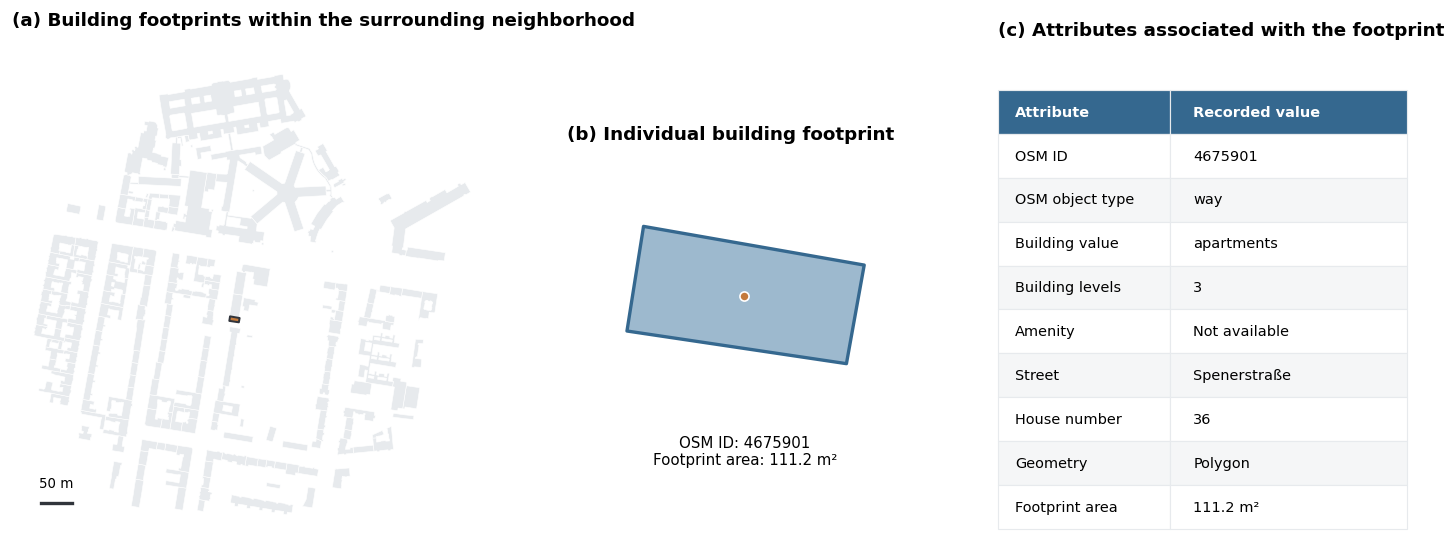

In [ ]:
# OSM BUILDING FOOTPRINT AND ASSOCIATED ATTRIBUTES

SAMPLE_OSM_ID = None  
SEARCH_RADIUS_M = 300

building_norm = normalized_text(gdf_bldg_raw["building"])
polygon_mask = gdf_bldg_raw.geometry.geom_type.isin(["Polygon", "MultiPolygon"])

if SAMPLE_OSM_ID is not None:
    sample_mask = gdf_bldg_raw["id"].astype(str).eq(str(SAMPLE_OSM_ID))
    if not sample_mask.any():
        raise ValueError(f"OSM ID {SAMPLE_OSM_ID} was not found.")
    sample_idx = gdf_bldg_raw.index[sample_mask][0]
else:
    # Prefer an apartment building with levels and address information
    sample_mask = building_norm.eq("apartments") & polygon_mask & gdf_bldg_raw.geometry.notna()

    if "building:levels" in gdf_bldg_raw.columns:
        sample_mask &= nonempty_mask(gdf_bldg_raw["building:levels"])

    address_cols = [c for c in ["addr:housenumber", "addr:street"] if c in gdf_bldg_raw.columns]
    if address_cols:
        address_mask = pd.Series(False, index=gdf_bldg_raw.index)
        for col in address_cols:
            address_mask |= nonempty_mask(gdf_bldg_raw[col])
        sample_mask &= address_mask

    if not sample_mask.any():
        sample_mask = building_norm.eq("apartments") & polygon_mask & gdf_bldg_raw.geometry.notna()

    if not sample_mask.any():
        sample_mask = polygon_mask & gdf_bldg_raw.geometry.notna()

    sample_idx = gdf_bldg_raw.index[sample_mask][0]

sample = gdf_bldg_raw.loc[[sample_idx]].copy()

# Project the selected building and create a metric search area
sample_proj = sample.to_crs(3035)
sample_search_area = sample_proj.geometry.iloc[0].centroid.buffer(SEARCH_RADIUS_M)

# Convert the search area back to the original CRS for spatial-index querying
search_geom_raw = gpd.GeoSeries([sample_search_area], crs=3035).to_crs(gdf_bldg_raw.crs).iloc[0]
neighbor_positions = gdf_bldg_raw.sindex.query(search_geom_raw, predicate="intersects")
neighborhood = gdf_bldg_raw.iloc[neighbor_positions].copy()
neighborhood = neighborhood[neighborhood.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].to_crs(3035)

# Find the selected building inside the projected neighborhood
sample_id = str(sample["id"].iloc[0])
selected_proj = neighborhood[neighborhood["id"].astype(str).eq(sample_id)].copy()

# Fallback where an ID collision exists
if selected_proj.empty:
    selected_proj = sample_proj.copy()

sample_row = sample.iloc[0]
sample_area = sample_proj.geometry.area.iloc[0]
sample_centroid = sample_proj.geometry.centroid.iloc[0]

def display_value(column, default="Not available"):
    if column not in sample_row.index or pd.isna(sample_row[column]):
        return default
    value = str(sample_row[column]).strip()
    if value.lower() in NULL_STRINGS:
        return default
    return value if len(value) <= 40 else value[:37] + "..."

attribute_rows = [
    ("OSM ID", display_value("id")),
    ("OSM object type", display_value("osm_type")),
    ("Building value", display_value("building")),
    ("Building levels", display_value("building:levels")),
    ("Amenity", display_value("amenity")),
    ("Street", display_value("addr:street")),
    ("House number", display_value("addr:housenumber")),
    ("Geometry", sample.geometry.geom_type.iloc[0]),
    ("Footprint area", f"{sample_area:,.1f} m²"),
]

fig = plt.figure(figsize=(15, 5.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.35, 1.0, 1.15], wspace=0.18)

# Panel A: neighborhood context
ax1 = fig.add_subplot(gs[0, 0])
neighborhood.plot(ax=ax1, facecolor=COLORS["light_gray"], edgecolor=COLORS["white"], linewidth=0.35)
selected_proj.plot(ax=ax1, facecolor=COLORS["orange"], edgecolor=COLORS["dark"], linewidth=1.2)
ax1.set_title("(a) Building footprints within the surrounding neighborhood", loc="left")
ax1.set_aspect("equal")
ax1.axis("off")

# Add a simple scale bar
xmin, xmax = ax1.get_xlim()
ymin, ymax = ax1.get_ylim()
scale_length = 50
scale_x = xmin + (xmax - xmin) * 0.06
scale_y = ymin + (ymax - ymin) * 0.07
ax1.plot([scale_x, scale_x + scale_length], [scale_y, scale_y], color=COLORS["dark"], linewidth=2)
ax1.text(scale_x + scale_length / 2, scale_y + (ymax - ymin) * 0.025, "50 m", ha="center", va="bottom", fontsize=8)

# Panel B: selected footprint
ax2 = fig.add_subplot(gs[0, 1])
selected_proj.plot(ax=ax2, facecolor=COLORS["light_blue"], edgecolor=COLORS["blue"], linewidth=2)
ax2.scatter(sample_centroid.x, sample_centroid.y, s=30, color=COLORS["orange"], edgecolor=COLORS["white"], zorder=3)

sxmin, symin, sxmax, symax = selected_proj.total_bounds
pad = max(sxmax - sxmin, symax - symin) * 0.25
ax2.set_xlim(sxmin - pad, sxmax + pad)
ax2.set_ylim(symin - pad, symax + pad)
ax2.set_title("(b) Individual building footprint", loc="left")
ax2.text(
    0.5, -0.05,
    f"OSM ID: {sample_id}\nFootprint area: {sample_area:,.1f} m²",
    transform=ax2.transAxes, ha="center", va="top", fontsize=9
)
ax2.set_aspect("equal")
ax2.axis("off")

# Panel C: attribute record
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_title("(c) Attributes associated with the footprint", loc="left")
ax3.axis("off")

table = ax3.table(
    cellText=attribute_rows,
    colLabels=["Attribute", "Recorded value"],
    cellLoc="left",
    colLoc="left",
    colWidths=[0.42, 0.58],
    bbox=[0, 0.03, 1, 0.88],
)

table.auto_set_font_size(False)
table.set_fontsize(8.7)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor(COLORS["light_gray"])
    cell.set_linewidth(0.7)
    if row == 0:
        cell.set_facecolor(COLORS["blue"])
        cell.set_text_props(color=COLORS["white"], weight="semibold")
    elif row % 2 == 0:
        cell.set_facecolor(COLORS["very_light_gray"])
    else:
        cell.set_facecolor(COLORS["white"])

plt.show()

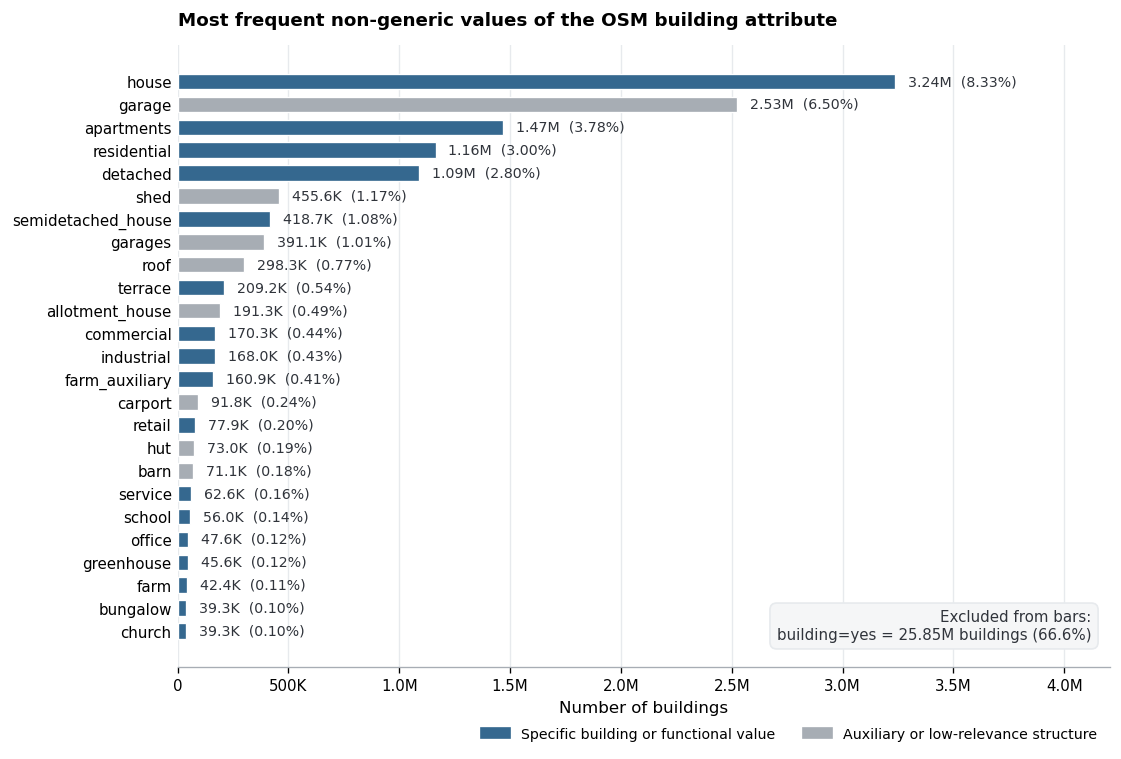

In [ ]:
#  MOST FREQUENT SPECIFIC BUILDING VALUES

TOP_N = 25

building_norm = normalized_text(gdf_bldg_raw["building"])
yes_count = int(building_norm.eq("yes").sum())
yes_pct = yes_count / TOTAL * 100

specific_values = building_norm[
    building_norm.notna() & ~building_norm.eq("yes")
]

top_values = specific_values.value_counts().head(TOP_N).sort_values(ascending=True)

# Highlight common auxiliary or low-relevance structures
auxiliary_values = {
    "garage", "garages", "shed", "roof", "carport",
    "shelter", "hut", "cabin", "allotment_house", "barn"
}

bar_colors = [
    COLORS["gray"] if value in auxiliary_values else COLORS["blue"]
    for value in top_values.index
]

fig, ax = plt.subplots(figsize=(10.5, 7))

bars = ax.barh(
    top_values.index,
    top_values.values,
    color=bar_colors,
    edgecolor=COLORS["white"],
    linewidth=0.8,
    height=0.68,
)

label_offset = top_values.max() * 0.018

for bar, value in zip(bars, top_values.values):
    pct = value / TOTAL * 100
    ax.text(
        bar.get_width() + label_offset,
        bar.get_y() + bar.get_height() / 2,
        f"{format_count(value)}  ({pct:.2f}%)",
        va="center",
        fontsize=8.5,
        color=COLORS["dark"],
    )

ax.set_xlabel("Number of buildings")
ax.set_ylabel("")
ax.set_title(
    f"Most frequent non-generic values of the OSM building attribute",
    loc="left",
    pad=12,
)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f"{x / 1_000_000:.1f}M"
        if x >= 1_000_000
        else f"{x / 1_000:.0f}K"
        if x >= 1_000
        else f"{x:,.0f}"
    )
)

clean_axes(ax)

ax.set_xlim(0, top_values.max() * 1.30)

# Separate callout for the dominant generic value
ax.text(
    0.98,
    0.04,
    f"Excluded from bars:\n"
    f"building=yes = {format_count(yes_count)} buildings ({yes_pct:.1f}%)",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color=COLORS["dark"],
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": COLORS["very_light_gray"],
        "edgecolor": COLORS["light_gray"],
    },
)

legend_handles = [
    mpatches.Patch(color=COLORS["blue"], label="Specific building or functional value"),
    mpatches.Patch(color=COLORS["gray"], label="Auxiliary or low-relevance structure"),
]

ax.legend(
    handles=legend_handles,
    loc="lower right",
    bbox_to_anchor=(1, -0.14),
    frameon=False,
    ncol=2,
    fontsize=8.5,
)

fig.subplots_adjust(left=0.22, right=0.96, top=0.89, bottom=0.15)

plt.show()

In [ ]:

import shapely
from shapely.geometry import box
from pyproj import Transformer
from matplotlib.colors import LinearSegmentedColormap, Normalize

# Use the untouched extracted building layer
gdf_plot = gdf_bldg

COLORS = {
    "specific": "#35688F",
    "generic": "#B8BDC4",
    "address": "#4F7895",
    "physical": "#B27645",
    "functional": "#6E8868",
    "additional": "#7C6F91",
    "dark": "#30343B",
    "light": "#E7EAED",
    "background": "#F7F8F9",
    "white": "#FFFFFF",
}

NULL_STRINGS = {"", "nan", "none", "null", "nat", "{}", "[]"}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.edgecolor": COLORS["generic"],
    "axes.linewidth": 0.8,
})

def normalized_text(series):
    text = series.astype("string").str.strip().str.lower()
    return text.mask(text.isin(NULL_STRINGS))

def nonempty_mask(series):
    mask = series.notna().copy()
    if mask.any():
        text = series.loc[mask].astype(str).str.strip().str.lower()
        mask.loc[mask] = ~text.isin(NULL_STRINGS)
    return mask

def format_count(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f} million"
    if value >= 1_000:
        return f"{value / 1_000:.1f} thousand"
    return f"{value:,.0f}"

def clean_axes(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.grid(axis=grid_axis, color=COLORS["light"], linewidth=0.8)
    ax.set_axisbelow(True)


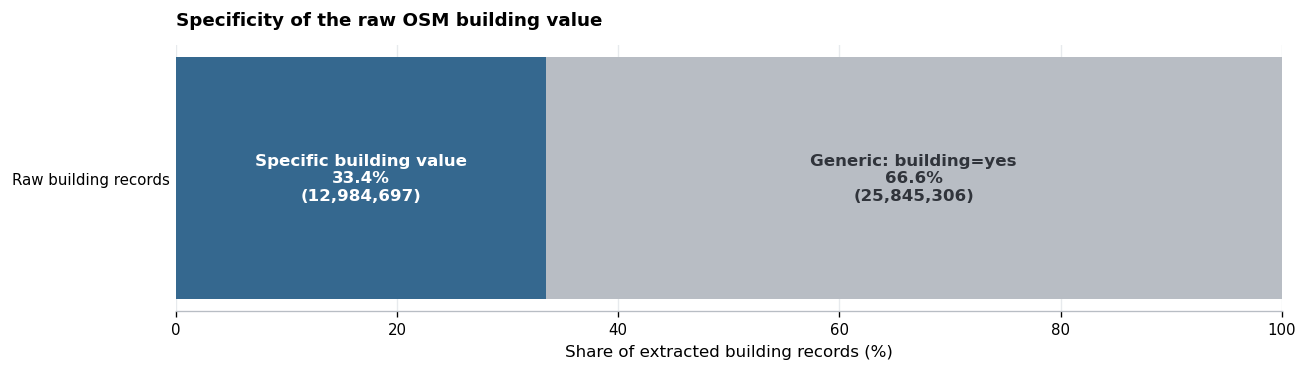

In [ ]:
# SPECIFIC VERSUS GENERIC BUILDING VALUES


building_value = normalized_text(gdf_plot["building"])
generic_mask = building_value.eq("yes")
specific_mask = building_value.notna() & ~generic_mask

generic_count = int(generic_mask.sum())
specific_count = int(specific_mask.sum())
missing_count = int(building_value.isna().sum())

if missing_count > 0:
    print(f"Warning: {missing_count:,} records have no building value and are excluded from this two-group comparison.")

total_comparison = generic_count + specific_count
specific_pct = specific_count / total_comparison * 100
generic_pct = generic_count / total_comparison * 100

fig, ax = plt.subplots(figsize=(11, 3.2))

ax.barh(0, specific_pct, color=COLORS["specific"], height=0.42)
ax.barh(0, generic_pct, left=specific_pct, color=COLORS["generic"], height=0.42)
ax.barh(["Raw building records"], generic_pct, left=specific_pct, color=COLORS["generic"], height=0.42)

ax.text(
    specific_pct / 2, 0,
    f"Specific building value\n{specific_pct:.1f}%\n({specific_count:,})",
    ha="center", va="center", color=COLORS["white"], fontsize=10, weight="semibold"
)

ax.text(
    specific_pct + generic_pct / 2, 0,
    f"Generic: building=yes\n{generic_pct:.1f}%\n({generic_count:,})",
    ha="center", va="center", color=COLORS["dark"], fontsize=10, weight="semibold"
)

ax.set_xlim(0, 100)
ax.set_xlabel("Share of extracted building records (%)")
ax.set_title("Specificity of the raw OSM building value", loc="left", pad=12)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", color=COLORS["light"], linewidth=0.8)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

In [ ]:
from textwrap import fill
from matplotlib.patches import Patch



# Consistent thesis colors
NAVY = "#315C7D"
BLUE = "#5B8DB8"
LIGHT_BLUE = "#DCE8F1"
ORANGE = "#C8754D"
LIGHT_GRAY = "#E6E8EB"
DARK_GRAY = "#3F454B"
MID_GRAY = "#7A828A"

# Consistent thesis figure style
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 400,
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#A8ADB3",
    "axes.linewidth": 0.8,
    "grid.color": "#D9DDE1",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
})

TOTAL = len(gdf_bldg)

# Treat string representations of missing values as missing without modifying gdf_bldg
NULL_ALIASES = {"", "nan", "none", "null", "<na>"}

def valid_value_mask(series):
    mask = series.notna()
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        normalized = series.astype("string").str.strip().str.lower()
        mask &= ~normalized.isin(NULL_ALIASES)
    return mask



In [ ]:

from matplotlib.ticker import FuncFormatter

# Use the untouched building layer for Section 4.2.1
bldg_plot = gdf_bldg_raw  # replace with gdf_bldg if it is still the raw dataset

# Light cleaning only for plotting equivalent values consistently
building_values = bldg_plot['building'].astype('string').str.strip().str.lower()
building_values = building_values.mask(building_values.isin(['', 'nan', 'none', 'null']))

n_total = len(bldg_plot)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150
})

def format_count(value):
    if value >= 1_000_000:
        return f'{value / 1_000_000:.2f}M'
    if value >= 1_000:
        return f'{value / 1_000:.1f}k'
    return f'{value:,.0f}'

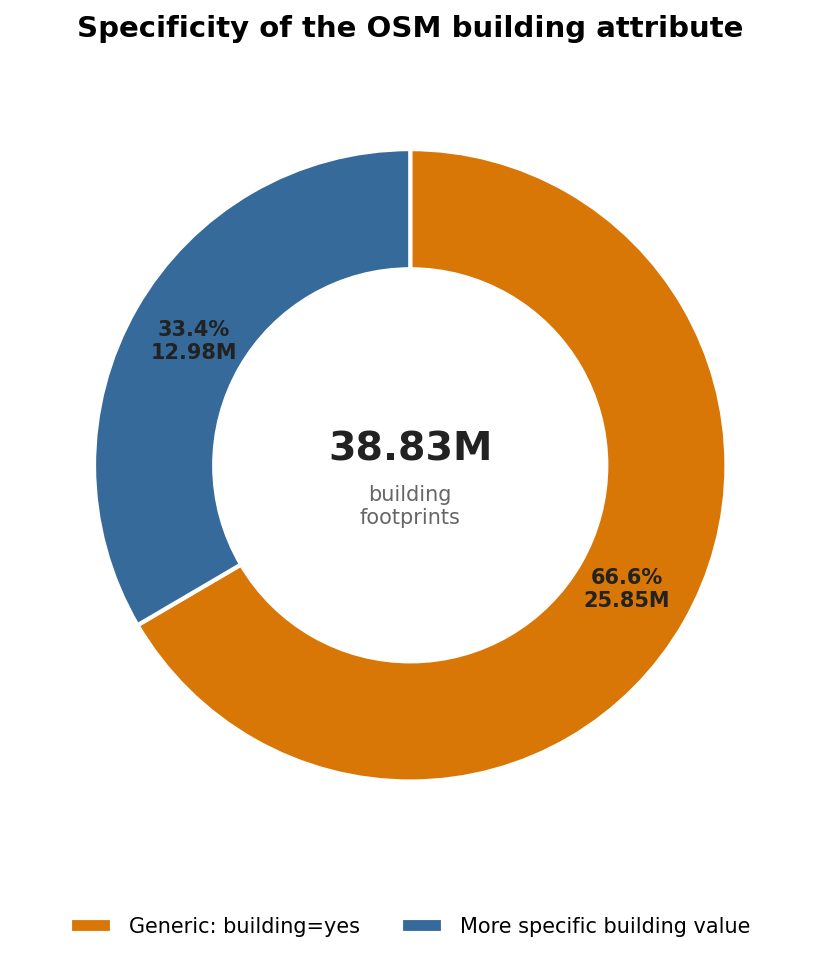

In [81]:
n_yes = building_values.eq('yes').sum()
n_specific = (building_values.notna() & building_values.ne('yes')).sum()
n_missing = n_total - n_yes - n_specific

labels = ['Generic: building=yes', 'More specific building value']
values = [n_yes, n_specific]
colors = ['#D97706', '#356A9A']

# Include missing values only if they exist
if n_missing > 0:
    labels.append('Missing building value')
    values.append(n_missing)
    colors.append('#B8B8B8')

def donut_label(pct):
    count = int(round(pct / 100 * sum(values)))
    return f'{pct:.1f}%\n{format_count(count)}'

fig, ax = plt.subplots(figsize=(8, 6.5))

wedges, _, autotexts = ax.pie(
    values,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct=donut_label,
    pctdistance=0.79,
    wedgeprops={'width': 0.38, 'edgecolor': 'white', 'linewidth': 2}
)

for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
    text.set_color('#222222')

ax.text(
    0, 0.05, format_count(n_total),
    ha='center', va='center',
    fontsize=19, fontweight='bold', color='#222222'
)

ax.text(
    0, -0.13, 'building\nfootprints',
    ha='center', va='center',
    fontsize=10, color='#666666'
)

ax.legend(
    wedges,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=2 if len(labels) == 2 else 3,
    frameon=False,
    fontsize=10
)

ax.set_title(
    'Specificity of the OSM building attribute',
    pad=16,
    fontweight='bold'
)

ax.set_aspect('equal')
plt.tight_layout()
plt.show()

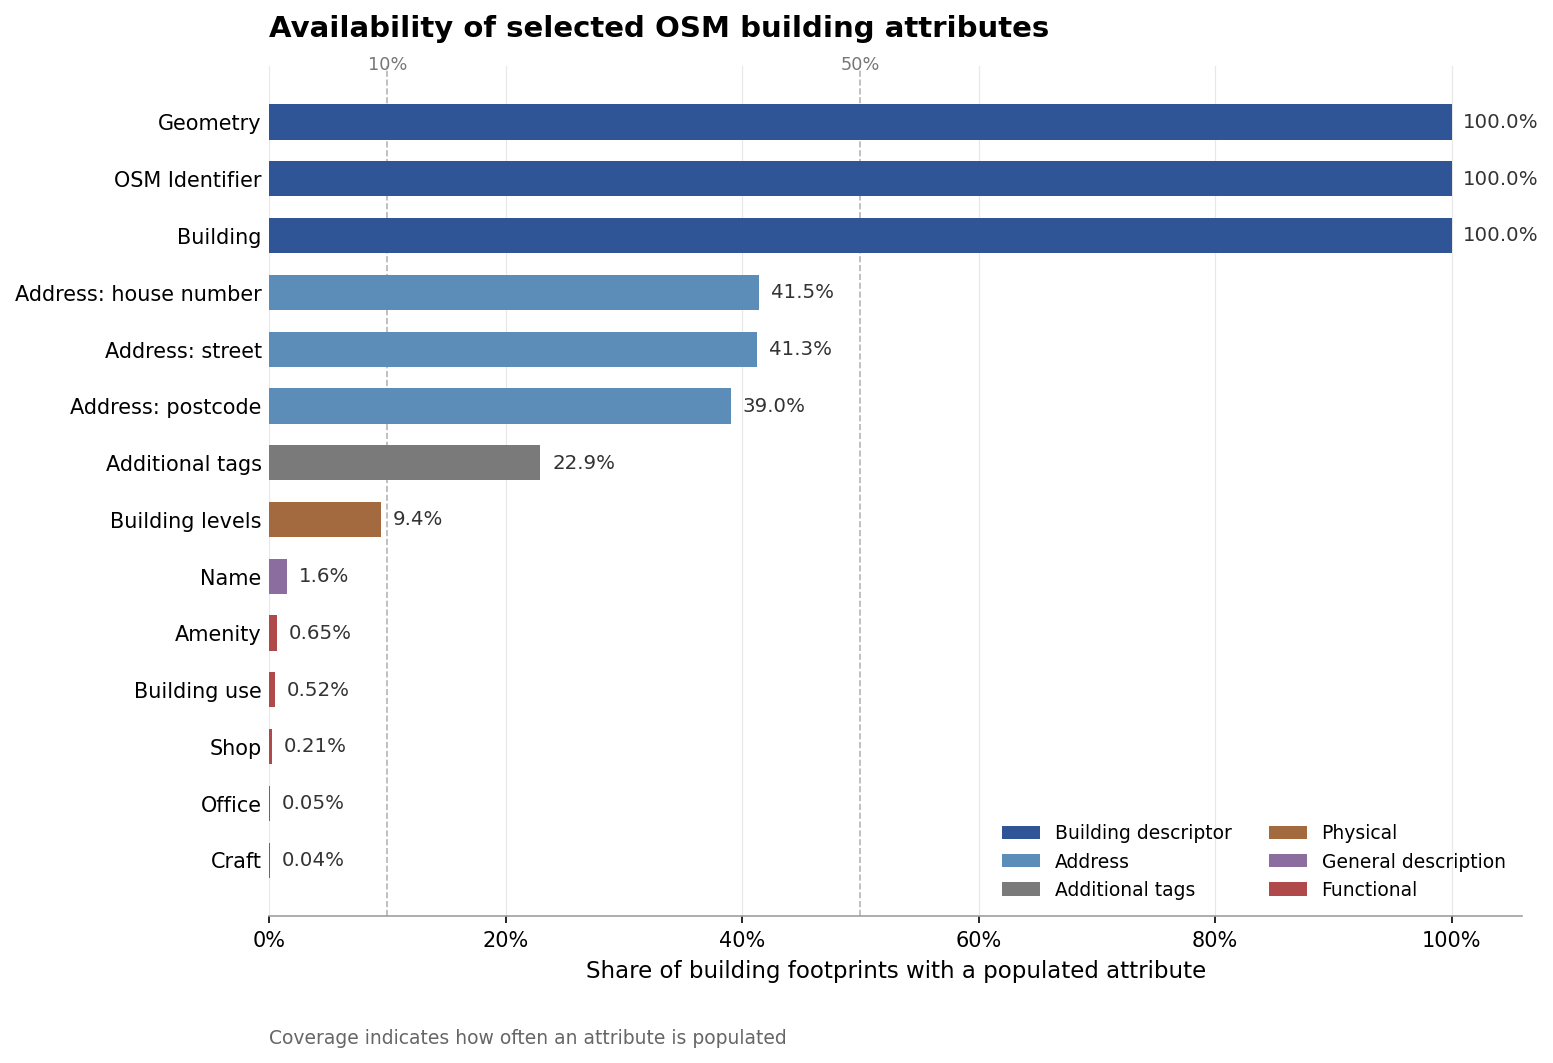

In [ ]:

from matplotlib.ticker import PercentFormatter

# Descriptive attributes relevant to building classification
useful_columns = [
    'building',
    'id',
    'geometry',
    'addr:housenumber',
    'addr:street',
    'addr:postcode',
    'tags',
    'building:levels',
    'name',
    'amenity',
    'building:use',
    'shop',
    'office',
    'craft'
]

# Attribute groups for interpretation
attribute_groups = {
    'building': 'Building descriptor',
    'id': 'Building descriptor',
    'geometry': 'Building descriptor',
    'addr:housenumber': 'Address',
    'addr:street': 'Address',
    'addr:postcode': 'Address',
    'tags': 'Additional tags',
    'building:levels': 'Physical',
    'name': 'General description',
    'amenity': 'Functional',
    'building:use': 'Functional',
    'shop': 'Functional',
    'office': 'Functional',
    'craft': 'Functional'
}

# Thesis-facing labels
display_labels = {
    'building': 'Building',
    'id': 'OSM Identifier',
    'geometry': 'Geometry',
    'addr:housenumber': 'Address: house number',
    'addr:street': 'Address: street',
    'addr:postcode': 'Address: postcode',
    'tags': 'Additional tags',
    'building:levels': 'Building levels',
    'name': 'Name',
    'amenity': 'Amenity',
    'building:use': 'Building use',
    'shop': 'Shop',
    'office': 'Office',
    'craft': 'Craft'
}

plot_df = (
    comp_df[comp_df['column'].isin(useful_columns)]
    .copy()
    .assign(
        group=lambda df: df['column'].map(attribute_groups),
        label=lambda df: df['column'].map(display_labels)
    )
    .sort_values('pct_filled')
)

group_colors = {
    'Building descriptor': '#2F5597',
    'Address': '#5B8DB8',
    'Additional tags': '#7A7A7A',
    'Physical': '#A46A3F',
    'General description': '#8B6E9F',
    'Functional': '#B04A4A'
}

colors = plot_df['group'].map(group_colors)

fig, ax = plt.subplots(figsize=(10.5, 7.2))

bars = ax.barh(
    plot_df['label'],
    plot_df['pct_filled'],
    color=colors,
    height=0.62,
    edgecolor='none'
)

# Value labels
for bar, value in zip(bars, plot_df['pct_filled']):
    label = f'{value:.2f}%' if value < 1 else f'{value:.1f}%'

    ax.text(
        min(value + 1.0, 101.5),
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center',
        ha='left',
        fontsize=9.5,
        color='#333333'
    )

# Reference lines
for threshold in [10, 50]:
    ax.axvline(threshold, color='#B5B5B5', linestyle='--', linewidth=0.8, zorder=0)

ax.text(10, len(plot_df) - 0.15, '10%', ha='center', va='bottom', fontsize=8.5, color='#777777')
ax.text(50, len(plot_df) - 0.15, '50%', ha='center', va='bottom', fontsize=8.5, color='#777777')

# Axis formatting
ax.set_xlim(0, 106)
ax.set_xlabel('Share of building footprints with a populated attribute')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))

ax.grid(axis='x', color='#D9D9D9', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#A0A0A0')
ax.tick_params(axis='y', length=0)

# Legend
legend_handles = [
    Patch(facecolor=color, label=group)
    for group, color in group_colors.items()
]

ax.legend(
    handles=legend_handles,
    loc='lower right',
    frameon=False,
    fontsize=9,
    ncol=2
)

ax.set_title(
    'Availability of selected OSM building attributes',
    loc='left',
    fontsize=14,
    fontweight='bold',
    pad=14
)

ax.text(
    0,
    -0.15,
    'Coverage indicates how often an attribute is populated',
    transform=ax.transAxes,
    fontsize=9,
    color='#666666'
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_110383/3708468689.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


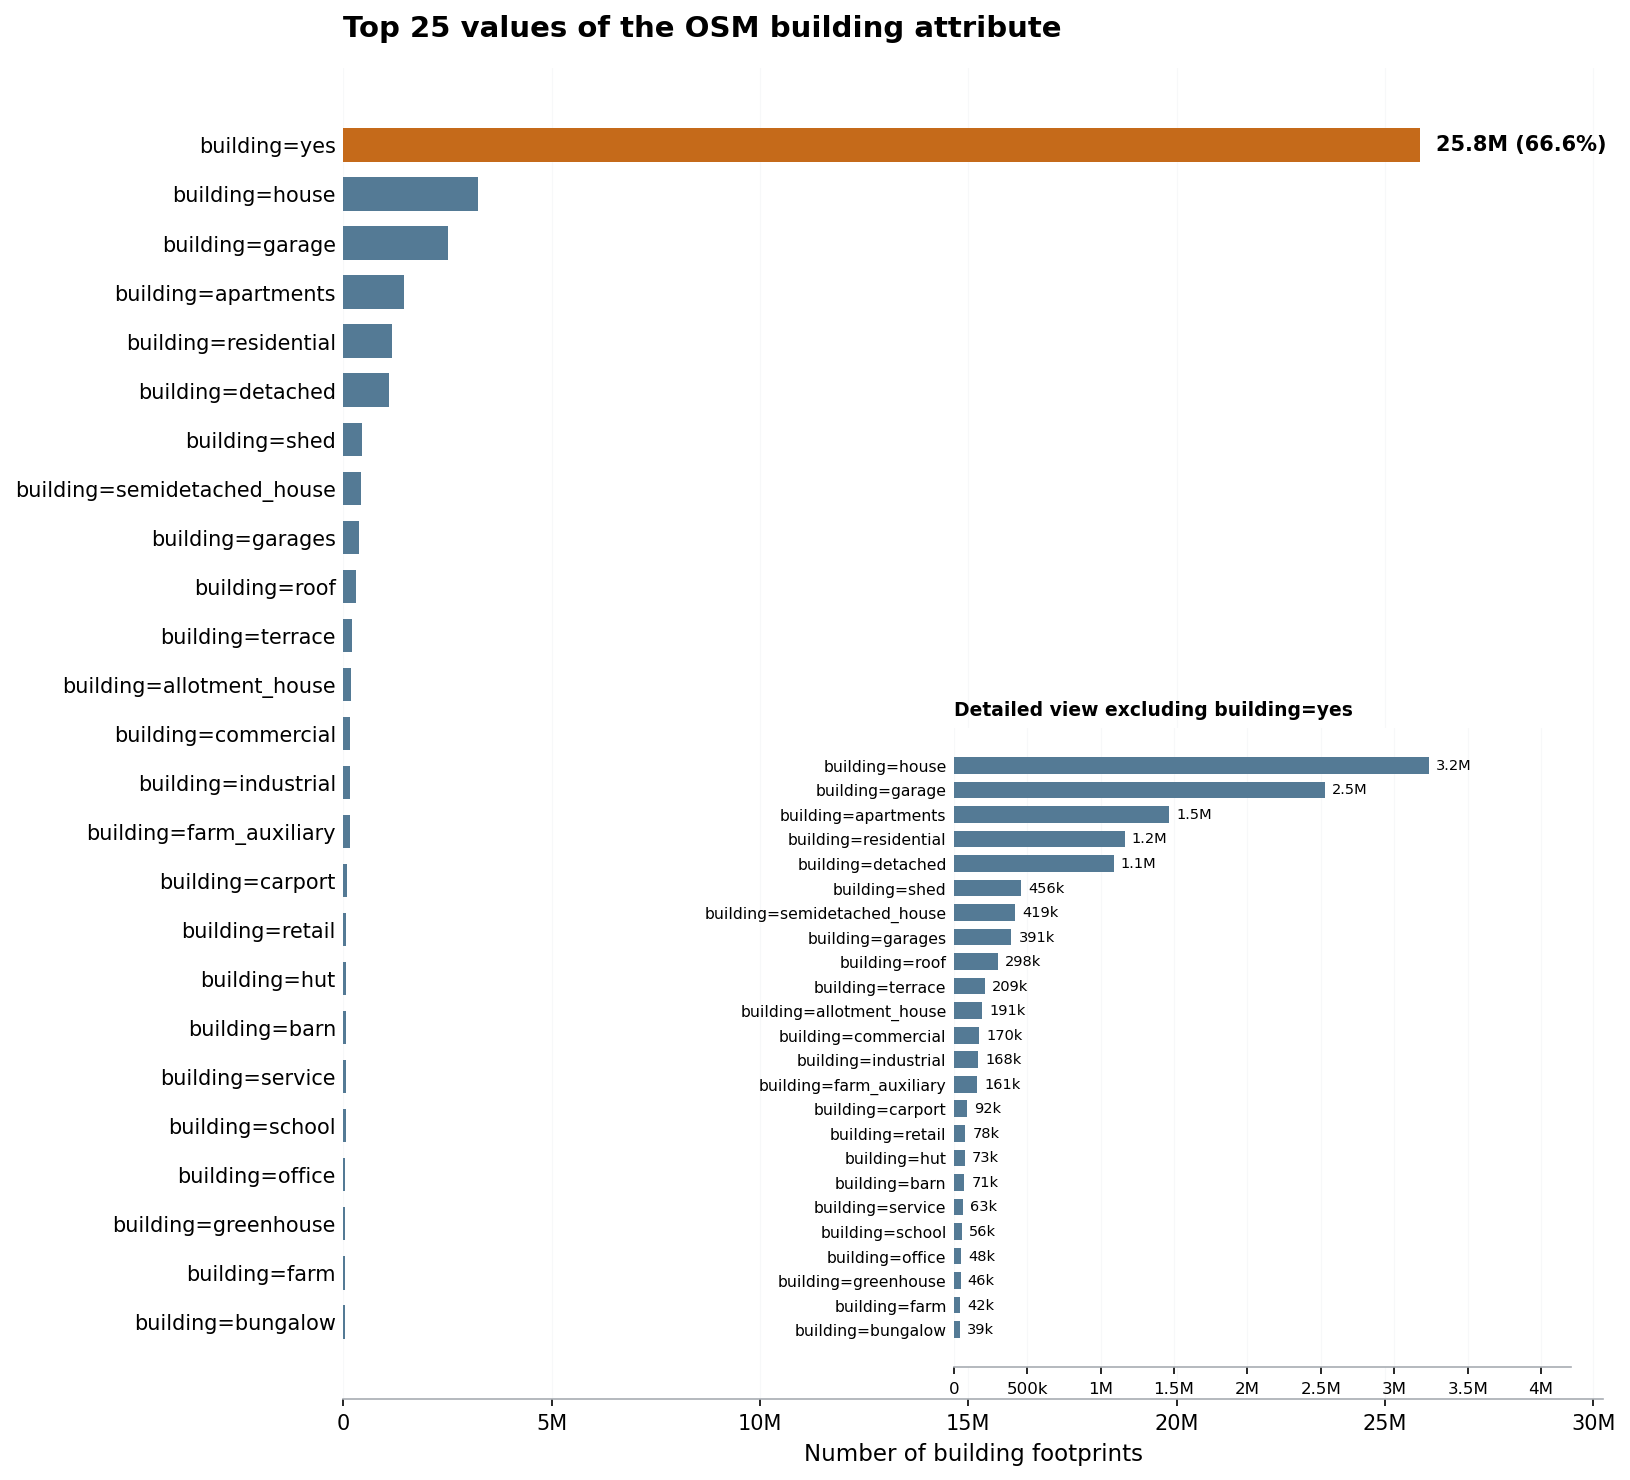

In [ ]:

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

building_values = gdf_bldg_raw['building'].astype('string').str.strip().str.lower()
building_values = building_values.mask(building_values.isin(['', 'nan', 'none', 'null']))

n_total = len(gdf_bldg_raw)
top_n = 25
top_building = building_values.value_counts().head(top_n).sort_values()

def format_count(x):
    if x >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    if x >= 1_000:
        return f'{x / 1_000:.0f}k'
    return f'{x:,.0f}'

def axis_formatter(x, pos):
    if x >= 1_000_000:
        return f'{x / 1_000_000:g}M'
    if x >= 1_000:
        return f'{x / 1_000:g}k'
    return f'{x:g}'

y = np.arange(len(top_building))
colors = ['#C56A1A' if value == 'yes' else '#547A95' for value in top_building.index]

fig, ax = plt.subplots(figsize=(11, 10))

bars = ax.barh(y, top_building.values, color=colors, height=0.68)

ax.set_yticks(y)
ax.set_yticklabels([f'building={value}' for value in top_building.index])
ax.xaxis.set_major_formatter(FuncFormatter(axis_formatter))
ax.set_xlabel('Number of building footprints')
ax.set_ylabel('')

ax.set_title(
    f'Top {top_n} values of the OSM building attribute',
    loc='left',
    pad=15,
    fontweight='bold'
)

ax.grid(axis='x', linewidth=0.6, alpha=0.2)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)

# Label building=yes directly
yes_position = list(top_building.index).index('yes')
yes_count = top_building.loc['yes']
yes_bar = bars[yes_position]

ax.text(
    yes_count + top_building.max() * 0.015,
    yes_bar.get_y() + yes_bar.get_height() / 2,
    f'{format_count(yes_count)} ({yes_count / n_total * 100:.1f}%)',
    va='center',
    fontsize=10,
    fontweight='bold'
)

ax.set_xlim(0, top_building.max() * 1.17)

# Inset showing ranks 2–25 without building=yes
zoom_values = (
    building_values
    .value_counts()
    .drop('yes', errors='ignore')
    .head(top_n - 1)
    .sort_values()
)

ax_inset = inset_axes(
    ax,
    width='49%',
    height='48%',
    loc='lower right',
    borderpad=1.4
)

zoom_y = np.arange(len(zoom_values))
zoom_bars = ax_inset.barh(
    zoom_y,
    zoom_values.values,
    color='#547A95',
    height=0.68
)

ax_inset.set_yticks(zoom_y)
ax_inset.set_yticklabels([f'building={v}' for v in zoom_values.index], fontsize=7.5)
ax_inset.xaxis.set_major_formatter(FuncFormatter(axis_formatter))
ax_inset.tick_params(axis='x', labelsize=8)
ax_inset.tick_params(axis='y', length=0)

ax_inset.set_title(
    'Detailed view excluding building=yes',
    fontsize=9,
    loc='left',
    pad=6,
    fontweight='bold'
)

ax_inset.grid(axis='x', linewidth=0.5, alpha=0.2)
ax_inset.set_axisbelow(True)
ax_inset.spines[['top', 'right', 'left']].set_visible(False)

for bar, count in zip(zoom_bars, zoom_values.values):
    ax_inset.text(
        count + zoom_values.max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        format_count(count),
        va='center',
        fontsize=7
    )

ax_inset.set_xlim(0, zoom_values.max() * 1.30)

plt.tight_layout()
plt.show()

In [ ]:
# COMBINED OSM-LAYER MAP

import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import Point, box

warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
# 1. PATHS
# ============================================================

ROOT_DIR = Path("/fast/home/o-olajuyigbe/osm_project")
DATA_DIR = ROOT_DIR / "data"
FIG_DIR = ROOT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BUILDING_FILE = DATA_DIR / "interim" / "germany_buildings.parquet"
LANDUSE_FILE = DATA_DIR / "interim" / "germany_landuse.parquet"
POI_FILE = DATA_DIR / "interim" / "germany_pois.parquet"
ROAD_FILE = DATA_DIR / "interim" / "germany_roads.parquet"
RAILWAY_FILE = DATA_DIR / "raw" / "germany_railways.parquet"
WATERWAY_FILE = DATA_DIR / "raw" / "germany_waterways.parquet"
MANMADE_FILE = DATA_DIR / "raw" / "germany_manmade.parquet"

OUTPUT_PDF = FIG_DIR / "combined_osm_layers.pdf"
OUTPUT_PNG = FIG_DIR / "combined_osm_layers.png"

FILES = {
    "Buildings": BUILDING_FILE,
    "Land use": LANDUSE_FILE,
    "POIs": POI_FILE,
    "Roads": ROAD_FILE,
    "Railways": RAILWAY_FILE,
    "Waterways": WATERWAY_FILE,
    "Man-made features": MANMADE_FILE,
}

for name, path in FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"{name} file not found: {path}")

print("All input files found.")

All input files found.


In [ ]:

# Example location: Duisburg harbor/industrial area
CENTER_LON = 6.7600
CENTER_LAT = 51.4400

# Distance from the center to each edge of the map
# 1,500 m gives a map width of approximately 3 km
HALF_WIDTH_M = 700

# Metric CRS used only for clipping and plotting
MAP_CRS = "EPSG:3035"

center_wgs84 = gpd.GeoSeries(
    [Point(CENTER_LON, CENTER_LAT)],
    crs="EPSG:4326"
)

center_metric = center_wgs84.to_crs(MAP_CRS).iloc[0]

aoi_metric = box(
    center_metric.x - HALF_WIDTH_M,
    center_metric.y - HALF_WIDTH_M,
    center_metric.x + HALF_WIDTH_M,
    center_metric.y + HALF_WIDTH_M,
)

aoi_wgs84 = gpd.GeoSeries(
    [aoi_metric],
    crs=MAP_CRS
).to_crs("EPSG:4326").iloc[0]

BBOX_WGS84 = aoi_wgs84.bounds

print("Map center:", CENTER_LON, CENTER_LAT)
print(f"Displayed area: approximately {2 * HALF_WIDTH_M / 1_000:.1f} × "
      f"{2 * HALF_WIDTH_M / 1_000:.1f} km")
print("WGS84 bounding box:", BBOX_WGS84)

Map center: 6.76 51.44
Displayed area: approximately 1.4 × 1.4 km
WGS84 bounding box: (6.749494043861072, 51.43343593419568, 6.770503160525464, 51.446563272554215)


In [ ]:

def available_columns(path):
    """Return the columns stored in a Parquet file without loading the data."""
    return pq.read_schema(path).names


def select_columns(path, requested):
    """Retain only requested columns that actually exist in the file."""
    existing = set(available_columns(path))
    columns = [col for col in requested if col in existing]

    if "geometry" not in columns:
        columns.append("geometry")

    return columns


def clean_geometries(gdf):
    """Remove null and empty geometries from a GeoDataFrame."""
    if gdf.empty:
        return gdf

    valid_mask = gdf.geometry.notna() & ~gdf.geometry.is_empty
    return gdf.loc[valid_mask].copy()


def read_aoi_parquet(path, requested_columns, bbox_wgs84, name):
    """
    Read only features intersecting the selected area.

    GeoPandas bbox reading is attempted first. If the GeoParquet file does
    not contain the required bounding-box metadata, Pyogrio is attempted.
    Reading the complete national file is used only as a final fallback.
    """
    columns = select_columns(path, requested_columns)

    print(f"\nReading {name}...")

    # Method 1: GeoPandas spatially filtered GeoParquet read
    try:
        gdf = gpd.read_parquet(path, columns=columns, bbox=bbox_wgs84)
        print("  Method: GeoPandas bounding-box read")

    except Exception as geopandas_error:
        # Method 2: GDAL/Pyogrio spatial filter
        try:
            import pyogrio

            attribute_columns = [c for c in columns if c != "geometry"]

            gdf = pyogrio.read_dataframe(
                path,
                columns=attribute_columns,
                bbox=bbox_wgs84,
                use_arrow=True,
            )

            print("  Method: Pyogrio bounding-box read")

        except Exception as pyogrio_error:
            # Method 3: Complete-file fallback
            print("  Bounding-box reading was unavailable.")
            print("  Falling back to complete-file read.")

            gdf = gpd.read_parquet(path, columns=columns)

            if gdf.crs is None:
                raise ValueError(f"{name} has no CRS information.")

            bbox_geometry = gpd.GeoSeries(
                [box(*bbox_wgs84)],
                crs="EPSG:4326",
            ).to_crs(gdf.crs).iloc[0]

            minx, miny, maxx, maxy = bbox_geometry.bounds
            gdf = gdf.cx[minx:maxx, miny:maxy].copy()

            print(f"  GeoPandas bbox error: {type(geopandas_error).__name__}")
            print(f"  Pyogrio bbox error: {type(pyogrio_error).__name__}")

    if gdf.crs is None:
        raise ValueError(f"{name} has no CRS information.")

    gdf = clean_geometries(gdf)

    # Ensure the final spatial subset matches the exact square AOI
    aoi_layer_crs = gpd.GeoSeries(
        [aoi_metric],
        crs=MAP_CRS,
    ).to_crs(gdf.crs).iloc[0]

    minx, miny, maxx, maxy = aoi_layer_crs.bounds
    gdf = gdf.cx[minx:maxx, miny:maxy].copy()

    if not gdf.empty:
        gdf = gdf.to_crs(MAP_CRS)
        gdf = gpd.clip(gdf, aoi_metric)
        gdf = clean_geometries(gdf)

    print(f"  Features retained: {len(gdf):,}")
    print(f"  Geometry types: {gdf.geometry.geom_type.value_counts().to_dict()}")

    return gdf

In [ ]:
#  LOAD THE SELECTED AREA FROM EACH DATASET

gdf_bldg = read_aoi_parquet(
    BUILDING_FILE,
    ["id", "osm_type", "building", "name", "geometry"],
    BBOX_WGS84,
    "buildings",
)

gdf_landuse = read_aoi_parquet(
    LANDUSE_FILE,
    ["id", "landuse", "name", "geometry"],
    BBOX_WGS84,
    "land use",
)

gdf_poi = read_aoi_parquet(
    POI_FILE,
    ["id", "name", "amenity", "shop", "office", "tourism", "geometry"],
    BBOX_WGS84,
    "POIs",
)

gdf_roads = read_aoi_parquet(
    ROAD_FILE,
    ["id", "highway", "name", "geometry"],
    BBOX_WGS84,
    "roads",
)

gdf_railways = read_aoi_parquet(
    RAILWAY_FILE,
    ["id", "railway", "name", "geometry"],
    BBOX_WGS84,
    "railways",
)

gdf_waterways = read_aoi_parquet(
    WATERWAY_FILE,
    ["id", "waterway", "name", "geometry"],
    BBOX_WGS84,
    "waterways",
)

gdf_manmade = read_aoi_parquet(
    MANMADE_FILE,
    ["id", "man_made", "name", "geometry"],
    BBOX_WGS84,
    "man-made features",
)


Reading buildings...
  Bounding-box reading was unavailable.
  Falling back to complete-file read.
  GeoPandas bbox error: ValueError
  Pyogrio bbox error: DataSourceError
  Features retained: 1,184
  Geometry types: {'Polygon': 1182, 'MultiPolygon': 1, 'GeometryCollection': 1}

Reading land use...
  Bounding-box reading was unavailable.
  Falling back to complete-file read.
  GeoPandas bbox error: ValueError
  Pyogrio bbox error: DataSourceError
  Features retained: 231
  Geometry types: {'Polygon': 228, 'MultiPolygon': 3}

Reading POIs...
  Bounding-box reading was unavailable.
  Falling back to complete-file read.
  GeoPandas bbox error: ValueError
  Pyogrio bbox error: DataSourceError
  Features retained: 497
  Geometry types: {'Point': 370, 'Polygon': 125, 'MultiPolygon': 1, 'MultiLineString': 1}

Reading roads...
  Bounding-box reading was unavailable.
  Falling back to complete-file read.
  GeoPandas bbox error: ValueError
  Pyogrio bbox error: DataSourceError
  Features retain

In [ ]:
# LAYER SUMMARY

layer_counts = {
    "Buildings": len(gdf_bldg),
    "Land use": len(gdf_landuse),
    "POIs": len(gdf_poi),
    "Roads": len(gdf_roads),
    "Railways": len(gdf_railways),
    "Waterways": len(gdf_waterways),
    "Man-made features": len(gdf_manmade),
}

print("\n" + "=" * 55)
print("FEATURES IN THE SELECTED MAP AREA")
print("=" * 55)

for layer, count in layer_counts.items():
    status = "" if count > 0 else "  <-- NOT PRESENT"
    print(f"{layer:<22} {count:>8,}{status}")


FEATURES IN THE SELECTED MAP AREA
Buildings                 1,184
Land use                    231
POIs                        497
Roads                       563
Railways                     32
Waterways                     4
Man-made features            28


In [97]:
def spatially_thin_points(gdf, cell_size=100, max_points=50):
    if gdf.empty:
        return gdf.copy()

    points = gdf.copy()
    points["_x"] = points.geometry.x
    points["_y"] = points.geometry.y
    points["_grid_x"] = (points["_x"] // cell_size).astype(int)
    points["_grid_y"] = (points["_y"] // cell_size).astype(int)

    points = (
        points
        .sort_values(["_grid_x", "_grid_y"])
        .drop_duplicates(["_grid_x", "_grid_y"])
        .head(max_points)
        .drop(columns=["_x", "_y", "_grid_x", "_grid_y"])
    )

    return points

In [ ]:
#  GEOMETRY GROUPS

def geometry_subset(gdf, geometry_types):
    if gdf.empty:
        return gdf.copy()

    return gdf[
        gdf.geometry.geom_type.isin(geometry_types)
    ].copy()


POLYGON_TYPES = ["Polygon", "MultiPolygon"]
LINE_TYPES = ["LineString", "MultiLineString"]
POINT_TYPES = ["Point", "MultiPoint"]

building_polygons = geometry_subset(gdf_bldg, POLYGON_TYPES)

landuse_polygons = geometry_subset(gdf_landuse, POLYGON_TYPES)

poi_points = geometry_subset(gdf_poi, POINT_TYPES)
poi_polygons = geometry_subset(gdf_poi, POLYGON_TYPES)

road_lines = geometry_subset(gdf_roads, LINE_TYPES)
railway_lines = geometry_subset(gdf_railways, LINE_TYPES)
waterway_lines = geometry_subset(gdf_waterways, LINE_TYPES)

manmade_points = geometry_subset(gdf_manmade, POINT_TYPES)
manmade_lines = geometry_subset(gdf_manmade, LINE_TYPES)
manmade_polygons = geometry_subset(gdf_manmade, POLYGON_TYPES)

print("\nGeometry groups prepared.")


Geometry groups prepared.


In [99]:
poi_points_plot = spatially_thin_points(poi_points, cell_size=100, max_points=45)
manmade_points_plot = spatially_thin_points(manmade_points, cell_size=150, max_points=20)

print(f"POI points shown: {len(poi_points_plot):,} of {len(poi_points):,}")
print(f"Man-made points shown: {len(manmade_points_plot):,} of {len(manmade_points):,}")

POI points shown: 45 of 370
Man-made points shown: 0 of 0


In [100]:
MAJOR_ROAD_VALUES = {
    "motorway", "motorway_link",
    "trunk", "trunk_link",
    "primary", "primary_link",
    "secondary", "secondary_link",
    "tertiary", "tertiary_link"
}

if "highway" in road_lines.columns:
    major_roads = road_lines[road_lines["highway"].isin(MAJOR_ROAD_VALUES)].copy()
    local_roads = road_lines[road_lines["highway"].isin(["residential", "living_street", "service"])].copy()
else:
    major_roads = road_lines.copy()
    local_roads = road_lines.iloc[0:0].copy()

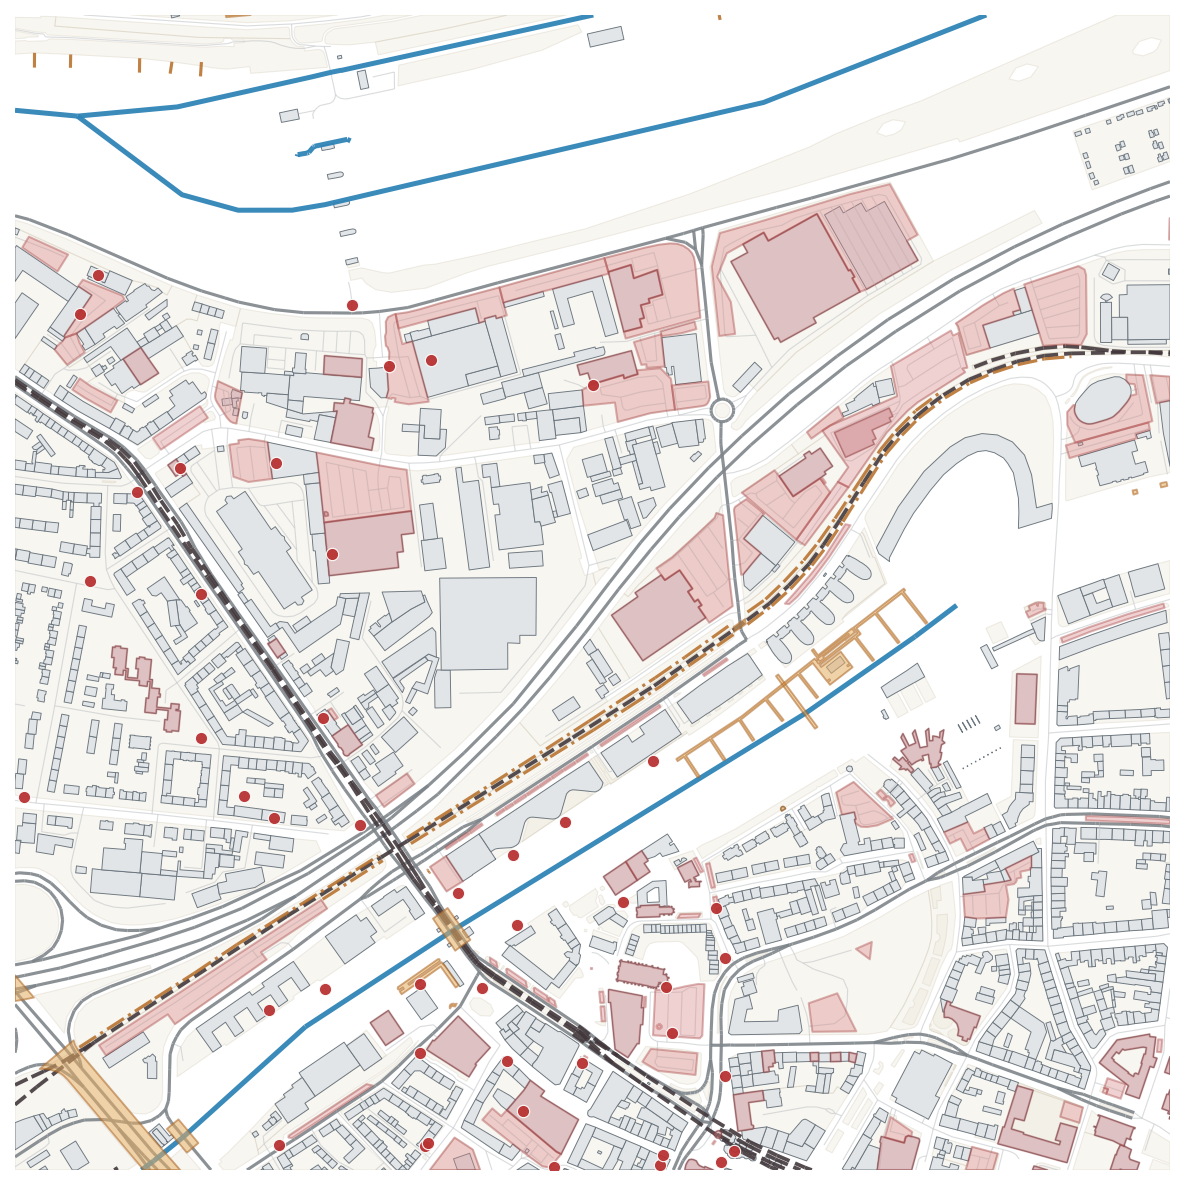

In [101]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10
})

fig, ax = plt.subplots(figsize=(10, 10))

# Land-use context: very light background
if not landuse_polygons.empty:
    landuse_polygons.plot(
        ax=ax,
        facecolor="#E8E1CF",
        edgecolor="#C8BFA8",
        linewidth=0.5,
        alpha=0.28,
        zorder=1
    )

# Building footprints: main reference layer
if not building_polygons.empty:
    building_polygons.plot(
        ax=ax,
        facecolor="#E1E5E8",
        edgecolor="#66717A",
        linewidth=0.45,
        alpha=0.95,
        zorder=3
    )

# Local roads: subtle background context
if not local_roads.empty:
    local_roads.plot(
        ax=ax,
        color="#C6C9CB",
        linewidth=0.55,
        alpha=0.65,
        zorder=4
    )

# Major roads
if not major_roads.empty:
    major_roads.plot(
        ax=ax,
        color="#7E858A",
        linewidth=1.5,
        alpha=0.90,
        zorder=5
    )

# Waterways
if not waterway_lines.empty:
    waterway_lines.plot(
        ax=ax,
        color="#2F84B7",
        linewidth=2.4,
        alpha=0.95,
        zorder=6
    )

# Railways
if not railway_lines.empty:
    railway_lines.plot(
        ax=ax,
        color="#42383C",
        linewidth=1.8,
        linestyle="--",
        alpha=0.90,
        zorder=7
    )

# Polygon POIs
if not poi_polygons.empty:
    poi_polygons.plot(
        ax=ax,
        facecolor="#D98787",
        edgecolor="#A33B3B",
        linewidth=1.0,
        alpha=0.38,
        zorder=8
    )

# Polygon man-made features
if not manmade_polygons.empty:
    manmade_polygons.plot(
        ax=ax,
        facecolor="#E5AD63",
        edgecolor="#AB6421",
        linewidth=0.9,
        alpha=0.55,
        zorder=9
    )

# Linear man-made features
if not manmade_lines.empty:
    manmade_lines.plot(
        ax=ax,
        color="#B56B24",
        linewidth=1.5,
        linestyle="-.",
        alpha=0.85,
        zorder=10
    )

# Reduced POI points
if not poi_points_plot.empty:
    poi_points_plot.plot(
        ax=ax,
        color="#B83232",
        edgecolor="white",
        linewidth=0.55,
        markersize=35,
        marker="o",
        alpha=0.95,
        zorder=12
    )

# Reduced man-made points
if not manmade_points_plot.empty:
    manmade_points_plot.plot(
        ax=ax,
        color="#D77D27",
        edgecolor="#713A0D",
        linewidth=0.6,
        markersize=45,
        marker="^",
        alpha=0.95,
        zorder=13
    )

xmin, ymin, xmax, ymax = aoi_metric.bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_axis_off()

In [ ]:
# SCALE BAR AND NORTH ARROW

xmin, ymin, xmax, ymax = aoi_metric.bounds
map_width = xmax - xmin
map_height = ymax - ymin

if map_width <= 1_500:
    scale_length = 200
elif map_width <= 3_500:
    scale_length = 500
elif map_width <= 7_000:
    scale_length = 1_000
else:
    scale_length = 2_000

scale_x = xmin + map_width * 0.055
scale_y = ymin + map_height * 0.055

ax.plot(
    [scale_x, scale_x + scale_length],
    [scale_y, scale_y],
    color="#222222",
    linewidth=4,
    solid_capstyle="butt",
    zorder=30,
)

ax.plot(
    [scale_x, scale_x],
    [scale_y - map_height * 0.006, scale_y + map_height * 0.006],
    color="#222222",
    linewidth=1.4,
    zorder=30,
)

ax.plot(
    [scale_x + scale_length, scale_x + scale_length],
    [scale_y - map_height * 0.006, scale_y + map_height * 0.006],
    color="#222222",
    linewidth=1.4,
    zorder=30,
)

scale_label = (
    f"{scale_length / 1_000:g} km"
    if scale_length >= 1_000
    else f"{scale_length} m"
)

ax.text(
    scale_x + scale_length / 2,
    scale_y + map_height * 0.014,
    scale_label,
    ha="center",
    va="bottom",
    fontsize=9,
    fontweight="bold",
    color="#222222",
    zorder=30,
)

ax.annotate(
    "N",
    xy=(0.945, 0.95),
    xytext=(0.945, 0.84),
    xycoords="axes fraction",
    textcoords="axes fraction",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    arrowprops={
        "facecolor": "#222222",
        "edgecolor": "#222222",
        "width": 4,
        "headwidth": 12,
        "headlength": 12,
    },
    zorder=30,
)

Text(0.945, 0.84, 'N')

In [102]:
legend_items = [
    Patch(facecolor="#E1E5E8", edgecolor="#66717A", label="Building footprint"),
    Patch(facecolor="#E8E1CF", edgecolor="#C8BFA8", label="Land-use polygon"),
    Patch(facecolor="#D98787", edgecolor="#A33B3B", label="Polygon POI"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#B83232",
           markeredgecolor="white", markersize=8, label="Point POI"),
    Line2D([0], [0], color="#7E858A", linewidth=2, label="Road"),
    Line2D([0], [0], color="#42383C", linewidth=2, linestyle="--", label="Railway"),
    Line2D([0], [0], color="#2F84B7", linewidth=2.5, label="Waterway"),
    Patch(facecolor="#E5AD63", edgecolor="#AB6421", label="Man-made feature")
]

ax.legend(
    handles=legend_items,
    loc="lower right",
    ncol=2,
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="#C4C4C4",
    fontsize=8.5,
    columnspacing=1.1,
    handlelength=2.1
)

In [103]:
plt.tight_layout()


plt.show()

<Figure size 960x720 with 0 Axes>

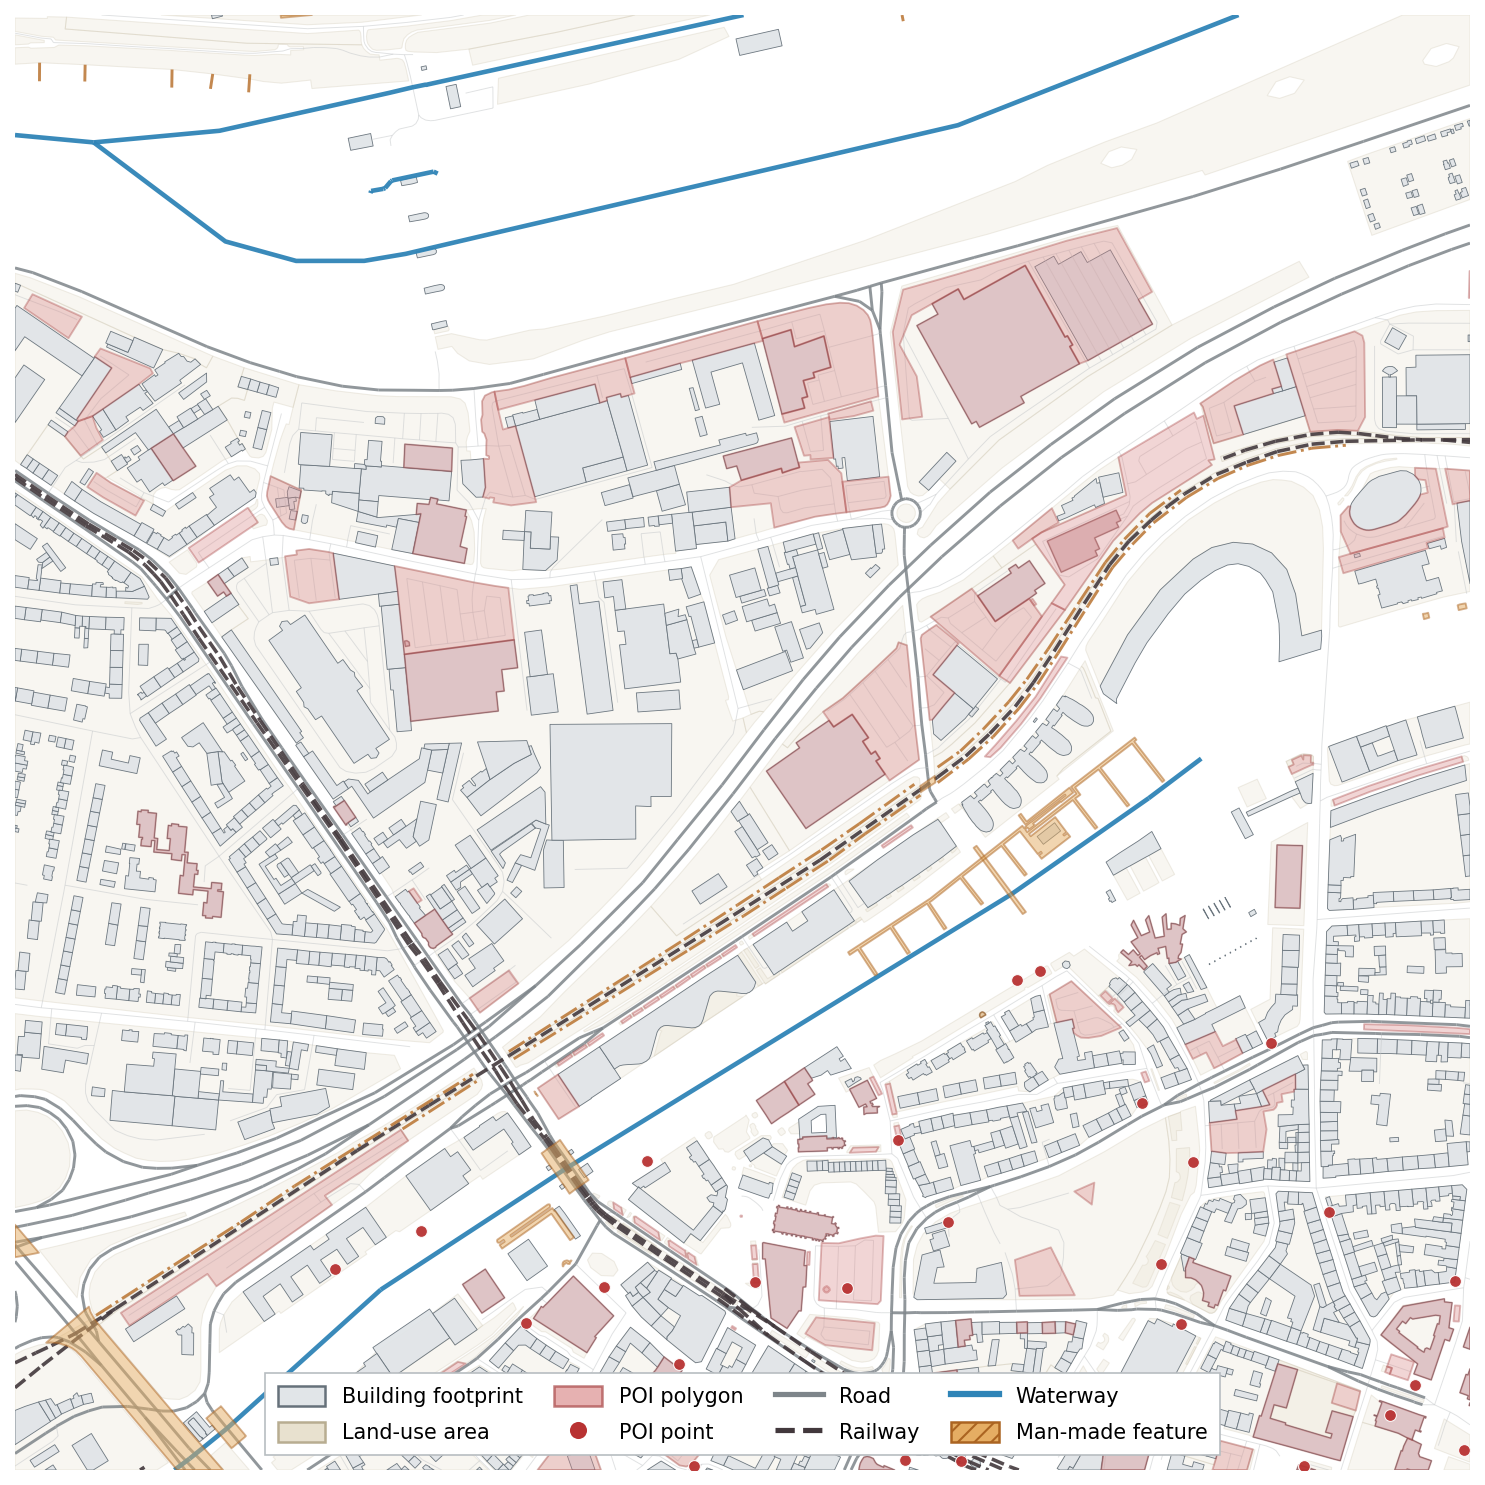

In [107]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

# Reduce point density
def spatially_thin_points(gdf, cell_size=100, max_points=45):
    if gdf.empty:
        return gdf.copy()

    out = gdf.copy()
    out["_gx"] = (out.geometry.x // cell_size).astype(int)
    out["_gy"] = (out.geometry.y // cell_size).astype(int)

    return (
        out.drop_duplicates(["_gx", "_gy"])
        .head(max_points)
        .drop(columns=["_gx", "_gy"])
    )

poi_points_plot = spatially_thin_points(poi_points, cell_size=120, max_points=35)
manmade_points_plot = spatially_thin_points(manmade_points, cell_size=150, max_points=15)

# Retain only useful road classes
major_values = {
    "motorway", "motorway_link", "trunk", "trunk_link",
    "primary", "primary_link", "secondary", "secondary_link",
    "tertiary", "tertiary_link"
}

local_values = {"residential", "living_street", "service"}

if "highway" in road_lines.columns:
    major_roads = road_lines[road_lines["highway"].isin(major_values)].copy()
    local_roads = road_lines[road_lines["highway"].isin(local_values)].copy()
else:
    major_roads = road_lines.copy()
    local_roads = road_lines.iloc[0:0].copy()

# Create exactly one figure and one axis
fig, ax = plt.subplots(figsize=(10, 10))

# Background layers
if not landuse_polygons.empty:
    landuse_polygons.plot(ax=ax, facecolor="#E8E1CF", edgecolor="#C8BFA8",
                          linewidth=0.5, alpha=0.28, zorder=1)

if not building_polygons.empty:
    building_polygons.plot(ax=ax, facecolor="#E1E5E8", edgecolor="#66717A",
                           linewidth=0.4, alpha=0.95, zorder=3)

# Transport and water networks
if not local_roads.empty:
    local_roads.plot(ax=ax, color="#C6C9CB", linewidth=0.45,
                     alpha=0.55, zorder=4)

if not major_roads.empty:
    major_roads.plot(ax=ax, color="#7E858A", linewidth=1.4,
                     alpha=0.85, zorder=5)

if not waterway_lines.empty:
    waterway_lines.plot(ax=ax, color="#2F84B7", linewidth=2.2,
                        alpha=0.95, zorder=6)

if not railway_lines.empty:
    railway_lines.plot(ax=ax, color="#42383C", linewidth=1.7,
                       linestyle="--", alpha=0.9, zorder=7)

# POI and man-made polygons
if not poi_polygons.empty:
    poi_polygons.plot(ax=ax, facecolor="#D98787", edgecolor="#A33B3B",
                      linewidth=0.9, alpha=0.35, zorder=8)

if not manmade_polygons.empty:
    manmade_polygons.plot(ax=ax, facecolor="#E5AD63", edgecolor="#AB6421",
                          linewidth=0.9, alpha=0.5, zorder=9)

if not manmade_lines.empty:
    manmade_lines.plot(ax=ax, color="#B56B24", linewidth=1.4,
                       linestyle="-.", alpha=0.8, zorder=10)

# Thinned point layers
if not poi_points_plot.empty:
    poi_points_plot.plot(ax=ax, color="#B83232", edgecolor="white",
                         linewidth=0.5, markersize=32, marker="o",
                         alpha=0.95, zorder=12)

if not manmade_points_plot.empty:
    manmade_points_plot.plot(ax=ax, color="#D77D27", edgecolor="#713A0D",
                             linewidth=0.6, markersize=42, marker="^",
                             alpha=0.95, zorder=13)

# Use the AOI limits
xmin, ymin, xmax, ymax = aoi_metric.bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_axis_off()

legend_items = [
    Patch(facecolor="#E1E5E8", edgecolor="#66717A", linewidth=1.2,
          label="Building footprint"),
    Patch(facecolor="#E8E1CF", edgecolor="#B8AD91", linewidth=1.2,
          label="Land-use area"),
    Patch(facecolor="#D98787", edgecolor="#A33B3B", linewidth=1.2, alpha=0.65,
          label="POI polygon"),
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="#B83232",
           markeredgecolor="white", markeredgewidth=0.8, markersize=9,
           label="POI point"),
    Line2D([0], [0], color="#7E858A", linewidth=2.5,
           label="Road"),
    Line2D([0], [0], color="#42383C", linewidth=2.5, linestyle="--",
           label="Railway"),
    Line2D([0], [0], color="#2F84B7", linewidth=3,
           label="Waterway"),
    Patch(facecolor="#E5AD63", edgecolor="#AB6421", linewidth=1.2, hatch="///",
          label="Man-made feature")
]


# Remove any legend already attached to the map
existing_legend = ax.get_legend()
if existing_legend is not None:
    existing_legend.remove()

# Leave space underneath the map
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.13)

legend = fig.legend(
    handles=legend_items,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.018),
    ncol=4,
    frameon=True,
    fancybox=False,
    framealpha=1,
    facecolor="white",
    edgecolor="#B8BDC1",
    fontsize=10,
    handlelength=2.3,
    handleheight=1.1,
    columnspacing=1.5,
    labelspacing=0.7,
    borderpad=0.6
)

legend.get_frame().set_linewidth(0.8)
fig.tight_layout()
plt.show()